# Lección 7.1 · La transformada de Burrows-Wheeler y el índice FM: buscar millones de lecturas en un genoma

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-07-mapeo/7.1_bwt_fm_index.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 7 — Mapeo de lecturas** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio-avanzado | Lecciones 3.1–3.2 (alineamiento), 6.1–6.3 (lecturas NGS y cobertura), Python con NumPy, noción de búsqueda binaria |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Estimar** con números por qué es imposible mapear cientos de millones de lecturas contra un genoma humano
   comparando cada lectura con cada posición (búsqueda ingenua o Smith-Waterman).
2. **Construir** a mano y en código una **tabla de *k*-mers** y un **arreglo de sufijos** (*suffix array*), y **buscar**
   un patrón en él por búsqueda binaria.
3. **Calcular** a mano la **transformada de Burrows-Wheeler** (BWT) de una palabra corta y de una secuencia de ADN,
   e **identificar** las columnas $F$ y $L$ de la matriz de rotaciones ordenadas.
4. **Explicar** por qué la columna $L$ forma **corridas** de letras iguales y **medir** cuánto se comprime en el genoma
   de SARS-CoV-2 y en una colección de 30 genomas parecidos.
5. **Enunciar y justificar** la propiedad **LF** (*last-to-first*) y **usarla** para **invertir** la BWT paso a paso.
6. **Construir** las tablas $C$ y $\mathrm{Occ}$ del **índice FM** y **ejecutar** a mano la **búsqueda hacia atrás**
   (*backward search*) con las ecuaciones de actualización del intervalo semiabierto $[sp, ep)$.
7. **Localizar** las posiciones de un patrón con un **arreglo de sufijos muestreado** y **analizar** el compromiso
   memoria–tiempo.
8. **Indexar** el genoma completo de *E. coli* (4.6 Mb), **verificar** el índice contra `str.find`, **contar** *k*-mers
   repetidos y **mapear** lecturas simuladas.
9. **Comparar** empíricamente el tiempo de la búsqueda ingenua y del índice FM en función de la longitud del patrón y
   del genoma, y **describir** cómo la búsqueda con errores por **retroceso** conduce a BWA y Bowtie.

## 🗺️ Mapa de la clase

1. El problema: millones de lecturas contra miles de millones de bases
2. Primer índice: la tabla de *k*-mers
3. El arreglo de sufijos: `BANANA$` ordenado y búsqueda binaria
4. La transformada de Burrows-Wheeler: rotaciones, columnas $F$ y $L$ (🎛️ matriz interactiva)
5. ¿Por qué $L$ se comprime tan bien? Corridas, gzip y bzip2 sobre SARS-CoV-2
6. La propiedad LF (*last-to-first*)
7. Invertir la BWT paso a paso (🎬 animación)
8. El índice FM: tablas $C$ y $\mathrm{Occ}$ y la búsqueda hacia atrás (🎬 animación y 🎛️ explorador)
9. Localizar: el arreglo de sufijos muestreado
10. Un índice FM para *E. coli*: verificación, *k*-mers repetidos y un mini-mapeador
11. ¿Cuánto más rápido? Tiempo y memoria frente a la búsqueda ingenua
12. Buscar con errores: retroceso, el puente hacia BWA y Bowtie
13. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import gzip, io, re, time, timeit, bz2, zlib, sys, warnings
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import Rectangle, FancyArrowPatch

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"
EFETCH = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id={}&rettype={}&retmode=text"

def course_bytes(name, live_url=None):
    """Lee un archivo del curso: 1) copia local ../data; 2) copia del repositorio en GitHub;
    3) servicio original (NCBI). Devuelve los bytes."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for url in [f"{RAW}/data/{name}", live_url]:
        if url is None:
            continue
        try:
            with urllib.request.urlopen(url, timeout=120) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo descargar {url[:70]}… ({err}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

def genbank_sequence(text):
    """Extrae la secuencia del bloque ORIGIN de un archivo GenBank (sin necesidad de Biopython)."""
    origin = text.split("\nORIGIN")[1].split("\n//")[0]
    return re.sub(r"[^acgtnACGTN]", "", origin).upper()

def fasta_sequence(text):
    """Une las líneas de secuencia de un FASTA de un solo registro."""
    return "".join(l.strip() for l in text.splitlines() if not l.startswith(">")).upper()

SARS = genbank_sequence(course_bytes("NC_045512.2.gb", EFETCH.format("NC_045512.2", "gb")).decode())
ECOLI = fasta_sequence(gzip.decompress(course_bytes("NC_000913.3.fasta.gz")).decode())
print(f"SARS-CoV-2 (NC_045512.2): {len(SARS):,} nt · alfabeto {sorted(set(SARS))}")
print(f"E. coli K-12 (NC_000913.3): {len(ECOLI):,} nt · alfabeto {sorted(set(ECOLI))}")
rng = np.random.default_rng(71)       # semilla fija: todos obtenemos los mismos números
print("Listo para la Lección 7.1")

Entorno listo ✔  |  Colab: False
SARS-CoV-2 (NC_045512.2): 29,903 nt · alfabeto ['A', 'C', 'G', 'T']
E. coli K-12 (NC_000913.3): 4,641,652 nt · alfabeto ['A', 'C', 'G', 'T']
Listo para la Lección 7.1


## 1. El problema: millones de lecturas contra miles de millones de bases

Después de secuenciar (Módulo 6) tenemos un archivo FASTQ con, digamos, **620 millones de lecturas** de 150 pb de un
genoma humano secuenciado a unas 30×. Cada lectura es un trocito de 150 letras arrancado de algún lugar desconocido de un texto de **3 100
millones** de letras. **Mapear** (*read mapping*) es responder, para cada lectura, a la pregunta: **¿de dónde salió?**
Sólo con esa respuesta podremos después medir cobertura, llamar variantes (Módulo 9) o cuantificar expresión (Módulo 11).

La primera idea es la de un estudiante con una lupa: poner la lectura debajo del genoma, compararla letra a letra,
correrla una posición, volver a comparar… hasta el final. Hagamos la cuenta **antes** de programar nada.

### Estimación con números

| Símbolo | Significado | Valor |
|---|---|---|
| $R$ | secuencia de referencia (el genoma, con sus cromosomas concatenados) | — |
| $G$ | longitud de la referencia | $3.1\times10^{9}$ pb |
| $q$, $m$ | una lectura (el patrón que buscamos) y su longitud | 150 pb |
| $N$ | número de lecturas | $6.2\times10^{8}$ (un genoma a ~30×) |
| $v$ | comparaciones (o celdas de programación dinámica) que un núcleo hace por segundo | $\sim10^{9}$ (optimista) |

**Búsqueda ingenua exacta.** Para una lectura hay $G - m + 1 \approx G$ posiciones de inicio; en el peor caso se
comparan $m$ letras en cada una, pero en ADN la comparación suele fallar en la 1.ª o 2.ª letra, así que el costo
típico es de unas $G$ comparaciones por lectura:

$$
T_{\text{ingenua}} \approx \frac{N \cdot G}{v} = \frac{6.2\times10^{8} \cdot 3.1\times10^{9}}{10^{9}}
\approx 1.9\times10^{9}\ \text{s} \approx 61\ \text{años}
$$

**Smith-Waterman** (Lección 3.2), que además tolera errores, llena una matriz de
$m \times G = 150 \times 3.1\times10^{9} \approx 4.7\times10^{11}$ celdas por lectura, unos $2.9\times10^{20}$ celdas en total:

$$
T_{\text{SW}} \approx \frac{N \cdot m \cdot G}{v} = \frac{6.2\times10^{8}\cdot 150 \cdot 3.1\times10^{9}}{10^{9}}
\approx 2.9\times10^{11}\ \text{s} \approx 9\,000\ \text{años}
$$

Aunque tuviéramos mil núcleos, esperaríamos semanas o siglos. La salida no es una computadora más rápida sino un
**índice**: preprocesar el genoma **una sola vez** para que cada consulta cueste un tiempo que **no dependa de $G$**,
igual que el índice alfabético al final de un libro permite encontrar una palabra sin leer el libro entero.

Un índice FM, el protagonista de esta clase, cuenta las apariciones de una lectura exacta con unas $2m$ consultas a
una tabla, **sin importar el tamaño del genoma**:

$$
T_{\text{FM}} \approx \frac{N \cdot 2m}{v'} = \frac{6.2\times10^{8}\cdot 300}{10^{8}} \approx 1\,900\ \text{s} \approx 31\ \text{min}
$$

donde $v' \approx 10^{8}$ consultas por segundo es más modesto que $v$ porque cada consulta salta a una posición
arbitraria de la memoria. Los mapeadores reales tardan más que esto (deben tolerar errores y localizar
posiciones), pero siguen el mismo orden de magnitud: horas, no siglos.

In [2]:
G_h, m_h, N_h, v_scan, v_fm = 3.1e9, 150, 6.2e8, 1e9, 1e8     # mismas cifras que el libro
YEAR = 365.25 * 24 * 3600
estimates = pd.DataFrame({
    "método": ["búsqueda ingenua (exacta)", "Smith-Waterman (con errores)", "índice FM (exacta)"],
    "operaciones": [N_h * G_h, N_h * m_h * G_h, N_h * 2 * m_h],
    "ops/s": [v_scan, v_scan, v_fm],
})
estimates["segundos"] = estimates["operaciones"] / estimates["ops/s"]
estimates["legible"] = [f"{s / YEAR:,.0f} años" if s > YEAR else f"{s / 60:,.0f} min" for s in estimates["segundos"]]
estimates.style.format({"operaciones": "{:.2e}", "ops/s": "{:.0e}", "segundos": "{:.2e}"})

,método,operaciones,ops/s,segundos,legible
0,búsqueda ingenua (exacta),1.92e+18,1e+09,1.92e+09,61 años
1,Smith-Waterman (con errores),2.88e+20,1e+09,2.88e+11,"9,136 años"
2,índice FM (exacta),1.86e+11,1e+08,1.86e+03,31 min


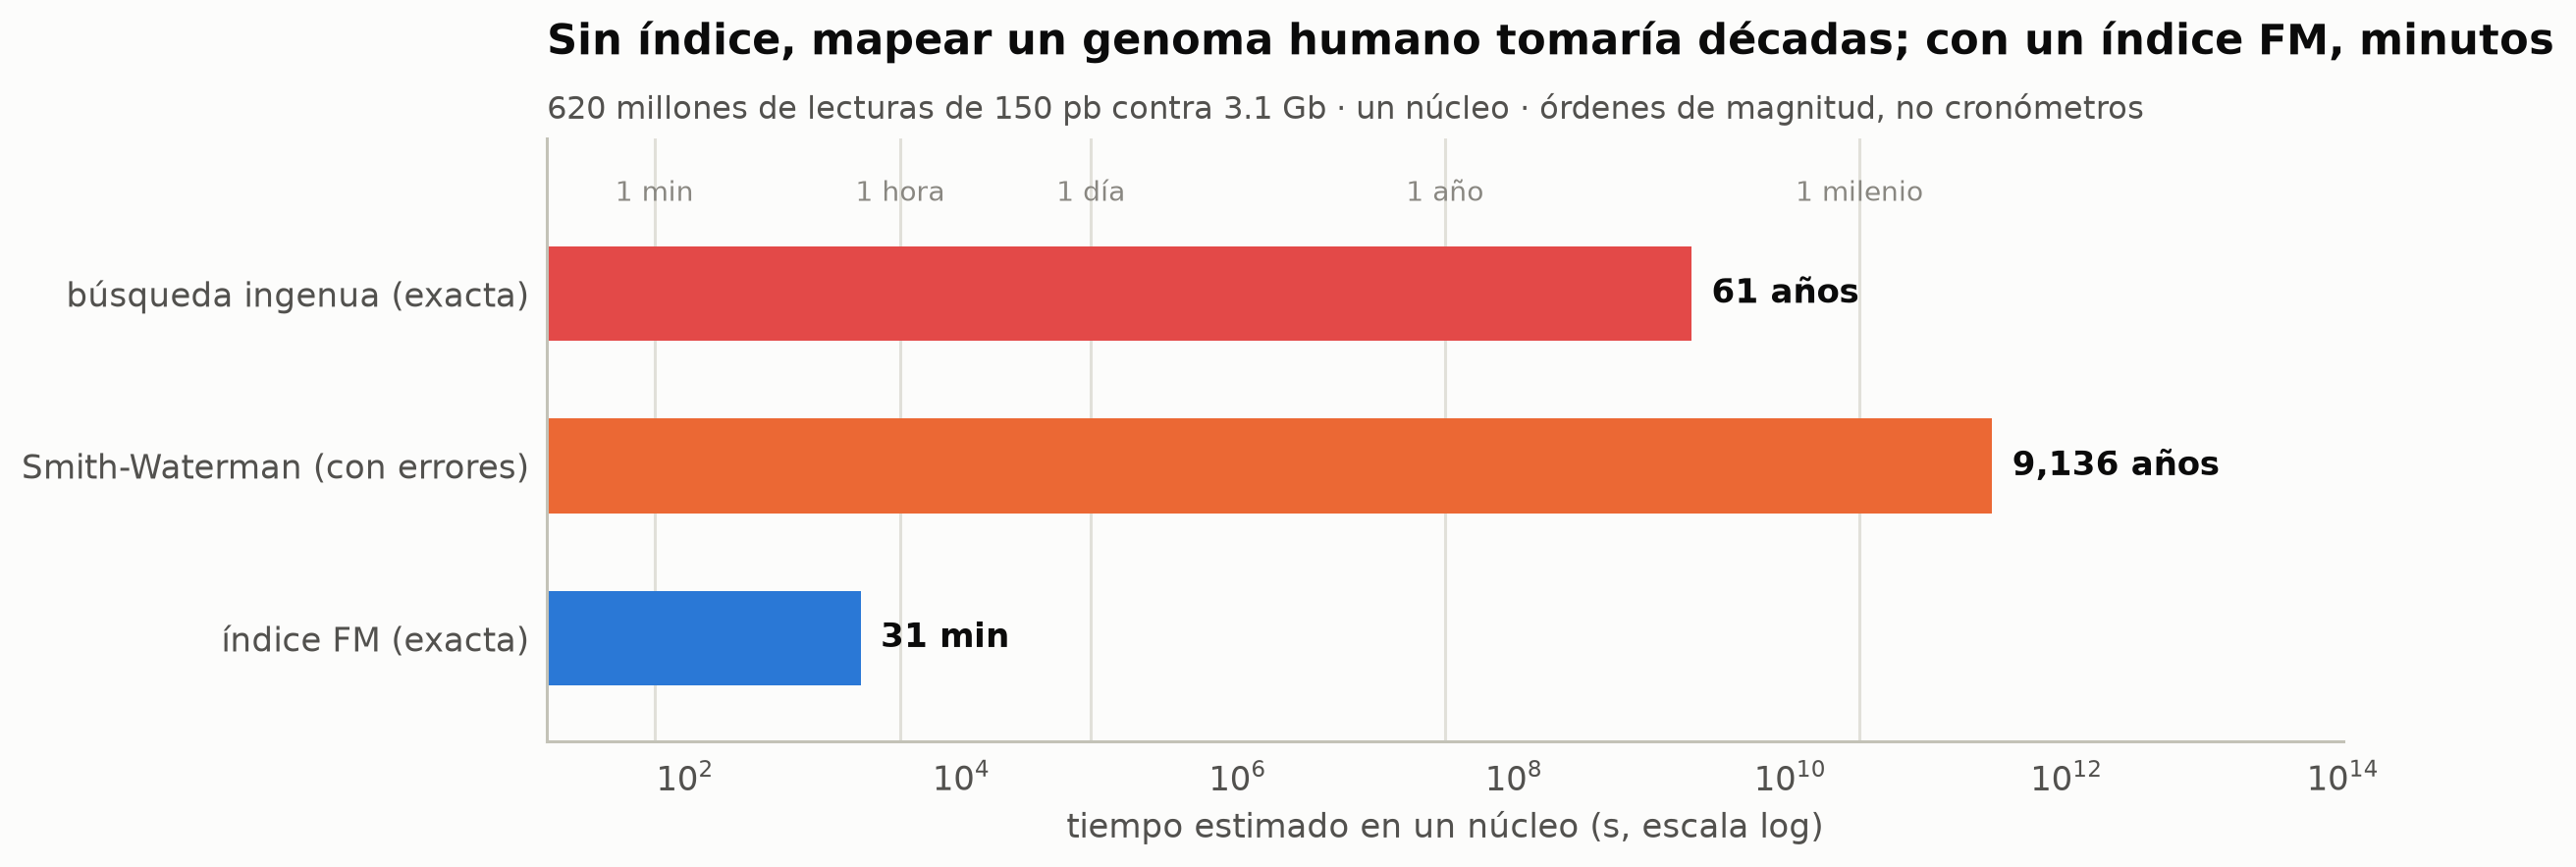

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.9))
ypos = np.arange(len(estimates))[::-1]
cols = [ec.RED, ec.ORANGE, ec.BLUE]
ax.barh(ypos, estimates["segundos"], color=cols, height=0.55)
ax.set_xscale("log"); ax.set_yticks(ypos, estimates["método"])
refs = [(60, "1 min"), (3600, "1 hora"), (86400, "1 día"), (YEAR, "1 año"), (1000 * YEAR, "1 milenio")]
for s, lab in refs:
    ax.axvline(s, color=ec.GRID, lw=1, zorder=0)
    ax.text(s, ypos.max() + 0.5, lab, ha="center", va="bottom", fontsize=9, color=ec.MUTED)
for y, (s, lab) in zip(ypos, zip(estimates["segundos"], estimates["legible"])):
    ax.text(s * 1.4, y, lab, va="center", fontsize=11, color=ec.INK, fontweight="bold")
ax.set_xlim(10, 1e14); ax.set_ylim(-0.6, ypos.max() + 0.9)
ax.set_xlabel("tiempo estimado en un núcleo (s, escala log)")
ax.xaxis.grid(False); ax.yaxis.grid(False)
ec.title(ax, "Sin índice, mapear un genoma humano tomaría décadas; con un índice FM, minutos",
         "620 millones de lecturas de 150 pb contra 3.1 Gb · un núcleo · órdenes de magnitud, no cronómetros")
plt.show()

> 🔎 **Qué observamos.** Entre la búsqueda ingenua y el índice FM hay **seis órdenes de magnitud**, y la diferencia
> crece con el genoma: la búsqueda ingenua es proporcional a $G$, el índice FM no. Todo lo que sigue en esta clase
> consiste en entender **cómo** es posible buscar en un texto sin recorrerlo. Veremos tres índices en orden
> histórico y de sofisticación: la tabla de *k*-mers, el arreglo de sufijos y el índice FM, basado en la
> transformada de Burrows-Wheeler, que es el corazón de **BWA**, **Bowtie** y **Bowtie2**.

## 2. Primer índice: la tabla de *k*-mers

La idea más directa es la del índice de un libro: para cada "palabra" del genoma, anotar las páginas donde aparece.
En ADN no hay espacios entre palabras, así que llamamos "palabra" a cada **_k_-mer**: cada subcadena de longitud $k$.
Recorremos el genoma **una vez** y guardamos, en un diccionario (tabla *hash*), la lista de posiciones de cada *k*-mer.

### Ejemplo a mano

Texto $T = $ `GATTACAGATTACA` (posiciones 0 a 13), $k = 3$:

| *k*-mer | posiciones |
|---|---|
| `GAT` | 0, 7 |
| `ATT` | 1, 8 |
| `TTA` | 2, 9 |
| `TAC` | 3, 10 |
| `ACA` | 4, 11 |
| `CAG` | 5 |
| `AGA` | 6 |

Para buscar la lectura `TTACA` tomamos su primer 3-mer, `TTA`, consultamos la tabla (posiciones 2 y 9) y
**verificamos** el resto de la lectura sólo en esas dos posiciones. Es la estrategia de "semilla y extensión" de
BLAST (Lección 3.4) y de los primeros mapeadores de lecturas cortas (MAQ, SOAP, 2008).

El costo de una consulta es constante, pero la **memoria** es el problema. Hay $G - k + 1$ posiciones, y cada una
necesita al menos un entero de 4 bytes, más el costo de la tabla misma:

$$
\text{memoria}_{k\text{-mers}} \;\gtrsim\; 4\,G\ \text{bytes} \;+\; \underbrace{\min(4^{k},\, G)\cdot e}_{\text{claves}}
$$

| Símbolo | Significado |
|---|---|
| $G$ | longitud del genoma |
| $k$ | longitud del *k*-mer (semilla) |
| $4^{k}$ | número de *k*-mers posibles con 4 letras |
| $e$ | bytes por entrada de la tabla (en C, ~8–16; en un diccionario de Python, más de 100) |

¿Qué $k$ elegir? Si el genoma fuera una secuencia al azar con las cuatro bases equiprobables, un *k*-mer concreto
aparecería **por azar** en promedio

$$
\mathbb{E}[N_k] = \frac{G - k + 1}{4^{k}} \approx \frac{G}{4^{k}}
$$

veces ($N_k$: número de posiciones donde aparece por azar un *k*-mer dado). En el genoma humano, un 12-mer aparece por
azar unas **185** veces, un 16-mer **0.72** veces y un 20-mer apenas **0.0028** veces: una semilla necesita unas 20
bases para que una coincidencia exacta sea informativa. Pero una tabla directa indexada por *k*-mer necesita $4^k$
entradas: con enteros de 32 bits, 64 MiB para $k = 12$ y 16 GiB para $k = 16$, antes de guardar una sola posición.

Para el genoma humano, sólo las posiciones ya ocupan $4 \times 3.1\times10^{9} \approx 12$ GB. Y hay un segundo
problema: $k$ queda **fijo** al construir el índice. Si la lectura tiene un error dentro de la semilla, la consulta
falla; si $k$ es pequeño, las semillas aparecen miles de veces en las repeticiones.

In [4]:
def build_kmer_index(text, k):
    """Diccionario k-mer -> lista de posiciones (0-based) donde empieza."""
    index = {}
    for i in range(len(text) - k + 1):
        index.setdefault(text[i:i + k], []).append(i)
    return index

def kmer_search(index, text, pattern, k):
    """Busca `pattern` exacto: toma su primer k-mer como semilla y verifica el resto."""
    return [i for i in index.get(pattern[:k], []) if text[i:i + len(pattern)] == pattern]

toy_index = build_kmer_index("GATTACAGATTACA", 3)
print("tabla de 3-mers:", toy_index)
print("TTACA aparece en:", kmer_search(toy_index, "GATTACAGATTACA", "TTACA", 3))

# El mismo índice sobre SARS-CoV-2, midiendo cuánto ocupa en memoria un diccionario de Python
def dict_bytes(index):
    return sys.getsizeof(index) + sum(sys.getsizeof(k) + sys.getsizeof(v) + 28 * len(v) for k, v in index.items())

kmer_rows = []
for k in (4, 8, 11, 16, 24):
    t0 = time.perf_counter()
    idx = build_kmer_index(SARS, k)
    kmer_rows.append({"k": k, "k-mers distintos": len(idx), "posibles 4^k": 4 ** k,
                      "construcción (s)": time.perf_counter() - t0,
                      "bytes por base": dict_bytes(idx) / len(SARS),
                      "k-mers únicos (%)": 100 * np.mean([len(v) == 1 for v in idx.values()])})
kmer_table = pd.DataFrame(kmer_rows)
kmer_table.style.format({"posibles 4^k": "{:.3g}", "construcción (s)": "{:.3f}", "bytes por base": "{:.0f}",
                         "k-mers únicos (%)": "{:.1f}"})

tabla de 3-mers: {'GAT': [0, 7], 'ATT': [1, 8], 'TTA': [2, 9], 'TAC': [3, 10], 'ACA': [4, 11], 'CAG': [5], 'AGA': [6]}
TTACA aparece en: [2, 9]


,k,k-mers distintos,posibles 4^k,construcción (s),bytes por base,k-mers únicos (%)
0,4,256,256,0.006,38,0.0
1,8,20185,6.55e+04,0.009,135,67.9
2,11,29566,4.19e+06,0.008,199,99.0
3,16,29866,4.29e+09,0.038,205,100.0
4,24,29871,2.81e+14,0.010,213,100.0


> 🔎 **Qué observamos.** Con $k = 4$ sólo existen 256 *k*-mers posibles y todos aparecen muchas veces: una semilla de 4
> letras no discrimina nada. A partir de $k \approx 11$, casi todos los *k*-mers del virus son únicos, pero cada base
> del genoma cuesta **más de cien bytes** en un diccionario de Python. Extrapolado al genoma humano serían cientos de
> gigabytes; incluso en C, con 4 bytes por posición, no bajamos de 12 GB. Necesitamos un índice que no dependa de un
> $k$ fijo y que ocupe menos.

> ✅ **Compruebe su comprensión.** ¿Por qué con $k = 16$ el número de *k*-mers distintos es casi igual a $G$ y no a
> $4^{16} \approx 4.3\times10^{9}$? (Respuesta: un texto de $G$ letras contiene como mucho $G - k + 1$ *k*-mers; con
> $4^k \gg G$, casi ninguno se repite y la tabla tiene tantas claves como posiciones.)

## 3. El arreglo de sufijos: `BANANA$` ordenado y búsqueda binaria

### La intuición

Un **sufijo** de un texto es lo que queda al empezar a leer desde cierta posición hasta el final. Todo patrón que
aparece en el texto es el **comienzo** (prefijo) de algún sufijo: `ANA` aparece en `BANANA` porque los sufijos
`ANANA` y `ANA` empiezan por `ANA`. Si ordenamos **alfabéticamente** todos los sufijos, como las palabras de un
diccionario, los que empiezan por `ANA` quedan **juntos**, en un bloque contiguo. Encontrar ese bloque es una
**búsqueda binaria**, igual que buscar una palabra en un diccionario de papel: abrir por la mitad, decidir si
seguir hacia adelante o hacia atrás, y repetir.

Añadimos al final del texto un símbolo centinela `$` que **no aparece** en el texto y que, por convenio, es **menor**
que cualquier letra. Así ningún sufijo es prefijo de otro y el orden queda bien definido.

El **arreglo de sufijos** (Manber y Myers, 1993) es la lista de posiciones de inicio de los sufijos, en orden
alfabético:

$$
T[\mathrm{SA}[0]..] \;<\; T[\mathrm{SA}[1]..] \;<\; \cdots \;<\; T[\mathrm{SA}[n-1]..]
$$

donde $T[i..]$ es el sufijo que empieza en la posición $i$ (numeramos desde cero) y $\mathrm{SA}[r]$ es la posición
del sufijo que ocupa el lugar $r$ en el orden alfabético. A lo largo de la clase usaremos siempre la misma
convención que el libro del curso: **$i$ para posiciones del texto y $r$ para filas** (lugares en el orden).

| Símbolo | Significado |
|---|---|
| $T$, $n$ | texto indexado (la referencia $R$ más el centinela `$`) y su longitud, $n = G + 1$ |
| $T[i..]$ | sufijo de $T$ que empieza en la posición $i$ |
| $\mathrm{SA}[r]$ | posición en $T$ del sufijo que ocupa el lugar $r$ en el orden alfabético |

### Ejemplo a mano: $T = $ `BANANA$`

Escribimos los 7 sufijos con su posición y luego los ordenamos (`$` < `A` < `B` < `N`):

| posición $i$ | sufijo $T[i..]$ | | fila $r$ | $\mathrm{SA}[r]$ | sufijo ordenado |
|---|---|---|---|---|---|
| 0 | `BANANA$` | | 0 | 6 | `$` |
| 1 | `ANANA$` | | 1 | 5 | `A$` |
| 2 | `NANA$` | | 2 | 3 | `ANA$` |
| 3 | `ANA$` | | 3 | 1 | `ANANA$` |
| 4 | `NA$` | | 4 | 0 | `BANANA$` |
| 5 | `A$` | | 5 | 4 | `NA$` |
| 6 | `$` | | 6 | 2 | `NANA$` |

Así, $\mathrm{SA} = [6, 5, 3, 1, 0, 4, 2]$. Buscamos el bloque de filas que empiezan por `ANA`. Lo describiremos,
como el libro, con un intervalo **semiabierto** $[sp, ep)$: $sp$ es la **primera** fila del bloque y $ep$ la primera
fila que **ya no** pertenece a él. Es la misma convención que usa Python en `lista[sp:ep]`, y tiene dos ventajas: el
número de apariciones es simplemente $ep - sp$, y un bloque vacío es el que tiene $sp = ep$.

1. Empezamos con todas las filas, $[0, 7)$. La del medio es la fila 3, `ANANA$`. Sus 3 primeras letras son `ANA`:
   **coincide**. Buscamos el borde izquierdo del bloque hacia arriba y el derecho hacia abajo.
2. Borde izquierdo ($sp$): la fila 1 (`A$`) es **menor** que `ANA`; la fila 2 (`ANA$`) coincide → $sp = 2$.
3. Borde derecho ($ep$): la fila 4 (`BANANA$`) es **mayor** que `ANA`, y es la primera que ya no coincide → $ep = 4$.
4. Resultado: filas $[2, 4)$, es decir, las filas 2 y 3 → posiciones $\mathrm{SA}[2] = 3$ y $\mathrm{SA}[3] = 1$.
   En efecto, `BAN`**`ANA`** y `B`**`ANA`**`NA`: $4 - 2 = 2$ apariciones.

Cada paso de la búsqueda binaria compara hasta $m$ letras, y hay $\log_2 n$ pasos:

$$
T_{\text{SA}} = O(m \log_2 n), \qquad \log_2(3.1\times10^{9}) \approx 32 \text{ pasos para el genoma humano}
$$

| Símbolo | Significado |
|---|---|
| $\mathrm{SA}$ | arreglo de sufijos: $n$ enteros, cada uno una posición del texto |
| $[sp, ep)$ | intervalo **semiabierto** de filas (*start*, *end pointer*) cuyos sufijos empiezan por el patrón: incluye $sp$, excluye $ep$ |
| $ep - sp$ | número de apariciones del patrón (0 si $sp = ep$) |
| $m$ | longitud del patrón |

¡Treinta y dos pasos en lugar de tres mil millones! El precio es la memoria: el arreglo necesita
$n\lceil\log_2 n\rceil$ bits, es decir, 32 bits (4 bytes) por posición en el genoma humano: unos **12 GB**, a los
que hay que sumar los ~3 GB del propio texto. En 2008 eso era más memoria de la que tenía un servidor típico. El
índice FM conservará la búsqueda por intervalos y reducirá esa memoria a una fracción.

In [5]:
def suffix_array_naive(text):
    """Arreglo de sufijos por definición: ordena las posiciones por el sufijo que empieza en ellas.
    Sólo para textos pequeños: crea n copias de sufijos, O(n² log n) en el peor caso."""
    return sorted(range(len(text)), key=lambda j: text[j:])

def sa_interval(text, sa, pattern):
    """Búsqueda binaria del bloque semiabierto [sp, ep) de filas cuyos sufijos empiezan por `pattern`
    (vacío si sp == ep; el patrón aparece ep - sp veces)."""
    m = len(pattern)
    lo, hi = 0, len(sa)                      # borde izquierdo: primer sufijo con prefijo >= patrón
    while lo < hi:
        mid = (lo + hi) // 2
        if text[sa[mid]:sa[mid] + m] < pattern: lo = mid + 1
        else: hi = mid
    sp, hi = lo, len(sa)                     # borde derecho: primer sufijo con prefijo > patrón (= ep)
    while lo < hi:
        mid = (lo + hi) // 2
        if text[sa[mid]:sa[mid] + m] <= pattern: lo = mid + 1
        else: hi = mid
    return sp, lo

T_BAN = "BANANA$"
SA_BAN = suffix_array_naive(T_BAN)
print("SA(BANANA$) =", SA_BAN)
for r, i in enumerate(SA_BAN):
    print(f"  fila r = {r}: SA[r] = {i}  {T_BAN[i:]}")
sp, ep = sa_interval(T_BAN, SA_BAN, "ANA")
print(f"ANA → filas [{sp}, {ep}) → {ep - sp} apariciones en las posiciones {sorted(SA_BAN[sp:ep])}")

SA(BANANA$) = [6, 5, 3, 1, 0, 4, 2]
  fila r = 0: SA[r] = 6  $
  fila r = 1: SA[r] = 5  A$
  fila r = 2: SA[r] = 3  ANA$
  fila r = 3: SA[r] = 1  ANANA$
  fila r = 4: SA[r] = 0  BANANA$
  fila r = 5: SA[r] = 4  NA$
  fila r = 6: SA[r] = 2  NANA$
ANA → filas [2, 4) → 2 apariciones en las posiciones [1, 3]


Para dibujar la búsqueda registramos cada fila que la búsqueda binaria "abre" en el diccionario de sufijos. Usamos un
texto de ADN algo más largo, `GATTACAGATTACA$`, que reutilizaremos en toda la clase, y buscamos `TTA`.

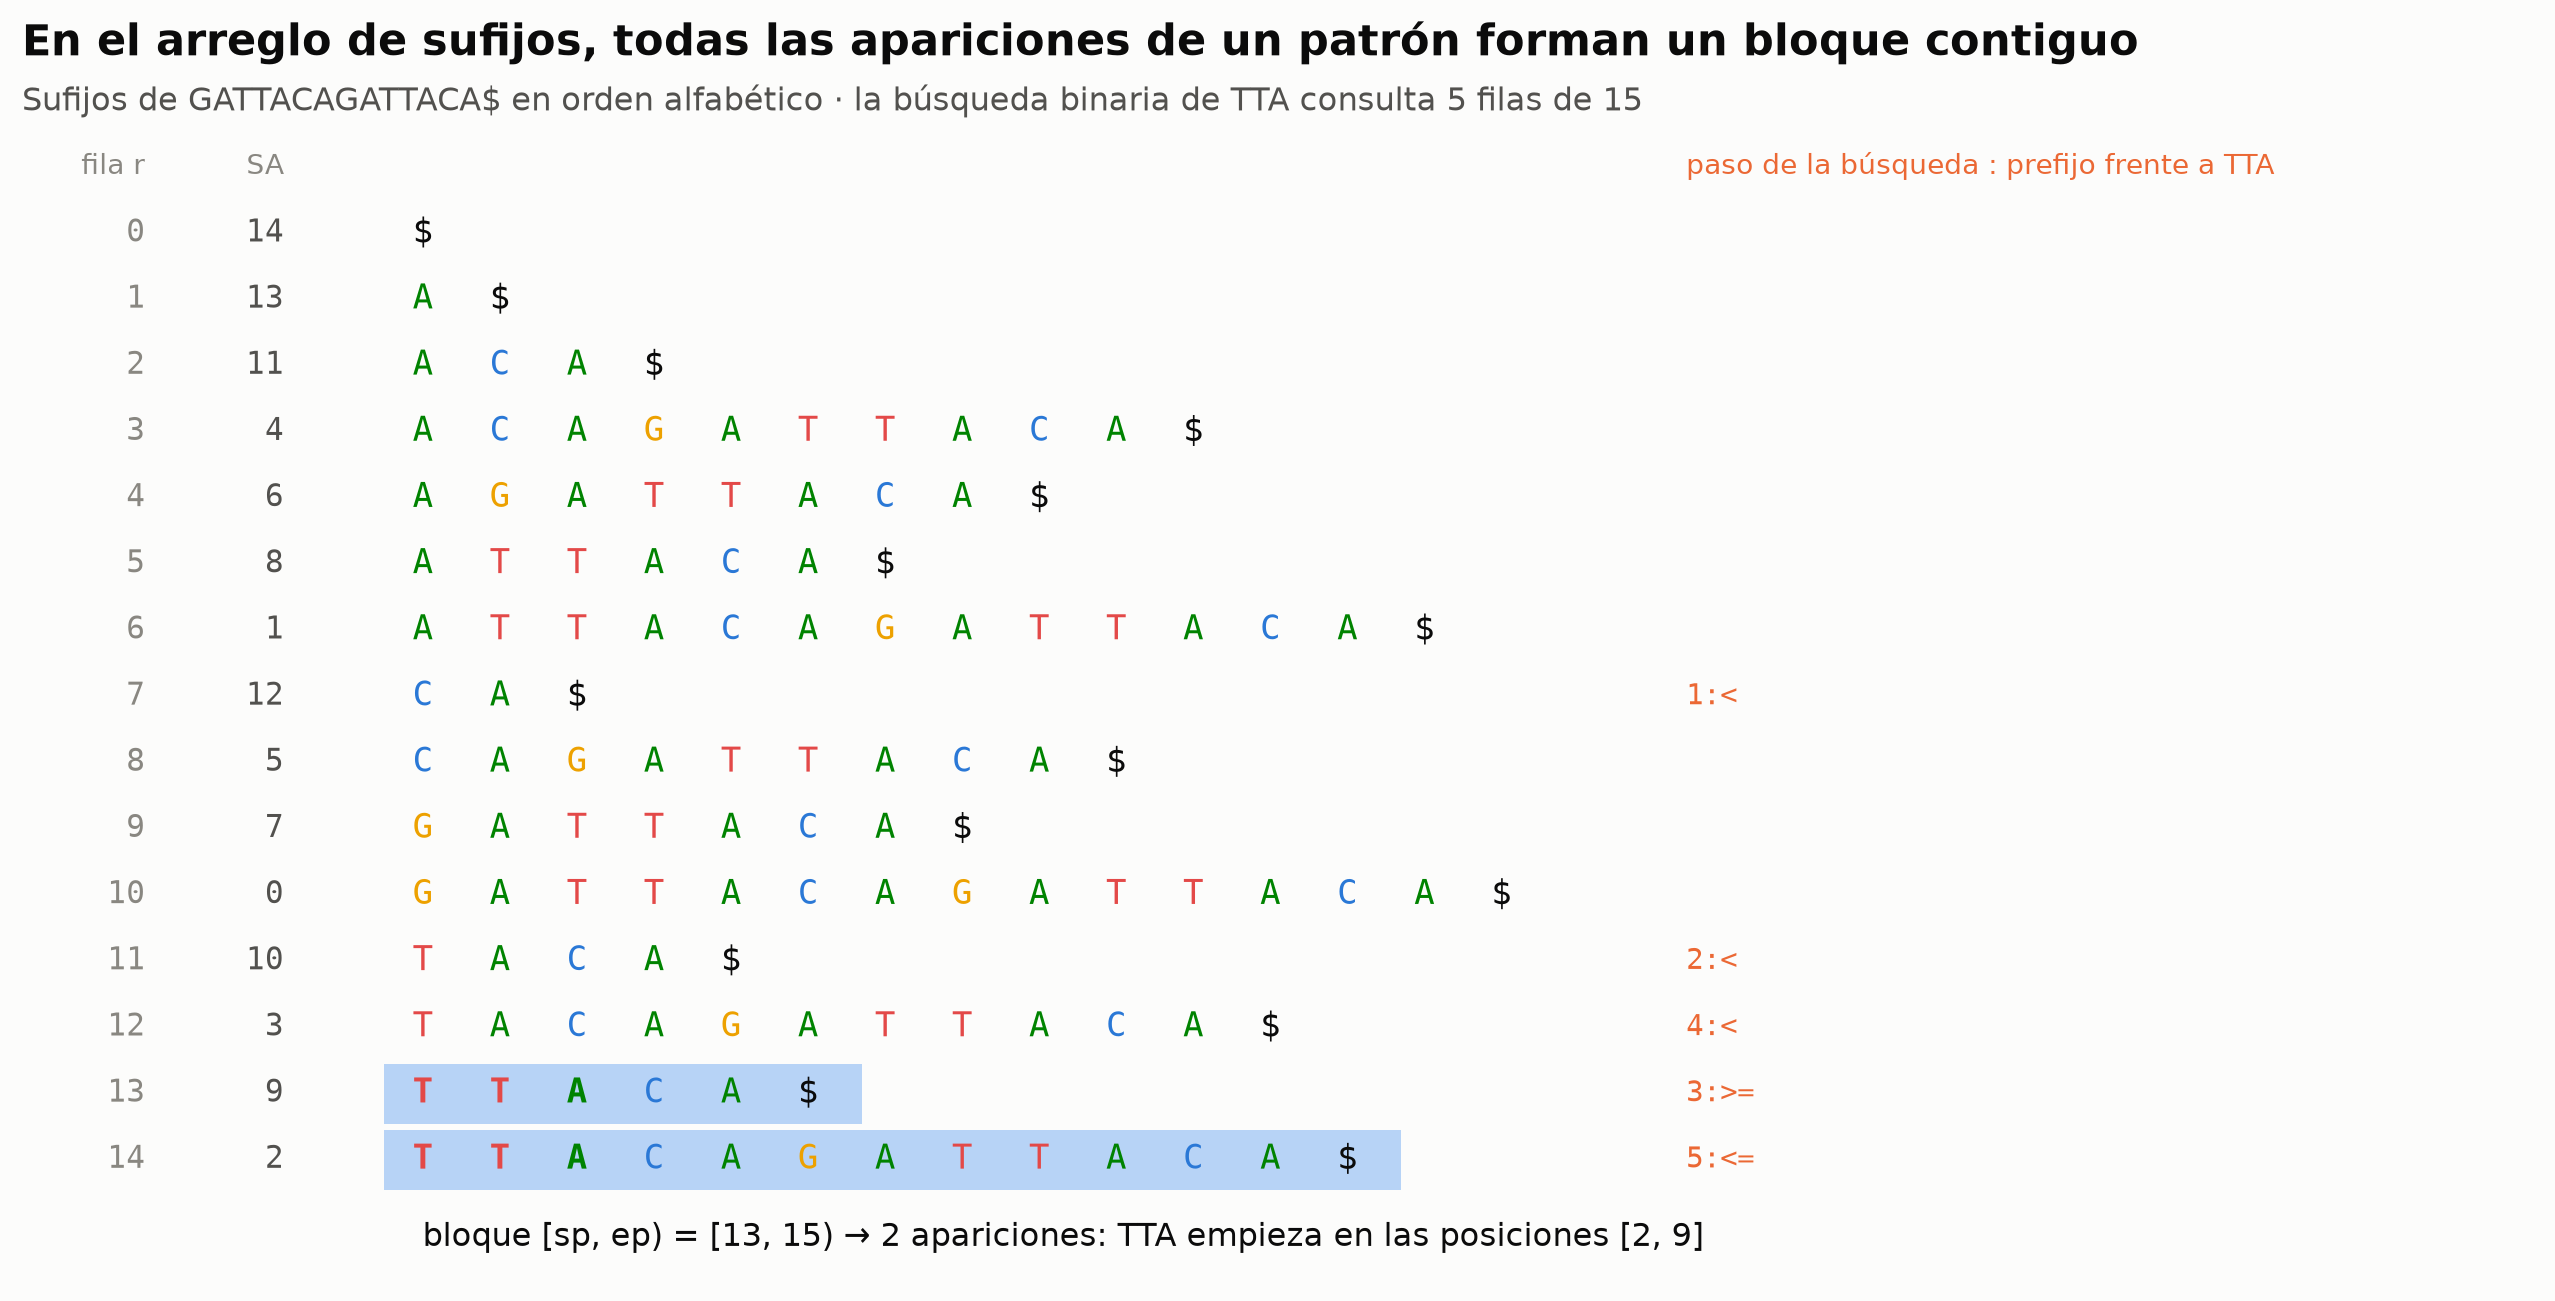

In [6]:
def sa_interval_trace(text, sa, pattern):
    """Como sa_interval, pero devuelve también la lista de filas consultadas (en orden) y su veredicto."""
    m, probes = len(pattern), []
    lo, hi = 0, len(sa)
    while lo < hi:
        mid = (lo + hi) // 2; pre = text[sa[mid]:sa[mid] + m]
        probes.append((mid, "izq", "<" if pre < pattern else ">="))
        if pre < pattern: lo = mid + 1
        else: hi = mid
    sp, hi = lo, len(sa)
    while lo < hi:
        mid = (lo + hi) // 2; pre = text[sa[mid]:sa[mid] + m]
        probes.append((mid, "der", "<=" if pre <= pattern else ">"))
        if pre <= pattern: lo = mid + 1
        else: hi = mid
    return (sp, lo), probes

T_DNA = "GATTACAGATTACA$"
SA_DNA = suffix_array_naive(T_DNA)
(sp_d, ep_d), probes = sa_interval_trace(T_DNA, SA_DNA, "TTA")

fig, ax = plt.subplots(figsize=(11.5, 5.8))
n_d = len(T_DNA)
for i, j in enumerate(SA_DNA):
    suf = T_DNA[j:]
    y = n_d - 1 - i
    if sp_d <= i < ep_d:
        ax.add_patch(Rectangle((1.55, y - 0.45), len(suf) * 0.5 + 0.1, 0.9, fc=ec.SEQ_BLUE[1], ec="none"))
    ax.text(0.0, y, f"{i:>2}", ha="right", va="center", fontsize=10, color=ec.MUTED, family="monospace")
    ax.text(0.9, y, f"{j:>2}", ha="right", va="center", fontsize=10, color=ec.INK_2, family="monospace")
    for k, ch in enumerate(suf):
        ax.text(1.8 + k * 0.5, y, ch, ha="center", va="center", fontsize=11, family="monospace",
                color=ec.NUC_COLORS.get(ch, ec.INK), fontweight="bold" if k < 3 and sp_d <= i < ep_d else "normal")
order_lab = {}
for step, (row, side, verdict) in enumerate(probes, start=1):
    order_lab.setdefault(row, []).append(f"{step}:{verdict}")
for row, labs in order_lab.items():
    ax.text(10.0, n_d - 1 - row, "  ".join(labs), va="center", fontsize=9.5, color=ec.ORANGE, family="monospace")
ax.text(0.0, n_d - 0.1, "fila r", ha="right", fontsize=9, color=ec.MUTED)
ax.text(0.9, n_d - 0.1, "SA", ha="right", fontsize=9, color=ec.MUTED)
ax.text(10.0, n_d - 0.1, "paso de la búsqueda : prefijo frente a TTA", fontsize=9, color=ec.ORANGE)
ax.text(1.8, -1.3, f"bloque [sp, ep) = [{sp_d}, {ep_d}) → {ep_d - sp_d} apariciones: TTA empieza en las posiciones "
        f"{sorted(SA_DNA[sp_d:ep_d])}", fontsize=10.5, color=ec.INK)
ax.set_xlim(-0.8, 15.5); ax.set_ylim(-1.8, n_d + 0.4); ax.axis("off")
ec.title(ax, "En el arreglo de sufijos, todas las apariciones de un patrón forman un bloque contiguo",
         f"Sufijos de {T_DNA} en orden alfabético · la búsqueda binaria de TTA consulta {len(probes)} filas de {n_d}")
plt.show()

> 🔎 **Qué observamos.** Las dos apariciones de `TTA` (posiciones 2 y 9 del texto) quedan en filas **vecinas** (13 y
> 14, el bloque $[13, 15)$) aunque estén lejos en el genoma. La búsqueda binaria no mira las 15 filas: sólo unas pocas, y cada consulta
> descarta la mitad de lo que queda. En un genoma de 4.6 Mb bastarían unas 22 consultas por borde.

### Construir el arreglo de sufijos de un genoma entero

`sorted(range(n), key=lambda j: text[j:])` crea una copia de cada sufijo: para 30 000 bases serían 450 millones de
letras en memoria, e imposible para *E. coli*. Usamos el algoritmo de **duplicación de prefijos** (*prefix doubling*,
la idea de Manber y Myers): si ya sabemos ordenar los sufijos por sus primeras $h$ letras, podemos ordenarlos por sus
primeras $2h$ letras usando **pares de rangos**, porque

$$
T[j..j+2h-1] = \underbrace{T[j..j+h-1]}_{\text{rango}_h(j)}\ \Vert\ \underbrace{T[j+h..j+2h-1]}_{\text{rango}_h(j+h)}
$$

Cada ronda es un solo ordenamiento de números (NumPy lo hace en C) y la longitud comparada se duplica: 1, 2, 4,
8… letras. El proceso termina cuando todos los rangos son distintos, tras $\lceil\log_2(\ell_{\max}+1)\rceil$ rondas, donde
$\ell_{\max}$ es la longitud de la repetición exacta más larga del genoma.

In [7]:
def suffix_array(text):
    """Arreglo de sufijos por duplicación de prefijos (O(n log n) ordenamientos de enteros, en NumPy).
    `text` debe terminar en un centinela único y menor que las demás letras ('$')."""
    codes = np.frombuffer(text.encode(), dtype=np.uint8)
    n = len(codes)
    _, rank = np.unique(codes, return_inverse=True)       # rango según la 1.ª letra
    rank = rank.astype(np.int64)
    h = 1
    while True:
        second = np.zeros(n, np.int64)                    # rango de la mitad derecha (0 si se sale del texto)
        second[:n - h] = rank[h:] + 1
        key = rank * (n + 1) + second                     # el par (rango_h(j), rango_h(j+h)) como un solo número
        sa = np.argsort(key, kind="stable")
        sorted_key = key[sa]
        new_group = np.r_[True, sorted_key[1:] != sorted_key[:-1]]
        rank = np.empty(n, np.int64)
        rank[sa] = np.cumsum(new_group) - 1
        if rank[sa[-1]] == n - 1:                         # todos los rangos distintos: orden completo
            return sa
        h *= 2

# Verificación contra la definición en textos pequeños
for t in [T_BAN, T_DNA, SARS[:3000] + "$"]:
    assert list(suffix_array(t)) == suffix_array_naive(t)
t0 = time.perf_counter()
SA_SARS = suffix_array(SARS + "$")
print(f"✔ coincide con la definición · SA de SARS-CoV-2 ({len(SARS) + 1:,} sufijos) en {time.perf_counter() - t0:.2f} s")

✔ coincide con la definición · SA de SARS-CoV-2 (29,904 sufijos) en 0.01 s


> ✅ **Compruebe su comprensión.** En el arreglo de sufijos de `BANANA$`, ¿qué bloque de filas corresponde al patrón
> `NA`? ¿Y al patrón `BAN`? ¿Qué devuelve la búsqueda para `NAB`? (Respuesta: `NA` → filas $[5, 7)$, posiciones 4 y 2;
> `BAN` → $[4, 5)$, una sola fila, posición 0; `NAB` → bloque vacío, $sp = ep$, porque ningún sufijo empieza por `NAB`.)

## 4. La transformada de Burrows-Wheeler: rotaciones, columnas $F$ y $L$

En 1994, Michael Burrows y David Wheeler publicaron un algoritmo de **compresión** de textos (la base del programa
`bzip2`). Seis años después, Paolo Ferragina y Giovanni Manzini descubrieron que esa misma transformación permite
**buscar** dentro del texto comprimido. Esa combinación es lo que hace posible guardar el genoma humano indexado en
unos pocos gigabytes.

### La receta en tres pasos

1. Escriba todas las **rotaciones** del texto $T$ (con su `$` final): la rotación $i$ se obtiene quitando las $i$
   primeras letras y pegándolas al final. Imagine el texto escrito sobre un anillo: cada rotación es empezar a leer
   el anillo en un punto distinto.
2. **Ordene** las rotaciones alfabéticamente. Obtenemos una matriz cuadrada de $n \times n$ letras, la **matriz de
   Burrows-Wheeler** $M$.
3. La **BWT** es la **última columna** de $M$, que llamamos $L$ (*last*). La primera columna se llama $F$ (*first*).

### Ejemplo a mano: `BANANA$`

| rotación $i$ (sin ordenar) | | fila $r$ | rotación ordenada | $F$ | $L$ |
|---|---|---|---|---|---|
| 0 `BANANA$` | | 0 | `$BANANA` | `$` | `A` |
| 1 `ANANA$B` | | 1 | `A$BANAN` | `A` | `N` |
| 2 `NANA$BA` | | 2 | `ANA$BAN` | `A` | `N` |
| 3 `ANA$BAN` | | 3 | `ANANA$B` | `A` | `B` |
| 4 `NA$BANA` | | 4 | `BANANA$` | `B` | `$` |
| 5 `A$BANAN` | | 5 | `NA$BANA` | `N` | `A` |
| 6 `$BANANA` | | 6 | `NANA$BA` | `N` | `A` |

$$
\operatorname{BWT}(\texttt{BANANA\$}) = L = \texttt{ANNB\$AA}, \qquad F = \texttt{\$AAABNN}
$$

Dos observaciones que usaremos todo el tiempo:

* **$F$ no contiene información nueva**: son las letras del texto ordenadas. Basta con saber **cuántas** hay de cada
  una: un `$`, tres `A`, una `B`, dos `N`.
* Como `$` aparece una sola vez y es la menor letra, ordenar **rotaciones** equivale a ordenar **sufijos**: la fila
  $r$ de $M$ empieza con el sufijo $T[\mathrm{SA}[r]..]$. Y la última letra de esa rotación es la letra que
  **precede** al sufijo en el texto. Por eso la BWT sale directamente del arreglo de sufijos, sin construir la matriz:

$$
\boxed{\;L[r] = \begin{cases}
T\big[\mathrm{SA}[r] - 1\big] & \text{si } \mathrm{SA}[r] > 0,\\
\texttt{\$} & \text{si } \mathrm{SA}[r] = 0.
\end{cases}\;}
$$

| Símbolo | Significado |
|---|---|
| $M$ | matriz de rotaciones ordenadas ($n \times n$; nunca se construye en la práctica) |
| $F$ | primera columna de $M$: las letras de $T$ ordenadas |
| $L$ | última columna de $M$: la **BWT** de $T$, $\mathrm{BWT}(T)$ |
| $r$ | número de fila de $M$ (lugar en el orden alfabético) |
| $\mathrm{SA}[r]$ | posición del texto donde empieza la fila $r$ |

En palabras: $L[r]$ es la letra que **precede**, en el texto, al sufijo de la fila $r$. El segundo caso sólo dice
que antes del comienzo del texto "damos la vuelta" al anillo y encontramos el `$` final; en código basta con
$T[(\mathrm{SA}[r] - 1) \bmod n]$, y en Python el índice $-1$ ya hace exactamente eso.

Comprobemos con la fila 2: $\mathrm{SA}[2] = 3$ (el sufijo `ANA$`) y $T[2] = $ `N`, que es $L[2]$. ✔

In [8]:
def rotations_sorted(text):
    """Matriz de Burrows-Wheeler por definición (sólo para textos cortos)."""
    return sorted(text[j:] + text[:j] for j in range(len(text)))

def bwt_from_sa(text, sa):
    """BWT como L[r] = T[SA[r] - 1] (el índice -1 de NumPy da la vuelta al '$')."""
    codes = np.frombuffer(text.encode(), dtype=np.uint8)
    return codes[np.asarray(sa) - 1].tobytes().decode()

M_ban = rotations_sorted(T_BAN)
print("Matriz M de BANANA$:")
for i, row in enumerate(M_ban):
    print(f"  {i}  {row[0]} {row[1:-1]} {row[-1]}")
L_ban = "".join(r[-1] for r in M_ban)
print("L por la matriz :", L_ban, "· L por el SA:", bwt_from_sa(T_BAN, SA_BAN))
L_DNA = bwt_from_sa(T_DNA, SA_DNA)
print(f"BWT({T_DNA}) = {L_DNA}")
assert L_DNA == "".join(r[-1] for r in rotations_sorted(T_DNA))

Matriz M de BANANA$:
  0  $ BANAN A
  1  A $BANA N
  2  A NA$BA N
  3  A NANA$ B
  4  B ANANA $
  5  N A$BAN A
  6  N ANA$B A
L por la matriz : ANNB$AA · L por el SA: ANNB$AA
BWT(GATTACAGATTACA$) = ACTTCGGAAA$TTAA


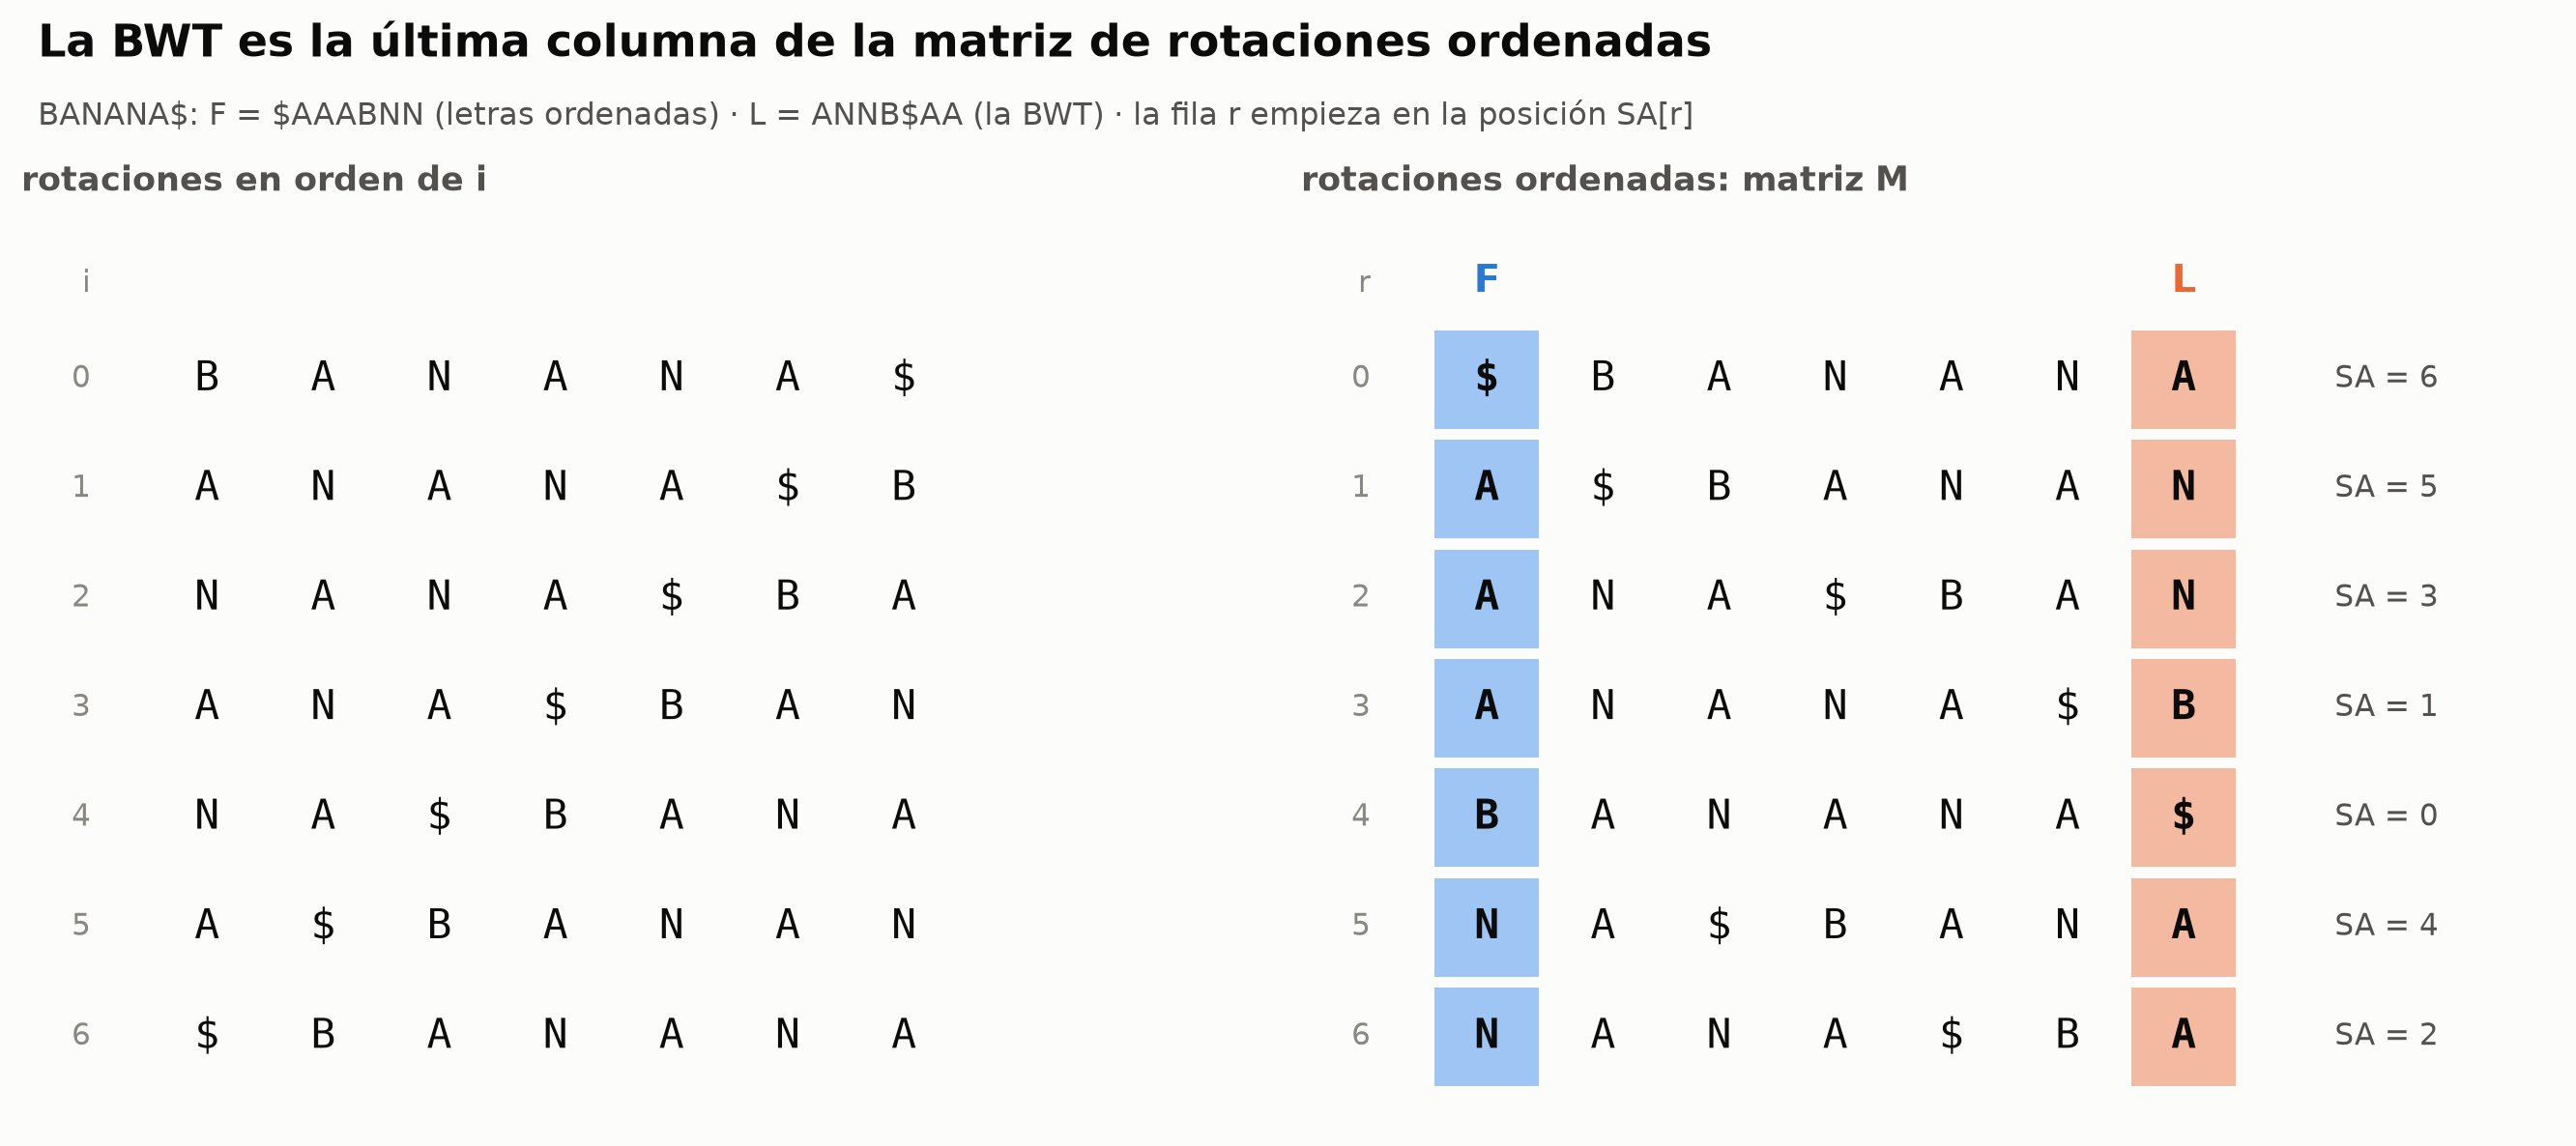

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
unsorted = [T_BAN[j:] + T_BAN[:j] for j in range(len(T_BAN))]
for ax, rows, lab, show_fl in [(axes[0], unsorted, "rotaciones en orden de i", False),
                               (axes[1], M_ban, "rotaciones ordenadas: matriz M", True)]:
    n_r = len(rows)
    for i, row in enumerate(rows):
        for k, ch in enumerate(row):
            is_f, is_l = show_fl and k == 0, show_fl and k == n_r - 1
            fc = ec.SEQ_BLUE[2] if is_f else (ec.ORANGE if is_l else "none")
            if fc != "none":
                ax.add_patch(Rectangle((k - 0.45, n_r - 1 - i - 0.45), 0.9, 0.9, fc=fc, ec="none",
                                       alpha=0.45 if is_l else 1))
            ax.text(k, n_r - 1 - i, ch, ha="center", va="center", fontsize=14, family="monospace",
                    color=ec.INK, fontweight="bold" if (is_f or is_l) else "normal")
        ax.text(-1.0, n_r - 1 - i, str(i if show_fl else i), ha="right", va="center", fontsize=10, color=ec.MUTED)
    if show_fl:
        ax.text(0, n_r - 0.2, "F", ha="center", fontsize=13, fontweight="bold", color=ec.BLUE)
        ax.text(n_r - 1, n_r - 0.2, "L", ha="center", fontsize=13, fontweight="bold", color=ec.ORANGE)
        for i, j in enumerate(SA_BAN):
            ax.text(n_r + 0.3, n_r - 1 - i, f"SA = {j}", va="center", fontsize=10, color=ec.INK_2)
    ax.text(-1.0, n_r - 0.2, "r" if show_fl else "i", ha="right", fontsize=10, color=ec.MUTED)
    ax.set_xlim(-1.6, n_r + 2.2); ax.set_ylim(-0.8, n_r + 0.4); ax.axis("off")
    ax.set_title(lab, fontsize=11.5, color=ec.INK_2, loc="left")
ec.fig_title(fig, "La BWT es la última columna de la matriz de rotaciones ordenadas",
             "BANANA$: F = $AAABNN (letras ordenadas) · L = ANNB$AA (la BWT) · la fila r empieza en la posición SA[r]")
plt.show()

### 🎛️ La matriz de Burrows-Wheeler de un ADN, explorada con el cursor

La figura siguiente muestra la matriz $M$ de `GATTACAGATTACA$`. Cada casilla está coloreada por su nucleótido. Pase el
cursor por cualquier fila para ver la rotación completa, la posición del sufijo en el texto ($\mathrm{SA}[r]$), la letra de
$L$ con su **rango** (cuántas veces apareció antes esa misma letra en $L$) y la fila a la que la envía la función
$\mathrm{LF}$, que explicaremos en la sección 6.

> 🤔 **Antes de ejecutar, prediga:** el texto contiene dos veces `GATTACA`. ¿Espera ver en la columna $L$ letras
> iguales **consecutivas**? ¿Cuántas?

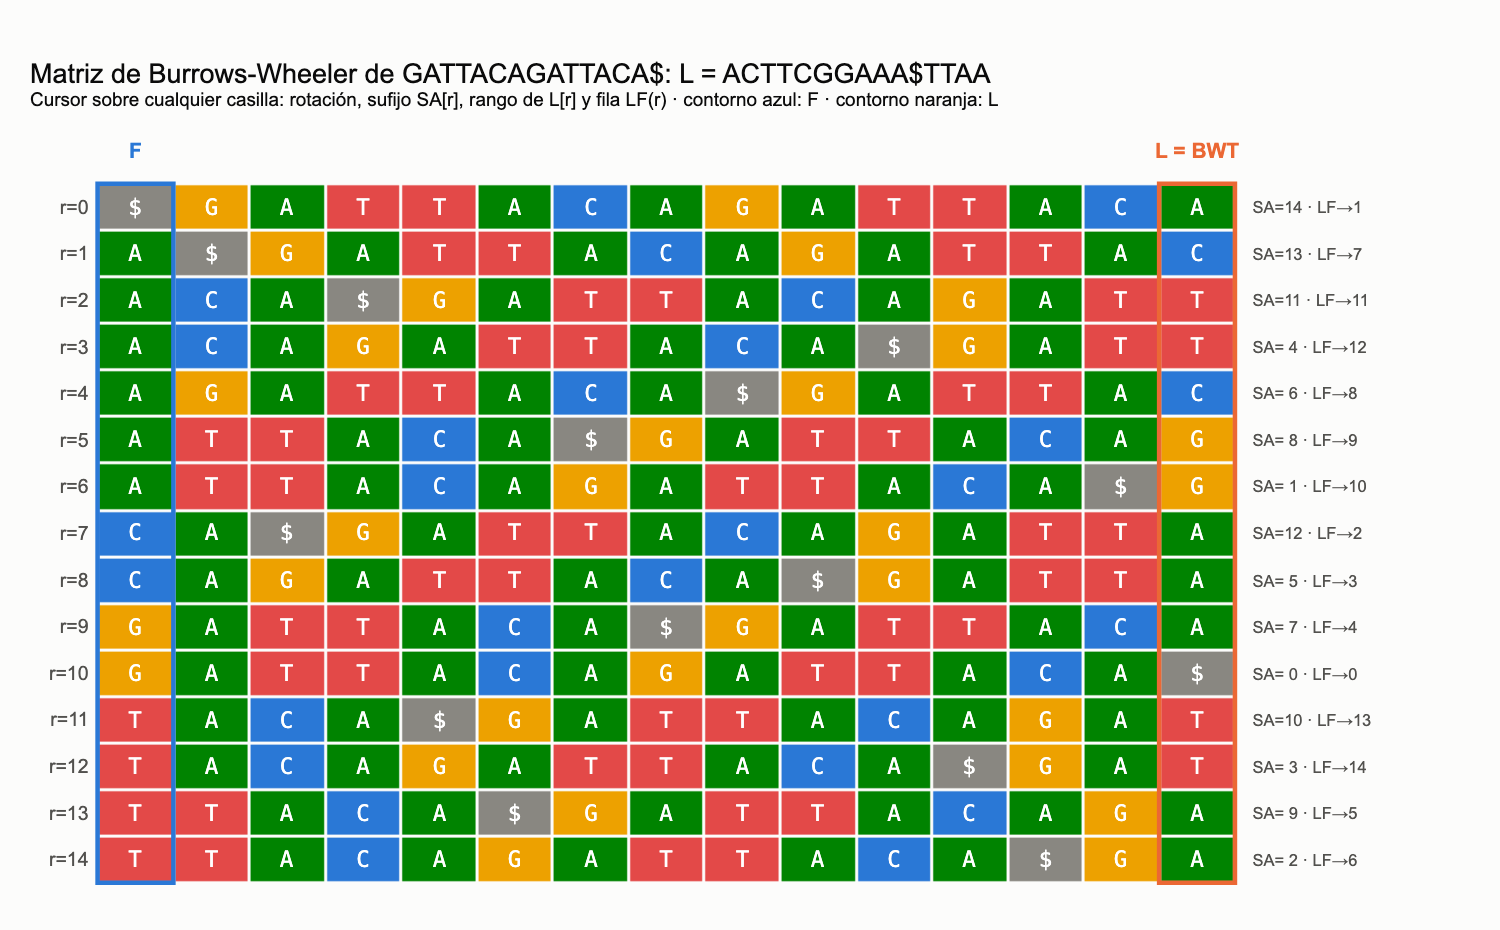

In [10]:
ALPHA_COLORS = {"$": ec.MUTED, **ec.NUC_COLORS}

def lf_table(L):
    """Para cada fila r: rango de L[r] (cuántas L[r] hay antes en L) y LF(r) = C[L[r]] + rango."""
    C, total = {}, 0
    for c in sorted(set(L)):
        C[c] = total; total += L.count(c)
    seen, ranks, lf = {}, [], []
    for c in L:
        r = seen.get(c, 0); ranks.append(r); lf.append(C[c] + r); seen[c] = r + 1
    return C, ranks, lf

def bwt_matrix_figure(text, title):
    rows = rotations_sorted(text)
    sa = suffix_array_naive(text)
    L = "".join(r[-1] for r in rows)
    C, ranks, lf = lf_table(L)
    n = len(text)
    symbols = sorted(set(text))
    z = [[symbols.index(ch) for ch in row] for row in rows]
    colorscale = []
    for k, s in enumerate(symbols):
        colorscale += [[k / len(symbols), ALPHA_COLORS.get(s, ec.MUTED)], [(k + 1) / len(symbols), ALPHA_COLORS.get(s, ec.MUTED)]]
    hover = [[(f"<b>fila r = {i}</b> · columna {k}<br>rotación: <span style='font-family:monospace'>{rows[i]}</span>"
               f"<br>sufijo: {text[sa[i]:]} (SA[{i}] = {sa[i]})"
               f"<br>F[{i}] = {rows[i][0]} · L[{i}] = {L[i]} (es la {ranks[i] + 1}.ª '{L[i]}' de L)"
               f"<br>LF({i}) = C[{L[i]}] + Occ({L[i]}, {i}) = {C[L[i]]} + {ranks[i]} = <b>{lf[i]}</b>")
              for k in range(n)] for i in range(n)]
    fig = go.Figure(go.Heatmap(z=z, text=[list(r) for r in rows], texttemplate="%{text}",
                               textfont=dict(size=15, color="white", family="DejaVu Sans Mono, monospace"),
                               customdata=hover, hovertemplate="%{customdata}<extra></extra>",
                               colorscale=colorscale, zmin=-0.5, zmax=len(symbols) - 0.5, showscale=False,
                               xgap=2, ygap=2))
    for x0, col, lab in [(0, ec.BLUE, "F"), (n - 1, ec.ORANGE, "L = BWT")]:
        fig.add_shape(type="rect", x0=x0 - 0.5, x1=x0 + 0.5, y0=-0.5, y1=n - 0.5, line=dict(color=col, width=3))
        fig.add_annotation(x=x0, y=-0.9, text=f"<b>{lab}</b>", showarrow=False, font=dict(color=col, size=14),
                           yanchor="bottom")
    for i in range(n):
        fig.add_annotation(x=n - 0.3, y=i, text=f"SA={sa[i]:>2} · LF→{lf[i]}", showarrow=False, xanchor="left",
                           font=dict(size=11, color=ec.INK_2))
    fig.update_yaxes(autorange="reversed", tickvals=list(range(n)), ticktext=[f"r={i}" for i in range(n)],
                     showgrid=False)
    fig.update_xaxes(showticklabels=False, showgrid=False, range=[-0.6, n + 2.6])
    fig.update_layout(title=dict(text=title.replace("$", "&#36;")), height=620, width=900, margin=dict(t=110, b=30, l=60, r=20))
    return fig

bwt_matrix_figure(T_DNA, f"Matriz de Burrows-Wheeler de {T_DNA}: L = {L_DNA}<br>"
                  "<sup>Cursor sobre cualquier casilla: rotación, sufijo SA[r], rango de L[r] y fila LF(r) · "
                  "contorno azul: F · contorno naranja: L</sup>").show()

> 🔎 **Qué observamos.** La columna $L$ = `ACTTCGGAAA$TTAA` tiene corridas: `TT`, `GG`, `AAA`, `TT`, `AA`. No es
> casualidad. Las filas 11–12 empiezan por `TACA…` y las 13–14 por `TTACA…`: son sufijos que comparten **contexto**
> (lo que viene después), y en el texto ese contexto siempre va precedido por la misma letra, `T`. La BWT agrupa las
> letras según lo que les sigue; como en ADN (y en el lenguaje) un mismo contexto suele ir precedido por la misma
> letra, en $L$ aparecen letras iguales juntas. Pase el cursor por las filas 13 y 14: ambas rotaciones terminan en `T`.

## 5. ¿Por qué $L$ se comprime tan bien? Corridas, gzip y bzip2 sobre SARS-CoV-2

Una **corrida** (*run*) es un tramo de letras iguales consecutivas. La **codificación por corridas** (*run-length
encoding*, RLE) reemplaza cada corrida por el par (letra, longitud): `AAAAACC` → `A5 C2`. Si el número de corridas
$\rho$ es mucho menor que $n$, el texto se comprime en un factor de aproximadamente $n/\rho$ (usamos la letra
griega $\rho$, *rho*, porque $r$ ya designa las filas de la matriz).

$$
\text{RLE}(\texttt{ACTTCGGAAA\$TTAA}) = \texttt{A}_1\,\texttt{C}_1\,\texttt{T}_2\,\texttt{C}_1\,\texttt{G}_2\,
\texttt{A}_3\,\texttt{\$}_1\,\texttt{T}_2\,\texttt{A}_2
\qquad (n = 15,\ \rho = 9)
$$

| Símbolo | Significado |
|---|---|
| $\rho(S)$ | número de corridas de la cadena $S$ |
| $n/\rho$ | longitud media de una corrida: el factor de compresión por RLE |
| bits por base | tamaño comprimido $\times 8 / n$; guardar A, C, G, T con 2 bits cada una da **2.0** |

La BWT **no cambia las letras**, sólo su **orden**: $L$ es una permutación de $T$. Lo que gana es que letras iguales
queden juntas. ¿Cuánto? Depende de **cuánto se repite** el texto. Medimos tres casos:

1. el genoma de **SARS-CoV-2** (29 903 nt), un genoma pequeño con pocas repeticiones;
2. una **colección de 30 genomas** de SARS-CoV-2, cada uno con 30 mutaciones puntuales al azar (una base de datos de
   variantes, como las que se reúnen durante una epidemia);
3. como referencia, las mismas cadenas **barajadas** al azar (sin ninguna estructura).

Además de las corridas medimos gzip (que busca repeticiones dentro de una ventana de 32 kb) y bzip2 (que aplica
internamente la BWT, en bloques de hasta 900 kb).

In [11]:
def n_runs(s):
    """Número de corridas de letras iguales."""
    a = np.frombuffer(s.encode(), dtype=np.uint8)
    return 1 + int(np.count_nonzero(a[1:] != a[:-1]))

def run_length_encode(s):
    """Lista de pares (letra, longitud de la corrida)."""
    a = np.frombuffer(s.encode(), dtype=np.uint8)
    starts = np.r_[0, np.flatnonzero(a[1:] != a[:-1]) + 1]
    lengths = np.diff(np.r_[starts, len(a)])
    return [(chr(a[s0]), int(l)) for s0, l in zip(starts, lengths)]

print("RLE de la BWT de GATTACAGATTACA$:", run_length_encode(L_DNA))

# Colección: 30 copias de SARS-CoV-2, cada una con 30 sustituciones al azar
base_codes = np.frombuffer(SARS.encode(), dtype=np.uint8)
copies = []
for _ in range(30):
    a = base_codes.copy()
    pos = rng.choice(len(a), 30, replace=False)
    a[pos] = rng.choice(np.frombuffer(b"ACGT", dtype=np.uint8), 30)
    copies.append(a.tobytes().decode())
COLLECTION = "".join(copies)

def shuffled(s):
    return rng.permutation(np.frombuffer(s.encode(), dtype=np.uint8)).tobytes().decode()

comp_rows = []
for name, T in [("SARS-CoV-2", SARS), ("30 genomas de SARS-CoV-2", COLLECTION), ("SARS-CoV-2 barajado", shuffled(SARS))]:
    t = T + "$"
    L = bwt_from_sa(t, suffix_array(t))
    for form, s in [("texto T", t), ("BWT L", L)]:
        comp_rows.append({"cadena": name, "forma": form, "n": len(s), "corridas ρ": n_runs(s),
                          "n/ρ": len(s) / n_runs(s),
                          "gzip (bits/base)": 8 * len(zlib.compress(s.encode(), 9)) / len(s),
                          "bzip2 (bits/base)": 8 * len(bz2.compress(s.encode(), 9)) / len(s)})
    if name == "30 genomas de SARS-CoV-2":
        L_COLL = L
comp = pd.DataFrame(comp_rows)
comp.style.format({"n": "{:,}", "corridas ρ": "{:,}", "n/ρ": "{:.2f}", "gzip (bits/base)": "{:.2f}",
                   "bzip2 (bits/base)": "{:.2f}"}).hide(axis="index")

RLE de la BWT de GATTACAGATTACA$: [('A', 1), ('C', 1), ('T', 2), ('C', 1), ('G', 2), ('A', 3), ('$', 1), ('T', 2), ('A', 2)]


cadena,forma,n,corridas ρ,n/ρ,gzip (bits/base),bzip2 (bits/base)
SARS-CoV-2,texto T,"29,904","21,828",1.37,2.39,2.18
SARS-CoV-2,BWT L,"29,904","21,518",1.39,2.44,2.21
30 genomas de SARS-CoV-2,texto T,"897,091","654,813",1.37,0.18,0.27
30 genomas de SARS-CoV-2,BWT L,"897,091","26,850",33.41,0.23,0.17
SARS-CoV-2 barajado,texto T,"29,904","21,982",1.36,2.45,2.21
SARS-CoV-2 barajado,BWT L,"29,904","21,980",1.36,2.45,2.21


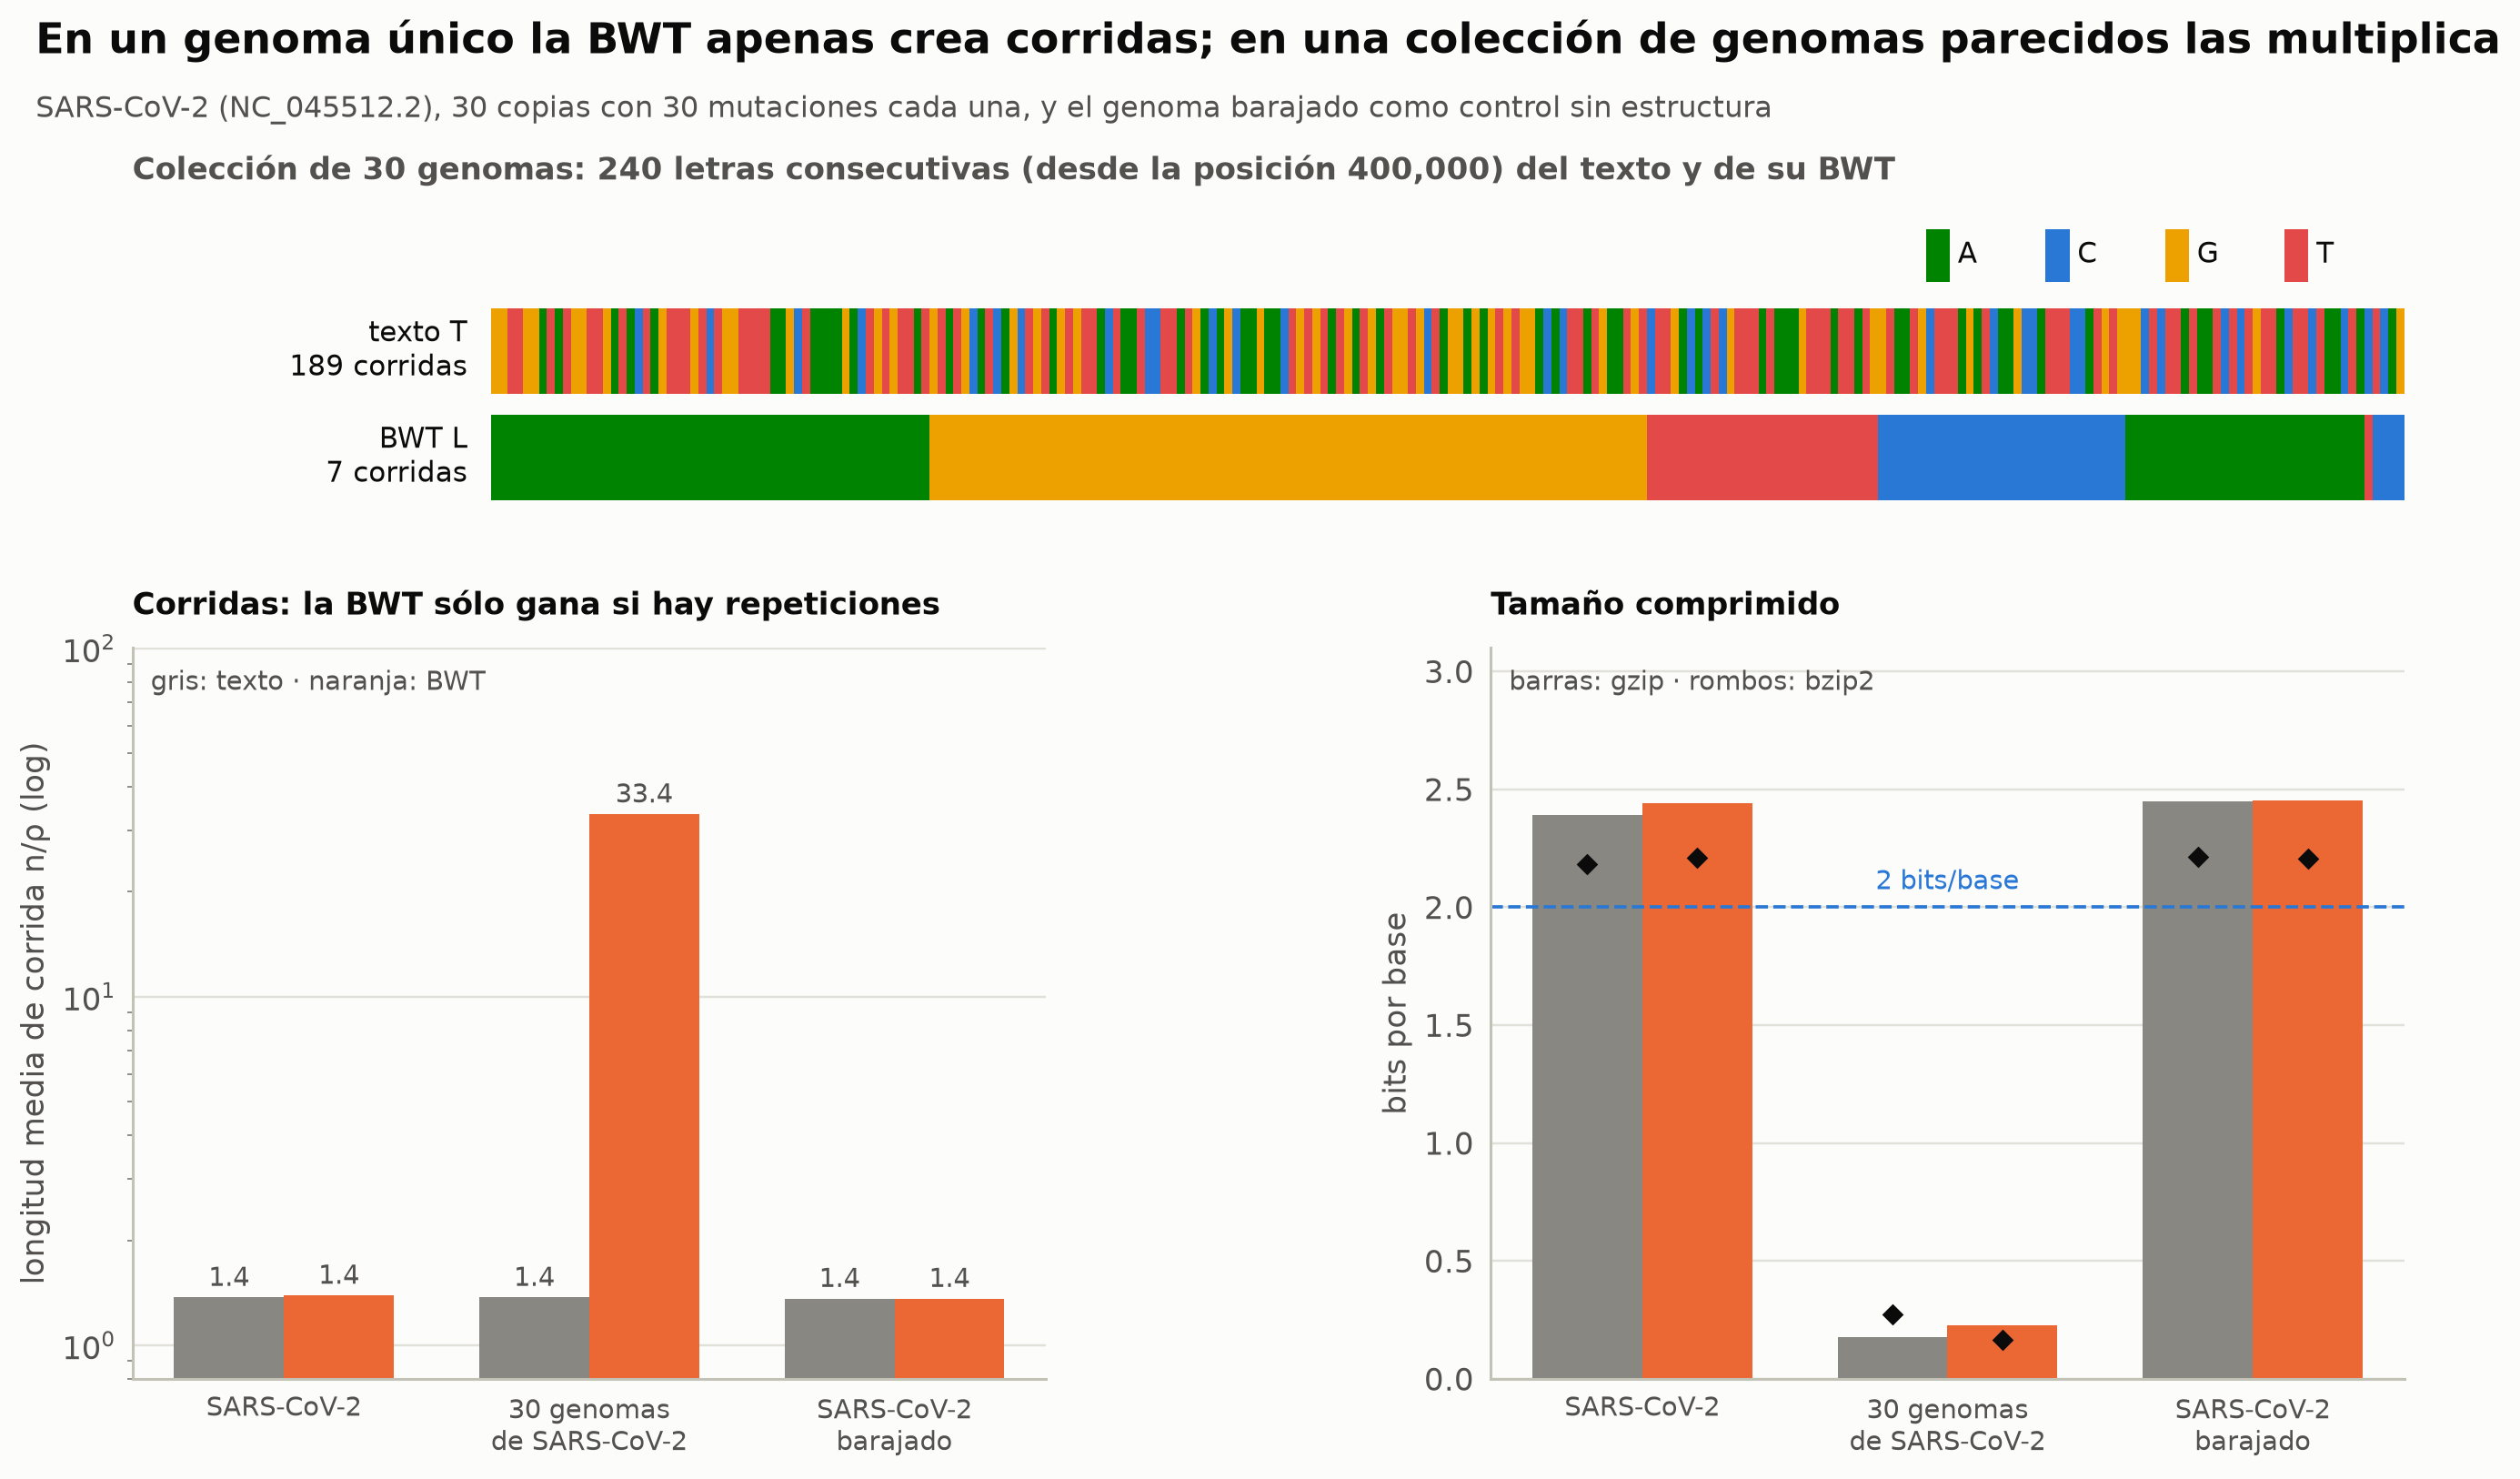

In [12]:
fig = plt.figure(figsize=(12, 6.6))
gs = fig.add_gridspec(2, 2, height_ratios=[0.55, 1.35], hspace=0.12, wspace=0.28)
ax_s = fig.add_subplot(gs[0, :])
W = 240
T_coll = COLLECTION + "$"
off = 400_000
for y, (lab, s) in enumerate([("texto T", T_coll[off:off + W]), ("BWT L", L_COLL[off:off + W])]):
    for k, ch in enumerate(s):
        ax_s.add_patch(Rectangle((k, 1 - y), 1, 0.8, fc=ALPHA_COLORS.get(ch, ec.MUTED), ec="none"))
    ax_s.text(-3, 1 - y + 0.4, f"{lab}\n{n_runs(s)} corridas", ha="right", va="center", fontsize=10, color=ec.INK)
for k, ch in enumerate("ACGT"):
    ax_s.add_patch(Rectangle((W - 60 + 15 * k, 2.05), 3, 0.5, fc=ec.NUC_COLORS[ch], ec="none"))
    ax_s.text(W - 60 + 15 * k + 4, 2.3, ch, va="center", fontsize=10, color=ec.INK)
ax_s.set_xlim(-45, W); ax_s.set_ylim(-0.1, 2.7); ax_s.axis("off")
ax_s.set_title(f"Colección de 30 genomas: {W} letras consecutivas (desde la posición {off:,}) del texto y de su BWT",
               loc="left", fontsize=11, color=ec.INK_2)

ax_r = fig.add_subplot(gs[1, 0])
names = comp["cadena"].unique()
x = np.arange(len(names)); w = 0.36
for k, (form, col) in enumerate([("texto T", ec.MUTED), ("BWT L", ec.ORANGE)]):
    vals = comp[comp["forma"] == form].set_index("cadena").loc[names, "n/ρ"]
    ax_r.bar(x + (k - 0.5) * w, vals, w, color=col)
    for xi, v in zip(x, vals):
        ax_r.text(xi + (k - 0.5) * w, v * 1.08, f"{v:.1f}", ha="center", fontsize=9.5, color=ec.INK_2)
ax_r.set_yscale("log"); ax_r.set_ylim(0.8, comp["n/ρ"].max() * 3)
ax_r.set_xticks(x, [n.replace(" de SARS", "\nde SARS").replace(" barajado", "\nbarajado") for n in names], fontsize=9.5)
ax_r.set_ylabel("longitud media de corrida n/ρ (log)")
ax_r.text(0.02, 0.97, "gris: texto · naranja: BWT", transform=ax_r.transAxes, va="top", fontsize=9.5, color=ec.INK_2)
ax_r.set_title("Corridas: la BWT sólo gana si hay repeticiones", loc="left", fontsize=11)

ax_c = fig.add_subplot(gs[1, 1])
for k, (form, col) in enumerate([("texto T", ec.MUTED), ("BWT L", ec.ORANGE)]):
    sub = comp[comp["forma"] == form].set_index("cadena").loc[names]
    ax_c.bar(x + (k - 0.5) * w, sub["gzip (bits/base)"], w, color=col)
    ax_c.scatter(x + (k - 0.5) * w, sub["bzip2 (bits/base)"], marker="D", s=30, color=ec.INK, zorder=3)
ax_c.axhline(2, color=ec.BLUE, lw=1.2, ls="--")
ax_c.text(1, 2.05, "2 bits/base", ha="center", va="bottom", fontsize=9.5, color=ec.BLUE)
ax_c.set_ylim(0, 3.1)
ax_c.set_xticks(x, [n.replace(" de SARS", "\nde SARS").replace(" barajado", "\nbarajado") for n in names], fontsize=9.5)
ax_c.set_ylabel("bits por base")
ax_c.text(0.02, 0.97, "barras: gzip · rombos: bzip2", transform=ax_c.transAxes, va="top", fontsize=9.5, color=ec.INK_2)
ax_c.set_title("Tamaño comprimido", loc="left", fontsize=11)
ec.fig_title(fig, "En un genoma único la BWT apenas crea corridas; en una colección de genomas parecidos las multiplica",
             "SARS-CoV-2 (NC_045512.2), 30 copias con 30 mutaciones cada una, y el genoma barajado como control sin estructura")
plt.show()

> 🔎 **Qué observamos.**
> * En **un solo genoma de SARS-CoV-2** la BWT casi no cambia nada: la longitud media de corrida pasa de ~1.37 a
>   ~1.39 letras, y gzip y bzip2 no bajan de ~2.2–2.4 bits por base, **peor** que guardar cada base en 2 bits. Un genoma
>   pequeño y poco repetitivo es casi incompresible: cada base aporta cerca de 2 bits de información nueva.
> * En la **colección de 30 genomas** la BWT convierte ~650 000 corridas en ~27 000: la corrida media pasa de ~1.4 a
>   más de 30 letras. La franja de colores lo muestra: el texto es un arcoíris y la BWT, bloques lisos. Cada contexto
>   (lo que sigue a una letra) aparece 30 veces, casi siempre precedido por la misma letra, y la BWT pone esas 30
>   letras **juntas**.
> * El texto **barajado** es el control: sin contexto no hay nada que agrupar, y $T$ y $L$ tienen las mismas corridas.
> * gzip también comprime muy bien la colección (sus copias caben en su ventana de 32 kb), así que la BWT no es "el
>   mejor compresor". Su verdadero mérito es otro: $L$ se puede comprimir **y a la vez** usar para **buscar** sin
>   descomprimir, como veremos. Por eso los índices de pangenomas modernos (colecciones de miles de genomas humanos o
>   bacterianos) se miden por su número de corridas $\rho$, no por $n$.

> ✅ **Compruebe su comprensión.** ¿Cuál es la BWT de `AAAA$`? ¿Y cuántas corridas tiene? (Respuesta: las rotaciones
> ordenadas son `$AAAA`, `A$AAA`, `AA$AA`, `AAA$A`, `AAAA$`; $L$ = `AAAA$`, con 2 corridas.)

## 6. La propiedad LF (*last-to-first*)

Esta es la idea que convierte a la BWT de un truco de compresión en un índice. Vale la pena ir despacio.

### Numerar cada letra según su aparición en el texto

Pongamos un subíndice a cada letra de `BANANA$` según el orden en que aparece **en el texto**:
$\texttt{B}\ \texttt{A}_1\ \texttt{N}_1\ \texttt{A}_2\ \texttt{N}_2\ \texttt{A}_3\ \texttt{\$}$. Ahora marquemos, en la matriz
ordenada, de qué letra del texto proviene cada casilla de $F$ y de $L$:

| fila $r$ | rotación | $F$ | $L$ |
|---|---|---|---|
| 0 | `$BANANA` | $\texttt{\$}$ | $\texttt{A}_3$ |
| 1 | `A$BANAN` | $\texttt{A}_3$ | $\texttt{N}_2$ |
| 2 | `ANA$BAN` | $\texttt{A}_2$ | $\texttt{N}_1$ |
| 3 | `ANANA$B` | $\texttt{A}_1$ | $\texttt{B}$ |
| 4 | `BANANA$` | $\texttt{B}$ | $\texttt{\$}$ |
| 5 | `NA$BANA` | $\texttt{N}_2$ | $\texttt{A}_2$ |
| 6 | `NANA$BA` | $\texttt{N}_1$ | $\texttt{A}_1$ |

Lea sólo las `A`. En $F$ aparecen en el orden $\texttt{A}_3, \texttt{A}_2, \texttt{A}_1$; en $L$, **en el mismo orden**:
$\texttt{A}_3, \texttt{A}_2, \texttt{A}_1$. Con las `N` ocurre lo mismo: $\texttt{N}_2, \texttt{N}_1$ en ambas columnas.

> **Propiedad LF (orden de las apariciones).** La $j$-ésima aparición de una letra $c$ en la columna $L$ y la
> $j$-ésima aparición de $c$ en la columna $F$ corresponden a la **misma posición** del texto $T$.

### ¿Por qué es cierto?

Tome las filas que **empiezan** por `A` (filas 1, 2, 3). Todas empiezan igual, así que su orden lo decide **lo que
viene después** de la `A`: `$BANAN` < `NA$BAN` < `NANA$B`. Ahora tome las filas que **terminan** en `A` (filas 0,
5, 6). Si a cada una le pasamos la última letra al principio (una rotación más), obtenemos exactamente las filas
que empiezan por esas mismas `A`, y lo que viene después de la `A` es justamente la parte de la fila que ya estaba
ordenada. Mover la `A` del final al principio **no altera el orden relativo** de esas filas. Por eso las `A` de $L$ y
las de $F$ desfilan en el mismo orden, como una fila de alumnos que sale de un aula y entra en otra sin adelantarse.

### La fórmula

Si la fila $r$ termina en la letra $c = L[r]$, ¿en qué fila de $F$ está esa misma letra? En $F$ las letras están
ordenadas, así que las $c$ ocupan un bloque que empieza después de todas las letras menores que $c$. Dentro del
bloque, nuestra $c$ ocupa el lugar que le corresponde según cuántas $c$ la preceden en $L$. Necesitamos dos tablas,

$$
C[c] = \#\{\, i : T[i] < c \,\}, \qquad \mathrm{Occ}(c, r) = \#\{\, i < r : L[i] = c \,\},
$$

y con ellas

$$
\boxed{\;\mathrm{LF}(r) = C\big[L[r]\big] + \mathrm{Occ}\big(L[r],\ r\big)\;}
$$

| Símbolo | Significado | En `BANANA$` |
|---|---|---|
| $C[c]$ | número de letras del texto **estrictamente menores** que $c$ = fila donde empieza el bloque de $c$ en $F$ | $C[\$]=0,\ C[A]=1,\ C[B]=4,\ C[N]=5$ |
| $\mathrm{Occ}(c, r)$ | número de veces que aparece $c$ en las primeras $r$ filas de $L$, $L[0..r-1]$ (**antes** de la fila $r$): el **rango** de $L[r]$ entre sus iguales | $\mathrm{Occ}(A, 5) = 1$ |
| $\mathrm{LF}(r)$ | fila de $M$ cuyo primer carácter es la misma letra del texto que $L[r]$; equivale a retroceder una posición en $T$ | $\mathrm{LF}(5) = 2$ |

**Ejemplo a mano.** Fila 5 de `BANANA$`: $L[5] = $ `A`. Antes de la fila 5, $L[0..4] = $ `ANNB$` contiene una `A`,
así que $\mathrm{Occ}(A, 5) = 1$. Entonces $\mathrm{LF}(5) = C[A] + 1 = 1 + 1 = 2$. En la tabla, $L[5] = \texttt{A}_2$ y
$F[2] = \texttt{A}_2$. ✔

Hay una consecuencia enorme: la fila $\mathrm{LF}(r)$ es la rotación de la fila $r$ **desplazada una letra hacia atrás**
en el texto. Dicho de otro modo, si la fila $r$ corresponde al sufijo que empieza en $\mathrm{SA}[r]$, la fila
$\mathrm{LF}(r)$ corresponde al sufijo que empieza en $\mathrm{SA}[r] - 1$. **$\mathrm{LF}$ nos permite caminar hacia
atrás por el texto usando sólo la columna $L$.**

In [13]:
def build_C(L):
    """C[c] = número de letras de L (= del texto) menores que c."""
    C, total = {}, 0
    for c in sorted(set(L)):
        C[c] = total
        total += L.count(c)
    return C

def occ_naive(L, c, r):
    """Occ(c, r): apariciones de c en L[0..r-1] (las primeras r filas). Versión directa, O(r)."""
    return L[:r].count(c)

def LF(L, C, r):
    c = L[r]
    return C[c] + occ_naive(L, c, r)

C_ban = build_C(L_ban)
print("C =", C_ban)
for i in range(len(L_ban)):
    j = LF(L_ban, C_ban, i)
    print(f"  fila r = {i}: L = {L_ban[i]} → LF = {j}   (SA[{i}] = {SA_BAN[i]}, SA[{j}] = {SA_BAN[j]} = SA[{i}] − 1 mod 7)")
    assert SA_BAN[j] == (SA_BAN[i] - 1) % len(T_BAN)

C = {'$': 0, 'A': 1, 'B': 4, 'N': 5}
  fila r = 0: L = A → LF = 1   (SA[0] = 6, SA[1] = 5 = SA[0] − 1 mod 7)
  fila r = 1: L = N → LF = 5   (SA[1] = 5, SA[5] = 4 = SA[1] − 1 mod 7)
  fila r = 2: L = N → LF = 6   (SA[2] = 3, SA[6] = 2 = SA[2] − 1 mod 7)
  fila r = 3: L = B → LF = 4   (SA[3] = 1, SA[4] = 0 = SA[3] − 1 mod 7)
  fila r = 4: L = $ → LF = 0   (SA[4] = 0, SA[0] = 6 = SA[4] − 1 mod 7)
  fila r = 5: L = A → LF = 2   (SA[5] = 4, SA[2] = 3 = SA[5] − 1 mod 7)
  fila r = 6: L = A → LF = 3   (SA[6] = 2, SA[3] = 1 = SA[6] − 1 mod 7)


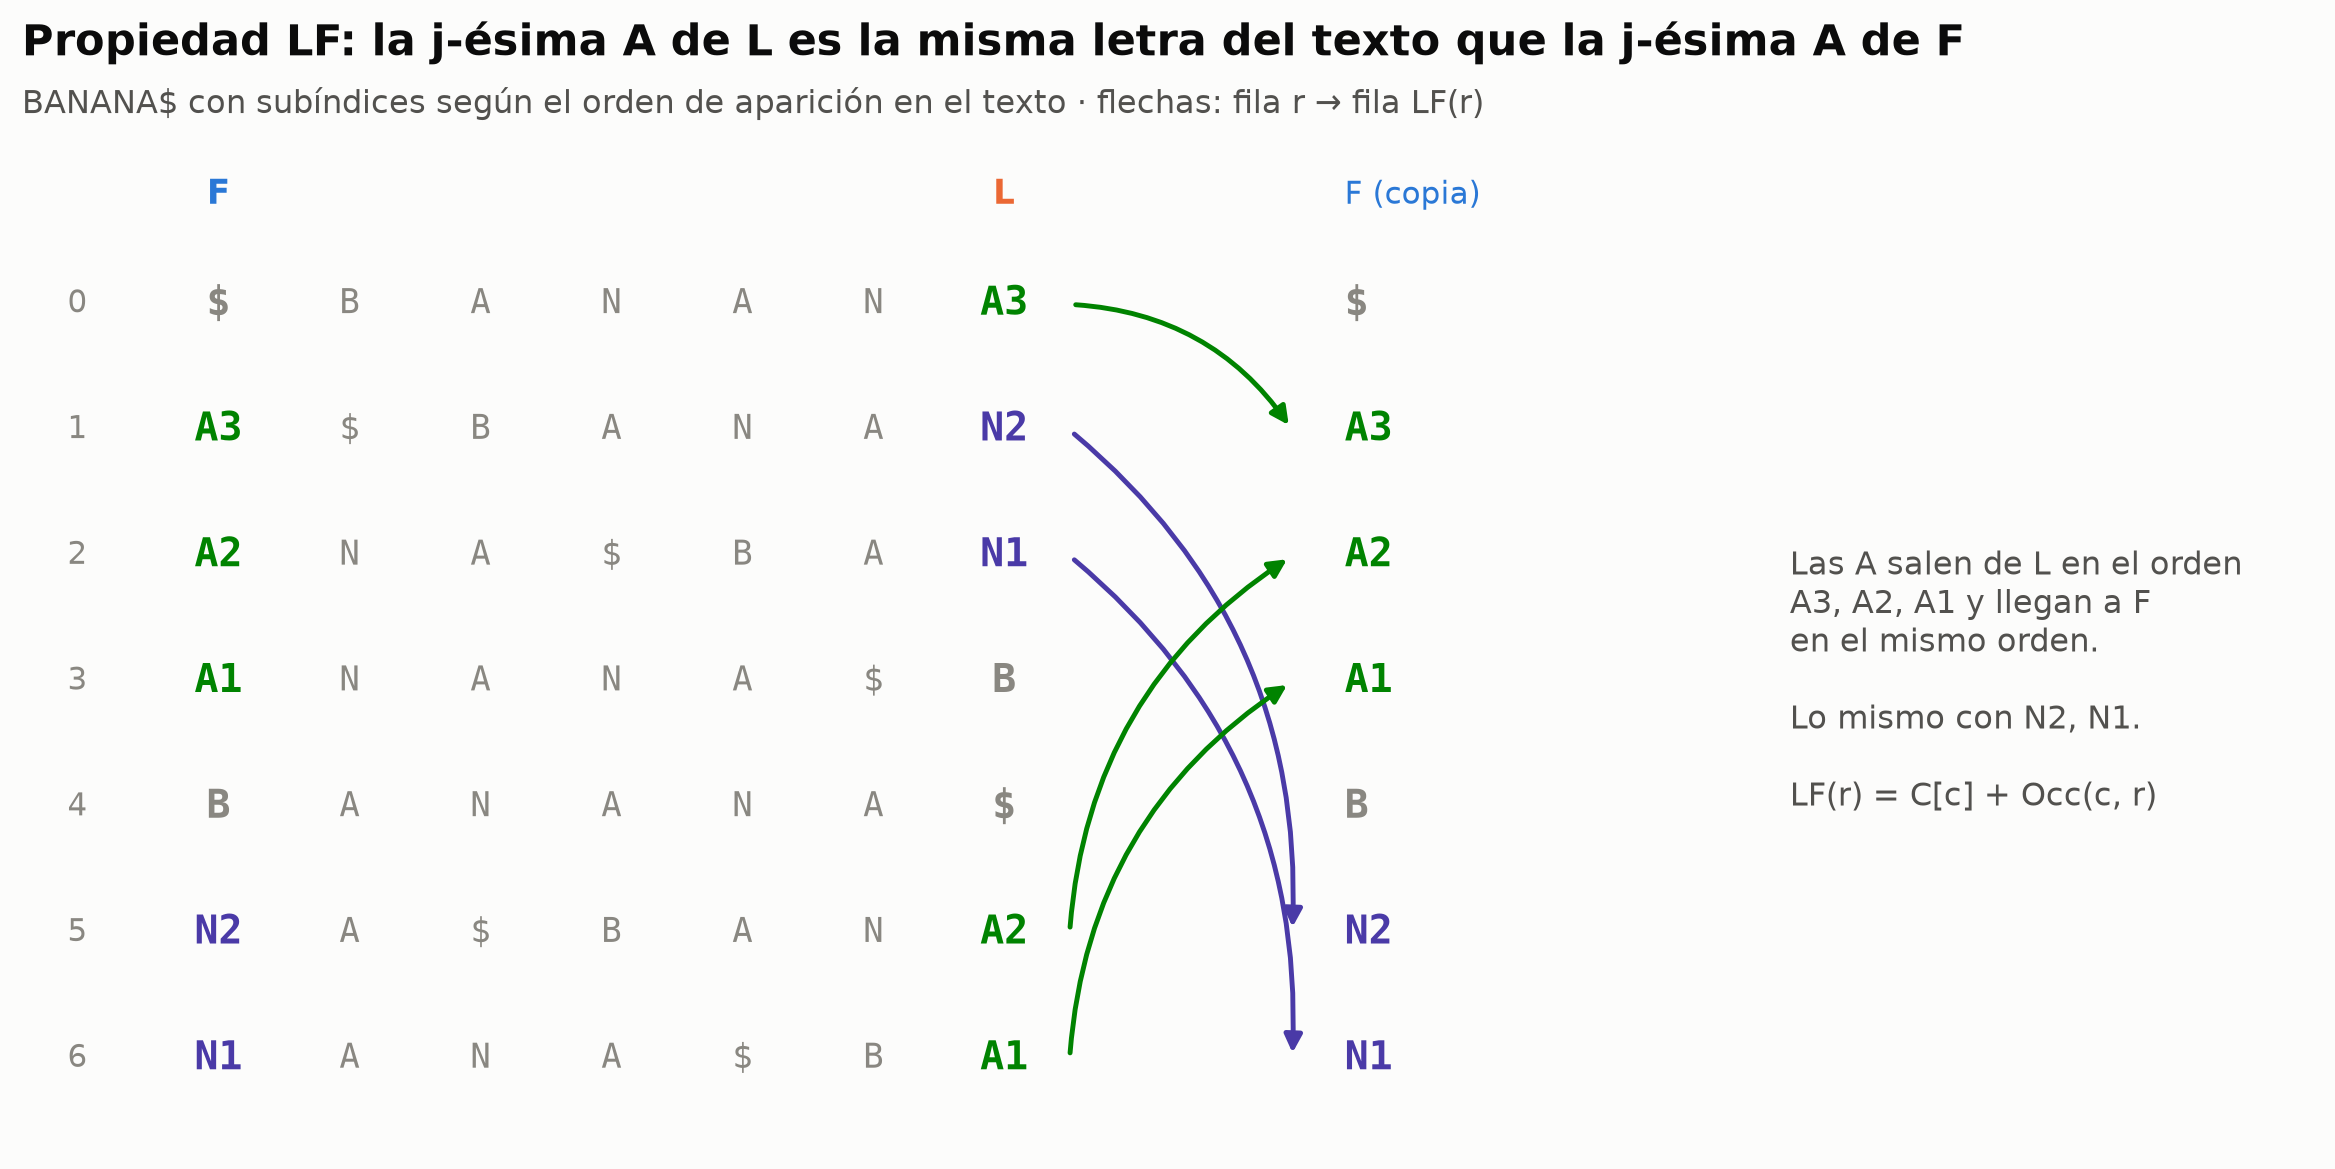

In [14]:
def subscripted(text):
    """Etiqueta cada letra con su número de aparición en el texto: A1, N1, A2…"""
    count, labels = {}, []
    for ch in text:
        count[ch] = count.get(ch, 0) + 1
        labels.append(ch if ch in "$B" else f"{ch}{count[ch]}")
    return labels

lab_ban = subscripted(T_BAN)
F_lab = [lab_ban[j] for j in SA_BAN]
L_lab = [lab_ban[(j - 1) % len(T_BAN)] for j in SA_BAN]
fig, ax = plt.subplots(figsize=(10.5, 5.2))
n_b = len(T_BAN)
col_of = {"A": ec.GREEN, "N": ec.VIOLET, "B": ec.MUTED, "$": ec.MUTED}
xF, xL = 0, 6
for i in range(n_b):
    y = n_b - 1 - i
    rot = M_ban[i]
    for k, ch in enumerate(rot):
        x = xF + k
        lab = F_lab[i] if k == 0 else (L_lab[i] if k == n_b - 1 else ch)
        bold = k in (0, n_b - 1)
        ax.text(x, y, lab if bold else ch, ha="center", va="center", fontsize=13 if bold else 11,
                family="monospace", color=col_of[ch] if bold else ec.MUTED, fontweight="bold" if bold else "normal")
    ax.text(-1, y, str(i), ha="right", va="center", fontsize=10, color=ec.MUTED)
for i in range(n_b):
    j = LF(L_ban, C_ban, i)
    ch = L_ban[i]
    if ch in "AN":
        ax.add_patch(FancyArrowPatch((xL + 0.5, n_b - 1 - i), (xF + 8.2 + 0.0, n_b - 1 - j), arrowstyle="-|>",
                                     mutation_scale=12, lw=1.6, color=col_of[ch], connectionstyle="arc3,rad=-0.25"))
for i in range(n_b):
    y = n_b - 1 - i
    ax.text(8.6, y, F_lab[i], ha="left", va="center", fontsize=13, family="monospace", fontweight="bold",
            color=col_of[M_ban[i][0]])
ax.text(8.6, n_b - 0.2, "F (copia)", fontsize=10, color=ec.BLUE)
ax.text(xF, n_b - 0.2, "F", ha="center", fontsize=11, color=ec.BLUE, fontweight="bold")
ax.text(xL, n_b - 0.2, "L", ha="center", fontsize=11, color=ec.ORANGE, fontweight="bold")
ax.text(12, 3.0, "Las A salen de L en el orden\nA3, A2, A1 y llegan a F\nen el mismo orden.\n\n"
        "Lo mismo con N2, N1.\n\nLF(r) = C[c] + Occ(c, r)", fontsize=10.5, color=ec.INK_2, va="center")
ax.set_xlim(-1.5, 16); ax.set_ylim(-0.7, n_b + 0.3); ax.axis("off")
ec.title(ax, "Propiedad LF: la j-ésima A de L es la misma letra del texto que la j-ésima A de F",
         "BANANA$ con subíndices según el orden de aparición en el texto · flechas: fila r → fila LF(r)")
plt.show()

> 🔎 **Qué observamos.** Las flechas verdes (letras `A`) y violetas (letras `N`) **nunca se cruzan** entre sí: salen
> de $L$ y llegan a $F$ respetando el orden. Esa es la propiedad LF en una imagen. Además, la salida del código
> confirma que $\mathrm{SA}[\mathrm{LF}(r)] = \mathrm{SA}[r] - 1$: cada salto LF retrocede exactamente una posición en el texto.

> ✅ **Compruebe su comprensión.** En `GATTACAGATTACA$` ($L$ = `ACTTCGGAAA$TTAA`, $C[A]=1, C[C]=7, C[G]=9, C[T]=11$),
> calcule $\mathrm{LF}(13)$. (Respuesta: $L[13] = $ `A`; en $L[0..12] = $ `ACTTCGGAAA$TT` hay 4 `A`, así que
> $\mathrm{LF}(13) = 1 + 4 = 5$. Compruébelo en la figura interactiva de la sección 4: la fila 13 indica "LF→5", y
> $\mathrm{SA}[5] = 8 = \mathrm{SA}[13] - 1$.)

## 7. Invertir la BWT paso a paso

Si la BWT sirve para comprimir, tiene que poder **deshacerse**: a partir de $L$ sola hay que recuperar $T$. Con la
propiedad LF es sorprendentemente fácil. Sabemos dos cosas:

* La fila 0 de $M$ empieza por `$` (es la menor rotación). Su última letra, $L[0]$, es por tanto la letra que va
  **justo antes** del `$`: la **última** letra del texto.
* Desde cualquier fila, $\mathrm{LF}$ salta a la fila que empieza con esa letra; su última letra es la **anterior** en el texto.

Entonces reconstruimos el texto **de derecha a izquierda**:

$$
r_0 = 0, \qquad T[n-2-k] = L[r_k], \qquad r_{k+1} = \mathrm{LF}(r_k) = C[L[r_k]] + \mathrm{Occ}(L[r_k], r_k),
\qquad k = 0, 1, \dots, n-2
$$

| Símbolo | Significado |
|---|---|
| $r_k$ | fila de $M$ en la que estamos tras $k$ pasos |
| $L[r_k]$ | letra que recuperamos en el paso $k$ (se escribe a la izquierda de lo ya reconstruido) |
| $n - 1$ | número de pasos: todas las letras menos el `$` |

**Ejemplo a mano con $L$ = `ANNB$AA`** ($C[\$]=0, C[A]=1, C[B]=4, C[N]=5$):

| paso $k$ | fila $r_k$ | $L[r_k]$ | $\mathrm{Occ}(L[r_k], r_k)$ | texto reconstruido | $r_{k+1}$ |
|---|---|---|---|---|---|
| 0 | 0 | `A` | 0 | `A$` | $1 + 0 = 1$ |
| 1 | 1 | `N` | 0 | `NA$` | $5 + 0 = 5$ |
| 2 | 5 | `A` | 1 | `ANA$` | $1 + 1 = 2$ |
| 3 | 2 | `N` | 1 | `NANA$` | $5 + 1 = 6$ |
| 4 | 6 | `A` | 2 | `ANANA$` | $1 + 2 = 3$ |
| 5 | 3 | `B` | 0 | `BANANA$` | $4 + 0 = 4$ |

Seis pasos y `BANANA$` reaparece. Para no recontar $\mathrm{Occ}$ en cada paso, se calcula de una vez el rango de
cada letra de $L$ en una sola pasada (la función `lf_table` de la sección 4).

In [15]:
def inverse_bwt(L):
    """Reconstruye T a partir de su BWT caminando con LF desde la fila 0 (la que empieza por '$')."""
    C, ranks, lf = lf_table(L)
    out, i = ["$"], 0
    for _ in range(len(L) - 1):
        out.append(L[i])
        i = lf[i]
    return "".join(reversed(out))

print(inverse_bwt("ANNB$AA"))
print(inverse_bwt(L_DNA))
L_SARS = bwt_from_sa(SARS + "$", SA_SARS)
t0 = time.perf_counter()
ok = inverse_bwt(L_SARS) == SARS + "$"
print(f"SARS-CoV-2 reconstruido desde su BWT: {ok} ({time.perf_counter() - t0:.2f} s)")

BANANA$
GATTACAGATTACA$
SARS-CoV-2 reconstruido desde su BWT: True (0.01 s)


La animación sigue el mismo procedimiento con `GATTACAGATTACA$`. A la izquierda están las columnas $F$ y $L$ (en
medio, la parte de cada rotación que **no** necesitamos guardar, en gris). En cada cuadro se resalta la fila actual,
la flecha LF indica a qué fila saltamos, y abajo crece el texto reconstruido, de derecha a izquierda.

> 🤔 **Antes de ejecutar, prediga:** ¿cuántos saltos hacen falta para recuperar las 14 letras del texto? ¿Visita
> alguna fila dos veces?

![Inversión de la BWT de GATTACAGATTACA$: desde la fila del $, cada salto LF recupera la letra anterior del texto; en 14 saltos el texto reaparece completo](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-07-mapeo/7.1_inversion_bwt.gif)

*Inversión de la BWT de GATTACAGATTACA$: desde la fila del $, cada salto LF recupera la letra anterior del texto; en 14 saltos el texto reaparece completo*

In [16]:
rows_d = rotations_sorted(T_DNA)
C_d, ranks_d, lf_d = lf_table(L_DNA)
n_d = len(T_DNA)
path = [0]
for _ in range(n_d - 1):
    path.append(lf_d[path[-1]])

fig = plt.figure(figsize=(11, 7.4), layout="none")
fig.text(0.02, 0.975, "Con sólo la columna L y la función LF, el texto se reconstruye de derecha a izquierda",
         fontsize=14.5, fontweight="bold", color=ec.INK, va="top")
fig.text(0.02, 0.935, (f"BWT L = {L_DNA} · C: " + ", ".join(f"{c}={v}" for c, v in C_d.items()) +
          " · LF(r) = C[L[r]] + Occ(L[r], r)").replace("$", r"\$"),     # '\$': que matplotlib no lo lea como fórmula
         fontsize=10.5, color=ec.INK_2, va="top")
ax = fig.add_axes([0.02, 0.2, 0.62, 0.7]); ax.axis("off")
ax_t = fig.add_axes([0.02, 0.02, 0.96, 0.13]); ax_t.axis("off")
ax.set_xlim(-2, n_d + 1); ax.set_ylim(-0.8, n_d + 0.2)
ax_t.set_xlim(-0.5, n_d + 0.5); ax_t.set_ylim(0, 1.6)
for i, row in enumerate(rows_d):
    y = n_d - 1 - i
    ax.text(-0.9, y, str(i), ha="right", va="center", fontsize=9.5, color=ec.MUTED)
    for k, ch in enumerate(row):
        edge = k in (0, n_d - 1)
        ax.text(k, y, ch, ha="center", va="center", fontsize=11.5 if edge else 9, family="monospace",
                color=ALPHA_COLORS.get(ch, ec.INK) if edge else ec.GRID, fontweight="bold" if edge else "normal")
ax.text(0, n_d - 0.1, "F", ha="center", fontsize=12, fontweight="bold", color=ec.BLUE)
ax.text(n_d - 1, n_d - 0.1, "L", ha="center", fontsize=12, fontweight="bold", color=ec.ORANGE)
hl = ax.add_patch(Rectangle((-0.5, 0), n_d, 0.9, fc=ec.ORANGE, alpha=0.18, ec="none"))
hl_to = ax.add_patch(Rectangle((-0.5, 0), 1, 0.9, fc=ec.BLUE, alpha=0.25, ec="none"))
status = fig.text(0.67, 0.72, "", fontsize=11, color=ec.INK, va="top", family="monospace")
boxes = []
for k in range(n_d):
    boxes.append(ax_t.text(k, 0.7, "", ha="center", va="center", fontsize=17, family="monospace", fontweight="bold",
                           bbox=dict(boxstyle="square,pad=0.25", fc="white", ec=ec.GRID)))
ax_t.text(-0.4, 1.45, "texto reconstruido (se escribe de derecha a izquierda):", fontsize=10, color=ec.INK_2, va="center")
arrow = [None]
n_frames = len(path) + 3

def update(f):
    step = min(f, len(path) - 1)
    i = path[step]
    y = n_d - 1 - i
    hl.set_y(y - 0.45)
    if arrow[0] is not None:
        arrow[0].remove(); arrow[0] = None
    rec = "$"
    for k in range(step):
        rec = L_DNA[path[k]] + rec
    for k in range(n_d):
        pos = n_d - len(rec) + (k - (n_d - len(rec)))
        ch = rec[k - (n_d - len(rec))] if k >= n_d - len(rec) else ""
        boxes[k].set_text(ch)
        boxes[k].set_color(ALPHA_COLORS.get(ch, ec.INK))
    if step < len(path) - 1:
        j = path[step + 1]
        c = L_DNA[i]
        hl_to.set_visible(True); hl_to.set_y(n_d - 1 - j - 0.45)
        arrow[0] = ax.add_patch(FancyArrowPatch((n_d - 0.7, y), (0.35, n_d - 1 - j), arrowstyle="-|>",
                                                mutation_scale=14, lw=1.8, color=ec.ORANGE,
                                                connectionstyle="arc3,rad=0.25"))
        status.set_text(f"paso {step + 1:>2} de {n_d - 1}\n\nfila r = {i}\nL[{i}] = {c}\n"
                        f"Occ({c}, {i}) = {ranks_d[i]}\nLF({i}) = {C_d[c]} + {ranks_d[i]} = {j}\n\n"
                        f"nueva letra: {c}\n(a la izquierda)")
    else:
        hl_to.set_visible(False)
        status.set_text(f"¡listo!\n\n{rec}\n\n{n_d - 1} saltos LF,\ncada fila visitada\nuna sola vez")
    return []

fig.canvas.draw()
warnings.filterwarnings("ignore", message="There are no gridspecs")   # ejes colocados a mano: aviso inofensivo
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=n_frames, interval=900, name="7.1_inversion_bwt")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Cada salto LF lleva a una fila **distinta** y el recorrido visita las 15 filas exactamente una
> vez: el camino LF es una única vuelta al anillo del texto, recorrida hacia atrás. Las flechas saltan de forma
> aparentemente caótica por la matriz, pero cada una retrocede **una sola posición** en el texto. Guardando $L$ (y
> las pequeñas tablas $C$ y rangos) tenemos el texto entero: la BWT no pierde información.

## 8. El índice FM: tablas $C$ y $\mathrm{Occ}$ y la búsqueda hacia atrás

### Las dos tablas

Ferragina y Manzini (en un congreso de 2000, con la versión extendida en el *Journal of the ACM* en 2005) observaron
que con $L$ y dos tablas pequeñas se puede **buscar** un patrón sin reconstruir el texto:

* $C[c]$: cuántas letras del texto son **menores** que $c$. Un número por letra del alfabeto (5 números para ADN).
* $\mathrm{Occ}(c, r)$: cuántas veces aparece $c$ en las primeras $r$ filas de $L$, $L[0..r-1]$. Conceptualmente, una
  tabla de $\sigma \times (n+1)$ con los conteos acumulados de cada letra (la fila $r = n$ cuenta toda la columna).

### Búsqueda hacia atrás: la intuición

Piense en cómo buscaría en un diccionario **al revés**, uno ordenado por la última letra de cada palabra: primero
se queda con las que terminan en `A`, luego, entre ellas, con las que terminan en `CA`, y así sucesivamente. La
búsqueda hacia atrás hace eso mismo sobre la matriz $M$: construye el bloque de filas que empiezan por el patrón
**leyendo el patrón de derecha a izquierda**, una letra por paso. Como en la sección 3, el bloque es un intervalo
**semiabierto** $[sp, ep)$: contiene las filas $sp, sp + 1, \dots, ep - 1$.

1. Antes de leer nada, el bloque es la matriz entera: $[0, n)$ (todas las filas empiezan por la cadena vacía).
2. Supongamos que $[sp, ep)$ es el bloque de filas que empiezan por una cadena $W$ (el sufijo del patrón ya leído).
   Queremos el bloque $[sp', ep')$ de las filas que empiezan por $cW$, con una letra $c$ más a la izquierda.
3. Las filas que empiezan por $cW$ son exactamente las que se obtienen **aplicando LF** a las filas del bloque
   $[sp, ep)$ que **terminan** en $c$ (la letra anterior a $W$ en el texto es $c$).
4. Gracias a la propiedad LF, esas filas llegan a $F$ **en orden y contiguas**, dentro del bloque de $c$ que empieza
   en $C[c]$. Las $c$ de $L$ situadas **antes** de $sp$ son $\mathrm{Occ}(c, sp)$: por eso el nuevo bloque empieza en
   $C[c] + \mathrm{Occ}(c, sp)$; las situadas antes de $ep$ son $\mathrm{Occ}(c, ep)$, y el bloque termina **justo
   antes** de $C[c] + \mathrm{Occ}(c, ep)$. No hace falta mirar el bloque letra por letra.

$$
\boxed{\;
sp' = C[c] + \mathrm{Occ}(c,\ sp), \qquad
ep' = C[c] + \mathrm{Occ}(c,\ ep)
\;}
$$

Empezando con $[sp, ep) = [0, n)$ y aplicando la regla para $c = p_m, p_{m-1}, \dots, p_1$, el patrón aparece en el
texto exactamente $ep - sp$ veces; si en algún paso $sp' \ge ep'$, el patrón **no aparece** y la búsqueda se detiene.
(La convención semiabierta es la razón de que las dos ecuaciones sean **idénticas**: con un intervalo cerrado habría
que escribir $\mathrm{Occ}(c, ep + 1) - 1$ en la segunda.)

| Símbolo | Significado |
|---|---|
| $P = p_1 p_2 \cdots p_m$ | patrón de longitud $m$, que se lee de $p_m$ hacia $p_1$ |
| $W$ | sufijo del patrón ya procesado (al principio, la cadena vacía) |
| $c$ | siguiente letra del patrón, leída de derecha a izquierda |
| $[sp, ep)$ | intervalo semiabierto de filas de $M$ (o del arreglo de sufijos) que empiezan por $W$ |
| $[sp', ep')$ | intervalo de las filas que empiezan por $cW$ |
| $\mathrm{Occ}(c, sp)$ | letras $c$ de $L$ **antes** del bloque |
| $\mathrm{Occ}(c, ep)$ | letras $c$ de $L$ **antes del final** del bloque (es decir, hasta la fila $ep - 1$ inclusive) |
| $ep - sp$ | número de apariciones del patrón en el texto |

Cada paso cuesta **dos consultas** a $\mathrm{Occ}$, independientemente de $n$: la búsqueda completa cuesta $O(m)$.
Buscar una lectura de 150 bases en el genoma humano cuesta 300 consultas, **lo mismo** que buscarla en el genoma de un
virus.

In [17]:
C_dna = build_C(L_DNA)
symbols_dna = sorted(C_dna)
occ_full = pd.DataFrame({c: [occ_naive(L_DNA, c, r) for r in range(len(L_DNA) + 1)] for c in symbols_dna})
occ_full.index.name = "r"
print("C =", C_dna)
print("L =", " ".join(L_DNA))
occ_full.T.style.set_caption("Occ(c, r): apariciones de c en L[0..r-1] para GATTACAGATTACA$ "
                             "(columnas: r = 0…n; la última, r = n = 15, cuenta toda la columna L)")

C = {'$': 0, 'A': 1, 'C': 7, 'G': 9, 'T': 11}
L = A C T T C G G A A A $ T T A A


r,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
$,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1
A,0,1,1,1,1,1,1,1,2,3,4,4,4,4,5,6
C,0,0,1,1,1,2,2,2,2,2,2,2,2,2,2,2
G,0,0,0,0,0,0,1,2,2,2,2,2,2,2,2,2
T,0,0,0,1,2,2,2,2,2,2,2,2,3,4,4,4


### Ejemplo a mano: buscar `TTA` en `GATTACAGATTACA$`

Con $L$ = `ACTTCGGAAA$TTAA`, $C[\$]=0,\ C[A]=1,\ C[C]=7,\ C[G]=9,\ C[T]=11$ y la tabla $\mathrm{Occ}$ de arriba:

| paso | letra $c$ | ya leído $W$ | $sp'$ | $ep'$ | bloque | apariciones $ep - sp$ |
|---|---|---|---|---|---|---|
| 0 | — | (vacío) | 0 | $n = 15$ | $[0, 15)$ | 15 |
| 1 | `A` | `A` | $C[A] + \mathrm{Occ}(A, 0) = 1 + 0 = 1$ | $C[A] + \mathrm{Occ}(A, 15) = 1 + 6 = 7$ | $[1, 7)$ | 6 |
| 2 | `T` | `TA` | $C[T] + \mathrm{Occ}(T, 1) = 11 + 0 = 11$ | $C[T] + \mathrm{Occ}(T, 7) = 11 + 2 = 13$ | $[11, 13)$ | 2 |
| 3 | `T` | `TTA` | $C[T] + \mathrm{Occ}(T, 11) = 11 + 2 = 13$ | $C[T] + \mathrm{Occ}(T, 13) = 11 + 4 = 15$ | $[13, 15)$ | 2 |

`TTA` aparece $15 - 13 = $ **2 veces**, en las filas 13 y 14, que corresponden a $\mathrm{SA}[13] = 9$ y
$\mathrm{SA}[14] = 2$: el mismo bloque $[13, 15)$ que dio la búsqueda binaria de la sección 3, pero **sin comparar
ninguna cadena** y sin mirar el arreglo de sufijos hasta el final.

Un ejemplo que falla: `GATC`. Tras `C` el bloque es $[7, 9)$; con `T`: $sp' = 11 + \mathrm{Occ}(T, 7) = 11 + 2 = 13$ y
$ep' = 11 + \mathrm{Occ}(T, 9) = 11 + 2 = 13$. Como $sp' = ep'$, el bloque está vacío: `TC` no aparece en el texto y
la búsqueda termina tras sólo dos letras, sin mirar el texto.

In [18]:
def backward_search(L, C, pattern, occ=occ_naive, trace=False):
    """Intervalo semiabierto [sp, ep) de filas cuyas rotaciones empiezan por `pattern`
    (el patrón aparece ep - sp veces; vacío si sp >= ep).
    Con trace=True devuelve además la lista de pasos (letra, sp, ep)."""
    sp, ep = 0, len(L)                                   # [0, n): todas las filas
    steps = [("", sp, ep)]
    for c in reversed(pattern):                          # de derecha a izquierda
        if c not in C:
            sp, ep = 0, 0                                # letra ausente del texto: bloque vacío
        else:
            sp, ep = C[c] + occ(L, c, sp), C[c] + occ(L, c, ep)
        steps.append((c, sp, ep))
        if sp >= ep:
            break
    return ((sp, ep), steps) if trace else (sp, ep)

for p in ["TTA", "ACA", "GATTA", "GATC", "A"]:
    (sp, ep), steps = backward_search(L_DNA, C_dna, p, trace=True)
    hits = sorted(SA_DNA[sp:ep]) if sp < ep else []
    truth = [m.start() for m in re.finditer(f"(?={p})", T_DNA)]
    print(f"{p:6s} pasos {[f'{c}:[{s},{e})' for c, s, e in steps[1:]]} → {max(0, ep - sp)} apariciones en {hits}"
          f"  (re.finditer: {truth})")
    assert hits == truth

TTA    pasos ['A:[1,7)', 'T:[11,13)', 'T:[13,15)'] → 2 apariciones en [2, 9]  (re.finditer: [2, 9])
ACA    pasos ['A:[1,7)', 'C:[7,9)', 'A:[2,4)'] → 2 apariciones en [4, 11]  (re.finditer: [4, 11])
GATTA  pasos ['A:[1,7)', 'T:[11,13)', 'T:[13,15)', 'A:[5,7)', 'G:[9,11)'] → 2 apariciones en [0, 7]  (re.finditer: [0, 7])
GATC   pasos ['C:[7,9)', 'T:[13,13)'] → 0 apariciones en []  (re.finditer: [])
A      pasos ['A:[1,7)'] → 6 apariciones en [1, 4, 6, 8, 11, 13]  (re.finditer: [1, 4, 6, 8, 11, 13])


### Verificación cruzada con el ejemplo resuelto del libro: `TACATACAG$`

El capítulo 7 del libro del curso resuelve a mano todo el índice FM de un texto de juguete, $T = $ `TACATACAG$`:
su arreglo de sufijos, su BWT, las tablas $C$ y $\mathrm{Occ}$, la reconstrucción del texto con $\mathrm{LF}$ y la
búsqueda de `ACA`. Conviene que usted pueda pasar del libro al cuaderno y viceversa sin traducir nada, así que la
celda siguiente recalcula **cada cifra** del libro con las funciones de esta clase y comprueba con `assert` que
coinciden:

| objeto | valor en el libro |
|---|---|
| $\mathrm{SA}$ | $(9, 5, 1, 7, 3, 6, 2, 8, 4, 0)$ |
| $L$ / $F$ | `GTTCCAAAA$` / `$AAAACCGTT` |
| $C$ | $C[A]=1,\ C[C]=5,\ C[G]=7,\ C[T]=8$ |
| reconstrucción | $0 \xrightarrow{G} 7 \xrightarrow{A} 3 \xrightarrow{C} 5 \xrightarrow{A} 1 \xrightarrow{T} 8 \xrightarrow{A} 4 \xrightarrow{C} 6 \xrightarrow{A} 2 \xrightarrow{T} 9$ |
| `ACA` | $[0, 10) \to [1, 5) \to [5, 7) \to [1, 3)$: 2 apariciones, en $\mathrm{SA}[1] = 5$ y $\mathrm{SA}[2] = 1$ |
| `GAC` | tras `AC`, $[1, 3)$; con `G`, $sp' = ep' = 8$: no aparece |

> 🤔 **Antes de ejecutar, prediga:** en `TACATACAG` la cadena `ACA` aparece dos veces. ¿Qué **filas** de la matriz
> ocuparán esas dos apariciones? (Pista: las filas que empiezan por `A` son las 1 a 4, y `ACAG…` va antes que `ACAT…`.)

In [19]:
T_BOOK = "TACATACAG$"                                  # el ejemplo resuelto del capítulo 7 del libro
SA_BOOK = suffix_array_naive(T_BOOK)
L_BOOK = bwt_from_sa(T_BOOK, SA_BOOK)
F_BOOK = "".join(sorted(T_BOOK))
C_BOOK = build_C(L_BOOK)
print("SA =", tuple(SA_BOOK))
print(f"L = {L_BOOK} · F = {F_BOOK} · C = {C_BOOK}")
assert SA_BOOK == [9, 5, 1, 7, 3, 6, 2, 8, 4, 0]
assert L_BOOK == "GTTCCAAAA$" and F_BOOK == "$AAAACCGTT"
assert C_BOOK == {"$": 0, "A": 1, "C": 5, "G": 7, "T": 8}

# Tabla Occ(c, r) del libro, r = 0…10 (la fila 10 cuenta toda la columna L)
occ_book = pd.DataFrame({c: [occ_naive(L_BOOK, c, r) for r in range(len(L_BOOK) + 1)] for c in "ACGT"})
occ_book.insert(0, "L[r]", list(L_BOOK) + ["–"])
occ_book.index.name = "r"
print("\nTabla Occ(c, r):\n" + occ_book.to_string())
assert [tuple(x) for x in occ_book[list("ACGT")].values] == [
    (0, 0, 0, 0), (0, 0, 1, 0), (0, 0, 1, 1), (0, 0, 1, 2), (0, 1, 1, 2), (0, 2, 1, 2),
    (1, 2, 1, 2), (2, 2, 1, 2), (3, 2, 1, 2), (4, 2, 1, 2), (4, 2, 1, 2)]

# Reconstrucción del texto con LF, desde la fila 0 (la que empieza por '$')
path, letters, r = [0], "", 0
while L_BOOK[r] != "$":
    letters += L_BOOK[r]
    r = LF(L_BOOK, C_BOOK, r)
    path.append(r)
print("\nLF:", " ".join(f"{a} →{c}" for a, c in zip(path, letters)), path[-1],
      f"· letras {letters} → al revés {letters[::-1]}")
assert path == [0, 7, 3, 5, 1, 8, 4, 6, 2, 9] and letters[::-1] == "TACATACAG"

# Búsqueda hacia atrás de ACA y de GAC
for pat, expected in [("ACA", [(0, 10), (1, 5), (5, 7), (1, 3)]), ("GAC", [(0, 10), (5, 7), (1, 3), (8, 8)])]:
    (sp, ep), steps = backward_search(L_BOOK, C_BOOK, pat, trace=True)
    print(f"\n{pat}: " + " → ".join(f"[{s}, {e})" for _, s, e in steps)
          + f" · {max(0, ep - sp)} apariciones en {sorted(SA_BOOK[sp:ep])}")
    assert [(s, e) for _, s, e in steps] == expected
(sp, ep) = backward_search(L_BOOK, C_BOOK, "ACA")
print("\nComo imprime el programa del libro:", L_BOOK, sorted(SA_BOOK[sp:ep]))
assert (sp, ep) == (1, 3) and sorted(SA_BOOK[sp:ep]) == [1, 5]
print("✔ todas las cifras coinciden con el ejemplo resuelto del libro")

SA = (9, 5, 1, 7, 3, 6, 2, 8, 4, 0)
L = GTTCCAAAA$ · F = $AAAACCGTT · C = {'$': 0, 'A': 1, 'C': 5, 'G': 7, 'T': 8}

Tabla Occ(c, r):
   L[r]  A  C  G  T
r                  
0     G  0  0  0  0
1     T  0  0  1  0
2     T  0  0  1  1
3     C  0  0  1  2
4     C  0  1  1  2
5     A  0  2  1  2
6     A  1  2  1  2
7     A  2  2  1  2
8     A  3  2  1  2
9     $  4  2  1  2
10    –  4  2  1  2

LF: 0 →G 7 →A 3 →C 5 →A 1 →T 8 →A 4 →C 6 →A 2 →T 9 · letras GACATACAT → al revés TACATACAG

ACA: [0, 10) → [1, 5) → [5, 7) → [1, 3) · 2 apariciones en [1, 5]

GAC: [0, 10) → [5, 7) → [1, 3) → [8, 8) · 0 apariciones en []

Como imprime el programa del libro: GTTCCAAAA$ [1, 5]
✔ todas las cifras coinciden con el ejemplo resuelto del libro


> 🔎 **Qué observamos.** Las dos apariciones de `ACA` ocupan las filas 1 y 2, el bloque $[1, 3)$: la fila 1 es
> `ACAG$…` (posición 5) y la fila 2 es `ACATACAG$…` (posición 1). La búsqueda de `GAC` muestra el otro desenlace: el
> último paso deja $sp' = ep' = 8$, un bloque vacío, y sabemos que `GAC` no aparece **sin haber mirado el texto**.
> Observe también que el paso de `ACA` que lleva de `CA` a `ACA` sólo miró dos números de la tabla,
> $\mathrm{Occ}(A, 5) = 0$ y $\mathrm{Occ}(A, 7) = 2$.

### 🎬 El intervalo se encoge letra a letra

Ahora un texto real: las primeras 40 bases del genoma de SARS-CoV-2 (el extremo 5′), con su `$`. Buscamos el patrón
`AACCAAC`. A la izquierda de cada fila está su letra de $L$; a la derecha, el comienzo del sufijo. En cada paso
primero se marcan, **dentro** del bloque actual, las filas cuya letra $L$ es la siguiente letra del patrón (leído de
derecha a izquierda), y luego el bloque salta a su nuevo lugar con las ecuaciones de actualización.

> 🤔 **Antes de ejecutar, prediga:** ¿el tamaño del bloque puede **crecer** en algún paso? ¿Puede quedarse igual?

![Búsqueda hacia atrás de AACCAAC en las primeras 40 bases de SARS-CoV-2: el bloque [sp, ep) de filas se encoge (o se mantiene) con cada letra hasta quedar en las 2 apariciones](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-07-mapeo/7.1_backward_search.gif)

*Búsqueda hacia atrás de AACCAAC en las primeras 40 bases de SARS-CoV-2: el bloque [sp, ep) de filas se encoge (o se mantiene) con cada letra hasta quedar en las 2 apariciones*

In [20]:
T40 = SARS[:40] + "$"
SA40 = suffix_array_naive(T40)
L40 = bwt_from_sa(T40, SA40)
C40 = build_C(L40)
PAT = "AACCAAC"
(sp_end, ep_end), bs_steps = backward_search(L40, C40, PAT, trace=True)
n40 = len(T40)
SHOW = 22

fig = plt.figure(figsize=(11.5, 9.2), layout="none")
fig.text(0.02, 0.985, "La búsqueda hacia atrás encoge el bloque de filas con dos consultas a Occ por letra",
         fontsize=14.5, fontweight="bold", color=ec.INK, va="top")
fig.text(0.02, 0.955, f"Patrón {PAT} en las primeras 40 nt de SARS-CoV-2 · izquierda: letra L de cada fila · "
         "derecha: comienzo del sufijo (SA)", fontsize=10.5, color=ec.INK_2, va="top")
ax = fig.add_axes([0.02, 0.02, 0.6, 0.91]); ax.axis("off")
ax.set_xlim(-3.2, SHOW + 1); ax.set_ylim(-0.8, n40 + 0.3)
band = ax.add_patch(Rectangle((-1.6, 0), SHOW + 2.2, 1, fc=ec.SEQ_BLUE[1], ec=ec.BLUE, lw=1.2))
marks = [ax.add_patch(Rectangle((-1.45, n40 - 1 - i - 0.42), 0.9, 0.84, fc=ec.ORANGE, alpha=0.0, ec="none"))
         for i in range(n40)]
letter_art = []
for i, j in enumerate(SA40):
    y = n40 - 1 - i
    ax.text(-2.1, y, str(i), ha="right", va="center", fontsize=8, color=ec.MUTED)
    ax.text(-1.0, y, L40[i], ha="center", va="center", fontsize=9.5, family="monospace", fontweight="bold",
            color=ALPHA_COLORS.get(L40[i], ec.INK))
    suf = T40[j:j + SHOW]
    row_art = [ax.text(0.5 + k, y, ch, ha="center", va="center", fontsize=8.5, family="monospace", color=ec.INK_2)
               for k, ch in enumerate(suf)]
    letter_art.append(row_art)
ax.text(-1.0, n40 - 0.1, "L", ha="center", fontsize=11, fontweight="bold", color=ec.ORANGE)
ax.text(0.5, n40 - 0.1, "sufijo", fontsize=10, color=ec.INK_2)
status = fig.text(0.64, 0.86, "", fontsize=11, color=ec.INK, va="top", family="monospace")
pat_text = fig.text(0.64, 0.9, "", fontsize=16, va="top", family="monospace", fontweight="bold")

frames_bs = [(0, "base")]
for s in range(1, len(bs_steps)):
    frames_bs += [(s, "mark"), (s, "jump")]
frames_bs += [(len(bs_steps) - 1, "end")] * 3

def set_band(sp, ep):
    """Dibuja el bloque semiabierto [sp, ep): filas sp … ep − 1."""
    if sp >= ep:
        band.set_visible(False); return
    band.set_visible(True)
    band.set_y(n40 - ep - 0.5); band.set_height(ep - sp)

def update(f):
    s, kind = frames_bs[f]
    read = PAT[len(PAT) - (s if kind != "mark" else s - 1):] if s > 0 else ""
    for m in marks:
        m.set_alpha(0.0)
    if kind == "mark":
        c, _, _ = bs_steps[s]
        _, sp, ep = bs_steps[s - 1]
        set_band(sp, ep)
        for i in range(sp, ep):
            if L40[i] == c:
                marks[i].set_alpha(0.55)
        n_c = sum(L40[i] == c for i in range(sp, ep))
        status.set_text(f"paso {s}: letra c = {c}\n\nbloque actual [{sp}, {ep})\n"
                        f"filas del bloque con L = {c}: {n_c}\n\nOcc({c}, {sp}) = {occ_naive(L40, c, sp)}\n"
                        f"Occ({c}, {ep}) = {occ_naive(L40, c, ep)}\nC[{c}] = {C40[c]}")
    else:
        _, sp, ep = bs_steps[s]
        set_band(sp, ep)
        if s == 0:
            status.set_text(f"inicio: todas las filas\n\n[sp, ep) = [0, {n40})")
        else:
            c, _, _ = bs_steps[s]
            _, sp0, ep0 = bs_steps[s - 1]
            status.set_text(f"paso {s}: letra c = {c}\n\nsp' = C[{c}] + Occ({c}, {sp0})\n    = {C40[c]} + "
                            f"{occ_naive(L40, c, sp0)} = {sp}\nep' = C[{c}] + Occ({c}, {ep0})\n    = {C40[c]} + "
                            f"{occ_naive(L40, c, ep0)} = {ep}\n\nbloque [{sp}, {ep}): filas que\nempiezan por {read}: "
                            f"{max(0, ep - sp)}")
        if kind == "end":
            status.set_text(status.get_text() + f"\n\nposiciones: SA = {sorted(SA40[sp:ep])}")
    k_read = len(read)
    for i, row_art in enumerate(letter_art):
        _, sp, ep = bs_steps[s] if kind != "mark" else bs_steps[s - 1]
        inside = sp <= i < ep
        for k, t in enumerate(row_art):
            on = inside and k < k_read
            t.set_color(ALPHA_COLORS.get(t.get_text(), ec.INK) if on else ec.INK_2)
            t.set_fontweight("bold" if on else "normal")
    pat_text.set_text("")
    pat_parts = PAT[:len(PAT) - k_read]
    pat_text.set_text(f"{pat_parts.lower()}{read}")
    pat_text.set_color(ec.INK)
    return []

fig.canvas.draw()
warnings.filterwarnings("ignore", message="There are no gridspecs")   # ejes colocados a mano: aviso inofensivo
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(frames_bs), interval=800, name="7.1_backward_search")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** El patrón se lee **de derecha a izquierda** (en minúsculas, lo que falta por leer). El bloque
> empieza con las 41 filas; tras la última `C` quedan las filas que empiezan por `C`; tras `A`, las que empiezan por
> `AC`, y así sucesivamente. El bloque **nunca crece**: cada paso sólo puede conservar o descartar filas (se queda igual
> cuando todas las filas del bloque tienen la misma letra en $L$). Fíjese en que la búsqueda **nunca lee** los sufijos
> de la derecha: sólo necesita contar letras de $L$. Los sufijos se muestran únicamente para que veamos que el bloque
> es correcto.

### 🎛️ Explorador de la búsqueda hacia atrás

Mueva el deslizador para avanzar letra a letra. Las barras naranjas son las filas del bloque $[sp, ep)$ en cada paso;
pase el cursor por cualquier fila para ver su sufijo, su posición $\mathrm{SA}[r]$, su letra $L[r]$ y si está dentro del bloque.

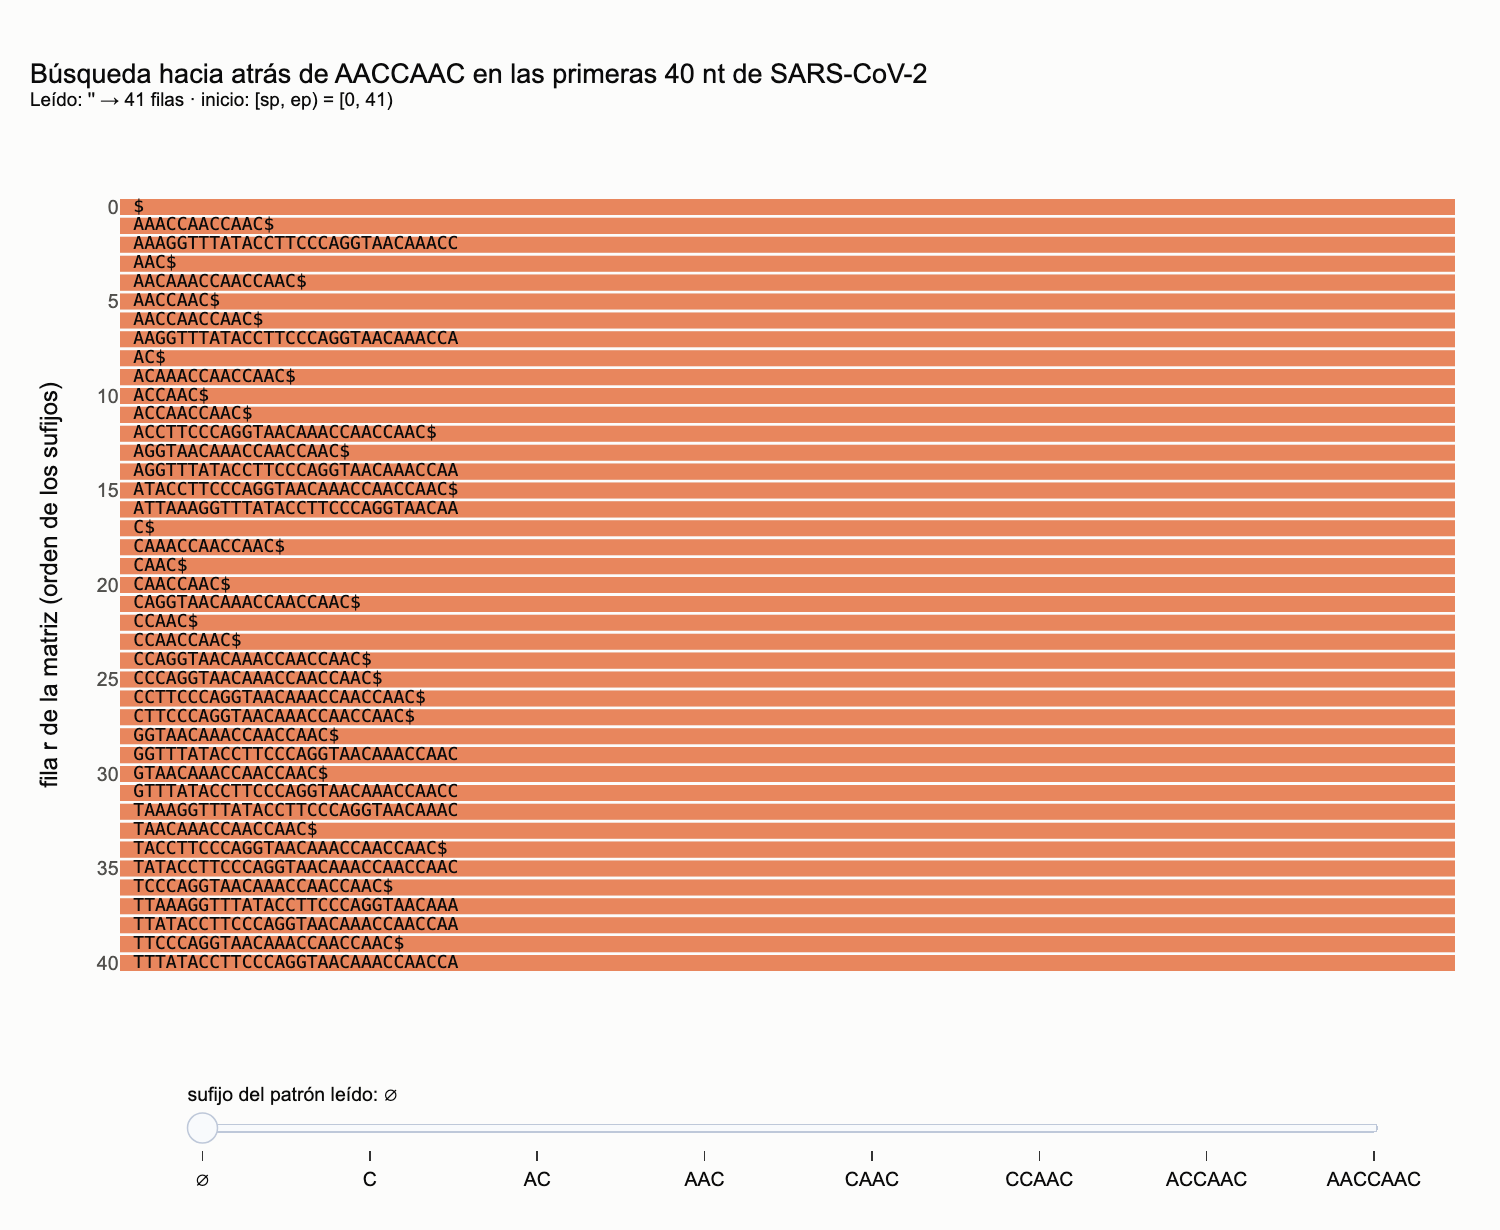

In [21]:
def backward_search_explorer(text, pattern, title):
    sa = suffix_array_naive(text)
    L = bwt_from_sa(text, sa)
    C = build_C(L)
    _, steps = backward_search(L, C, pattern, trace=True)
    n = len(text)
    rows = list(range(n))
    esc = lambda t: t.replace("$", "&#36;")           # evita que Plotly lea '$…$' como LaTeX
    base_hover = [f"fila r = {i} · SA[r] = {sa[i]}<br>L[{i}] = {esc(L[i])}<br>sufijo: {esc(text[sa[i]:sa[i] + 30])}" for i in rows]
    fig = go.Figure()
    fig.add_trace(go.Bar(x=[1] * n, y=rows, orientation="h", marker_color=ec.GRID, width=0.85,
                         hovertext=base_hover, hovertemplate="%{hovertext}<extra></extra>", showlegend=False))
    titles = []
    for s, (c, sp, ep) in enumerate(steps):
        read = pattern[len(pattern) - s:] if s else ""
        inside = [i for i in rows if sp <= i < ep]
        hov = [f"<b>dentro del bloque</b> [{sp}, {ep})<br>{base_hover[i]}<br>empieza por '{read}'" for i in inside]
        fig.add_trace(go.Bar(x=[1] * len(inside), y=inside, orientation="h", marker_color=ec.ORANGE, width=0.85,
                             opacity=0.75, hovertext=hov, hovertemplate="%{hovertext}<extra></extra>", visible=(s == 0),
                             showlegend=False))
        if s == 0:
            eq = f"inicio: [sp, ep) = [0, {n})"
        else:
            _, sp0, ep0 = steps[s - 1]
            eq = (f"letra {c}: sp' = C[{c}] + Occ({c},{sp0}) = {C[c]} + {occ_naive(L, c, sp0)} = {sp} · "
                  f"ep' = C[{c}] + Occ({c},{ep0}) = {C[c]} + {occ_naive(L, c, ep0)} = {ep}")
        n_hits = max(0, ep - sp)
        titles.append(esc(f"{title}<br><sup>Leído: '{read}' → {n_hits} filas · {eq}</sup>"))
    fig.add_trace(go.Scatter(x=[0.01] * n, y=rows, mode="text", text=[esc(text[sa[i]:sa[i] + 30]) for i in rows],
                             textposition="middle right", hoverinfo="skip", showlegend=False,
                             textfont=dict(family="DejaVu Sans Mono, monospace", size=12, color=ec.INK)))
    slider_steps = []
    for s in range(len(steps)):
        vis = [True] + [k == s for k in range(len(steps))] + [True]
        slider_steps.append(dict(method="update", label=(pattern[len(pattern) - s:] if s else "∅"),
                                 args=[{"visible": vis}, {"title.text": titles[s]}]))
    fig.update_yaxes(autorange="reversed", title="fila r de la matriz (orden de los sufijos)", dtick=5, showgrid=False)
    fig.update_xaxes(visible=False, range=[0, 1])
    fig.update_layout(title=dict(text=titles[0]), barmode="overlay", height=820, bargap=0.05,
                      margin=dict(t=110, b=150, l=80, r=30),
                      sliders=[dict(active=0, steps=slider_steps, currentvalue=dict(prefix="sufijo del patrón leído: "),
                                    x=0.05, len=0.9, y=-0.03, yanchor="top", pad=dict(t=30))])
    return fig

backward_search_explorer(T40, PAT, f"Búsqueda hacia atrás de {PAT} en las primeras 40 nt de SARS-CoV-2").show()

> 🔎 **Qué observamos.** En el primer paso el bloque abarca las 11 filas que empiezan por `C`; a medida que el patrón
> crece hacia la izquierda, el bloque se desplaza a otra región de la matriz (las filas que empiezan por `A`, luego por
> `C`…) y se estrecha, hasta quedar en 2 filas: $\mathrm{SA} = 29$ y $\mathrm{SA} = 33$. El explorador permite verificar
> a mano cada número de la ecuación en el título.

> ✅ **Compruebe su comprensión.** Usando la tabla $\mathrm{Occ}$ de `GATTACAGATTACA$`, busque a mano `ACA`.
> (Respuesta: `A` → $[1, 7)$; `C` → $sp' = 7 + \mathrm{Occ}(C,1) = 7$, $ep' = 7 + \mathrm{Occ}(C,7) = 7 + 2 = 9$; `A` →
> $sp' = 1 + \mathrm{Occ}(A,7) = 1 + 1 = 2$, $ep' = 1 + \mathrm{Occ}(A,9) = 1 + 3 = 4$. Bloque $[2, 4)$: $4 - 2 = 2$
> apariciones, en $\mathrm{SA}[2] = 11$ y $\mathrm{SA}[3] = 4$.)

## 9. Localizar: el arreglo de sufijos muestreado

La búsqueda hacia atrás nos da el bloque $[sp, ep)$, es decir, **cuántas** veces aparece el patrón ($ep - sp$). Para
un mapeador necesitamos además **dónde**: las posiciones $\mathrm{SA}[sp], \dots, \mathrm{SA}[ep - 1]$. Guardar el
arreglo de sufijos completo devolvería el problema de memoria (4 bytes por base). La solución es guardar sólo **una
muestra**.

### La idea

Guardamos $\mathrm{SA}[r]$ únicamente para las filas cuyo valor es **múltiplo de $s$** (por ejemplo, $s = 32$). Para
una fila $r$ no muestreada, aplicamos $\mathrm{LF}$ repetidamente: cada salto retrocede **una** posición en el texto.
Si hicieron falta $j$ saltos para caer en una fila muestreada, cuyo valor conocemos, entonces:

$$
\boxed{\;\mathrm{SA}[r] = \mathrm{SA}\big[\mathrm{LF}^{j}(r)\big] + j\;}, \qquad 0 \le j < s
$$

| Símbolo | Significado |
|---|---|
| $s$ | intervalo de muestreo del arreglo de sufijos: se guarda una posición de cada $s$ |
| $\mathrm{LF}^{j}(r)$ | aplicar $\mathrm{LF}$ $j$ veces a la fila $r$ |
| $j$ | saltos hasta la primera fila muestreada (en promedio, $(s-1)/2$) |
| memoria del muestreo | $\approx b\,n/s$ bits, con $b = 32$ bits por entero: $4n/s$ bytes |

Es como buscar una dirección en una calle en la que sólo una casa de cada 32 tiene el número a la vista: se camina
contando casas hasta encontrar un número y se hace la resta.

### Ejemplo a mano ($s = 4$)

En `GATTACAGATTACA$` guardamos sólo las filas con $\mathrm{SA} \in \{0, 4, 8, 12\}$: filas 10, 3, 5 y 7. Para localizar las
filas 13 y 14 de `TTA`:

* Fila 13: no muestreada. $L[13] = $ `A`, $\mathrm{LF}(13) = 1 + 4 = 5$; la fila 5 está muestreada con
  $\mathrm{SA}[5] = 8$. Tras $j = 1$ salto: $\mathrm{SA}[13] = 8 + 1 = 9$. ✔
* Fila 14: $L[14] = $ `A`, $\mathrm{LF}(14) = 1 + 5 = 6$ (no muestreada); $L[6] = $ `G`, $\mathrm{LF}(6) = 9 + 1 = 10$,
  muestreada con $\mathrm{SA}[10] = 0$. Tras $j = 2$ saltos: $\mathrm{SA}[14] = 0 + 2 = 2$. ✔

### Un índice FM completo y compacto

Juntamos todas las piezas en una clase. Guardar $\mathrm{Occ}$ completa serían cuatro enteros por posición: para el
genoma humano, $4 \times 32 \times 3.1\times10^{9}$ bits, unos 50 GB, ¡peor que el arreglo de sufijos! Por eso
guardamos sus valores sólo cada $d$ filas (**puntos de control**, *checkpoints*) y contamos las letras que faltan
directamente en $L$, como máximo $d - 1$ (con $L$ a 2 bits por base, ese recuento se hace con operaciones de bits
sobre unas pocas palabras de máquina):

$$
\mathrm{Occ}(c, r) = \underbrace{\mathrm{Occ}\big(c,\ d\lfloor r/d \rfloor\big)}_{\text{guardado}}
\;+\; \#\{\,c \text{ en } L[d\lfloor r/d \rfloor\,..\,r-1]\,\}
$$

Sumando las tres piezas (la BWT a 2 bits por base, los puntos de control de las 4 bases y la muestra del arreglo de
sufijos), la memoria total del índice, **en bits**, es (ecuación 07-memoria del libro):

$$
\mathcal{M}(d, s) \;=\; \underbrace{2n}_{L} \;+\; \underbrace{\frac{4\,b\,n}{d}}_{\mathrm{Occ}} \;+\;
\underbrace{\frac{b\,n}{s}}_{\mathrm{SA}},
$$

mientras que el tiempo de localizar cada aparición crece como $O(s)$ pasos de $\mathrm{LF}$, cada uno de costo $O(d)$.

| Símbolo | Significado |
|---|---|
| $\mathcal{M}(d, s)$ | memoria del índice, en bits |
| $n$ | longitud del texto indexado |
| $b$ | bits por entero almacenado ($b = \lceil \log_2 n \rceil = 32$ para el genoma humano) |
| $d$ | distancia entre puntos de control de $\mathrm{Occ}$ (en el código, `occ_step`) |
| $s$ | intervalo de muestreo del arreglo de sufijos (en el código, `sa_step`) |

**Ejemplo con números: el genoma humano** ($n = 3.1\times10^{9}$, $b = 32$, $d = 128$, $s = 32$):
$2n = 6.2\times10^{9}$ bits $= 0.775$ GB para $L$; $4 \cdot 32\, n / 128 = n$ bits $= 0.388$ GB para los puntos de
control; $32\, n / 32 = n$ bits $= 0.388$ GB para la muestra. Total: unos **1.55 GB**, la mitad que el genoma escrito
como texto (1 byte por base). Estos son, de hecho, los intervalos que describen Li y Durbin (2009) para BWA.

> 💡 Un detalle de implementación: para saber si una fila está muestreada, nuestra clase usa un diccionario; un
> programa en C suele usar un vector de 1 bit por fila ($n$ bits más, ≈0.39 GB en el genoma humano) o bien muestrea
> por **fila** ($r$ múltiplo de $s$) en lugar de por posición. La ecuación del libro, que seguimos aquí, no cuenta ese
> vector; si se incluyera, la cifra subiría a ~1.9 GB.

In [22]:
class FMIndex:
    """Índice FM desde cero: BWT (L), tabla C, Occ con puntos de control cada `occ_step` filas (d en el libro) y
    arreglo de sufijos muestreado cada `sa_step` posiciones del texto (s en el libro). `text` debe terminar en '$'."""

    def __init__(self, text, sa=None, occ_step=128, sa_step=32):
        assert text.endswith("$") and text.count("$") == 1
        sa = suffix_array(text) if sa is None else np.asarray(sa)
        self.n, self.occ_step, self.sa_step = len(text), occ_step, sa_step
        self.L = bwt_from_sa(text, sa)
        self.C = build_C(self.L)
        codes = np.frombuffer(self.L.encode(), dtype=np.uint8)
        self.checkpoints = {}
        for c in self.C:
            cum = np.r_[0, np.cumsum(codes == ord(c), dtype=np.uint32)]
            self.checkpoints[c] = cum[::occ_step].tolist()
        keep = np.flatnonzero(sa % sa_step == 0)                  # filas muestreadas
        self.sa_sample = dict(zip(keep.tolist(), sa[keep].tolist()))

    def occ(self, c, r):
        """Occ(c, r), apariciones de c en L[0..r-1]: punto de control anterior + conteo de las letras restantes."""
        k = r // self.occ_step
        return self.checkpoints[c][k] + self.L.count(c, k * self.occ_step, r)

    def lf(self, r):
        c = self.L[r]
        return self.C[c] + self.occ(c, r)

    def count(self, pattern):
        """Búsqueda hacia atrás: devuelve el intervalo semiabierto (sp, ep); el patrón aparece ep - sp veces."""
        sp, ep = 0, self.n
        for c in reversed(pattern):
            if c not in self.C:
                return 0, 0
            sp, ep = self.C[c] + self.occ(c, sp), self.C[c] + self.occ(c, ep)
            if sp >= ep:
                return sp, sp                                     # bloque vacío
        return sp, ep

    def resolve(self, r):
        """SA[r] caminando con LF hasta una fila muestreada: SA[r] = SA[LF^j(r)] + j."""
        j = 0
        while r not in self.sa_sample:
            r = self.lf(r); j += 1
        return self.sa_sample[r] + j

    def locate(self, pattern):
        sp, ep = self.count(pattern)
        return sorted(self.resolve(r) for r in range(sp, ep))

    def memory_bytes(self, b=32):
        """Memoria de una implementación compacta (no la de los objetos de Python), según la ecuación del libro
        M(d, s) = 2n + 4bn/d + bn/s bits: L a 2 bits por letra, puntos de control de b bits para las 4 bases
        y muestra del SA de b bits. (No incluye el vector de marcas de filas muestreadas.)"""
        n = self.n
        return {"L (2 bits/base)": 2 * n / 8,
                "Occ (puntos de control)": 4 * b * n / self.occ_step / 8,
                "SA muestreado": b * n / self.sa_step / 8}

fm_toy = FMIndex(T_DNA, occ_step=4, sa_step=4)
print("filas muestreadas {fila: SA}:", fm_toy.sa_sample)
print("TTA:", fm_toy.count("TTA"), "→ posiciones", fm_toy.locate("TTA"))
print("ACA:", fm_toy.count("ACA"), "→ posiciones", fm_toy.locate("ACA"))
fm_book = FMIndex("TACATACAG$", occ_step=4, sa_step=4)          # el ejemplo del libro, con la clase completa
print("TACATACAG$ · ACA:", fm_book.count("ACA"), "→ posiciones", fm_book.locate("ACA"))
assert fm_book.count("ACA") == (1, 3) and fm_book.locate("ACA") == [1, 5]

filas muestreadas {fila: SA}: {3: 4, 5: 8, 7: 12, 10: 0}
TTA: (13, 15) → posiciones [2, 9]
ACA: (2, 4) → posiciones [4, 11]
TACATACAG$ · ACA: (1, 3) → posiciones [1, 5]


¿Cuánto cuesta el muestreo? Lo medimos en el genoma de SARS-CoV-2: para distintos pasos $s$, el número medio de saltos
$\mathrm{LF}$ por posición localizada y la memoria de la muestra.

✔ las posiciones reconstruidas coinciden con el arreglo de sufijos completo


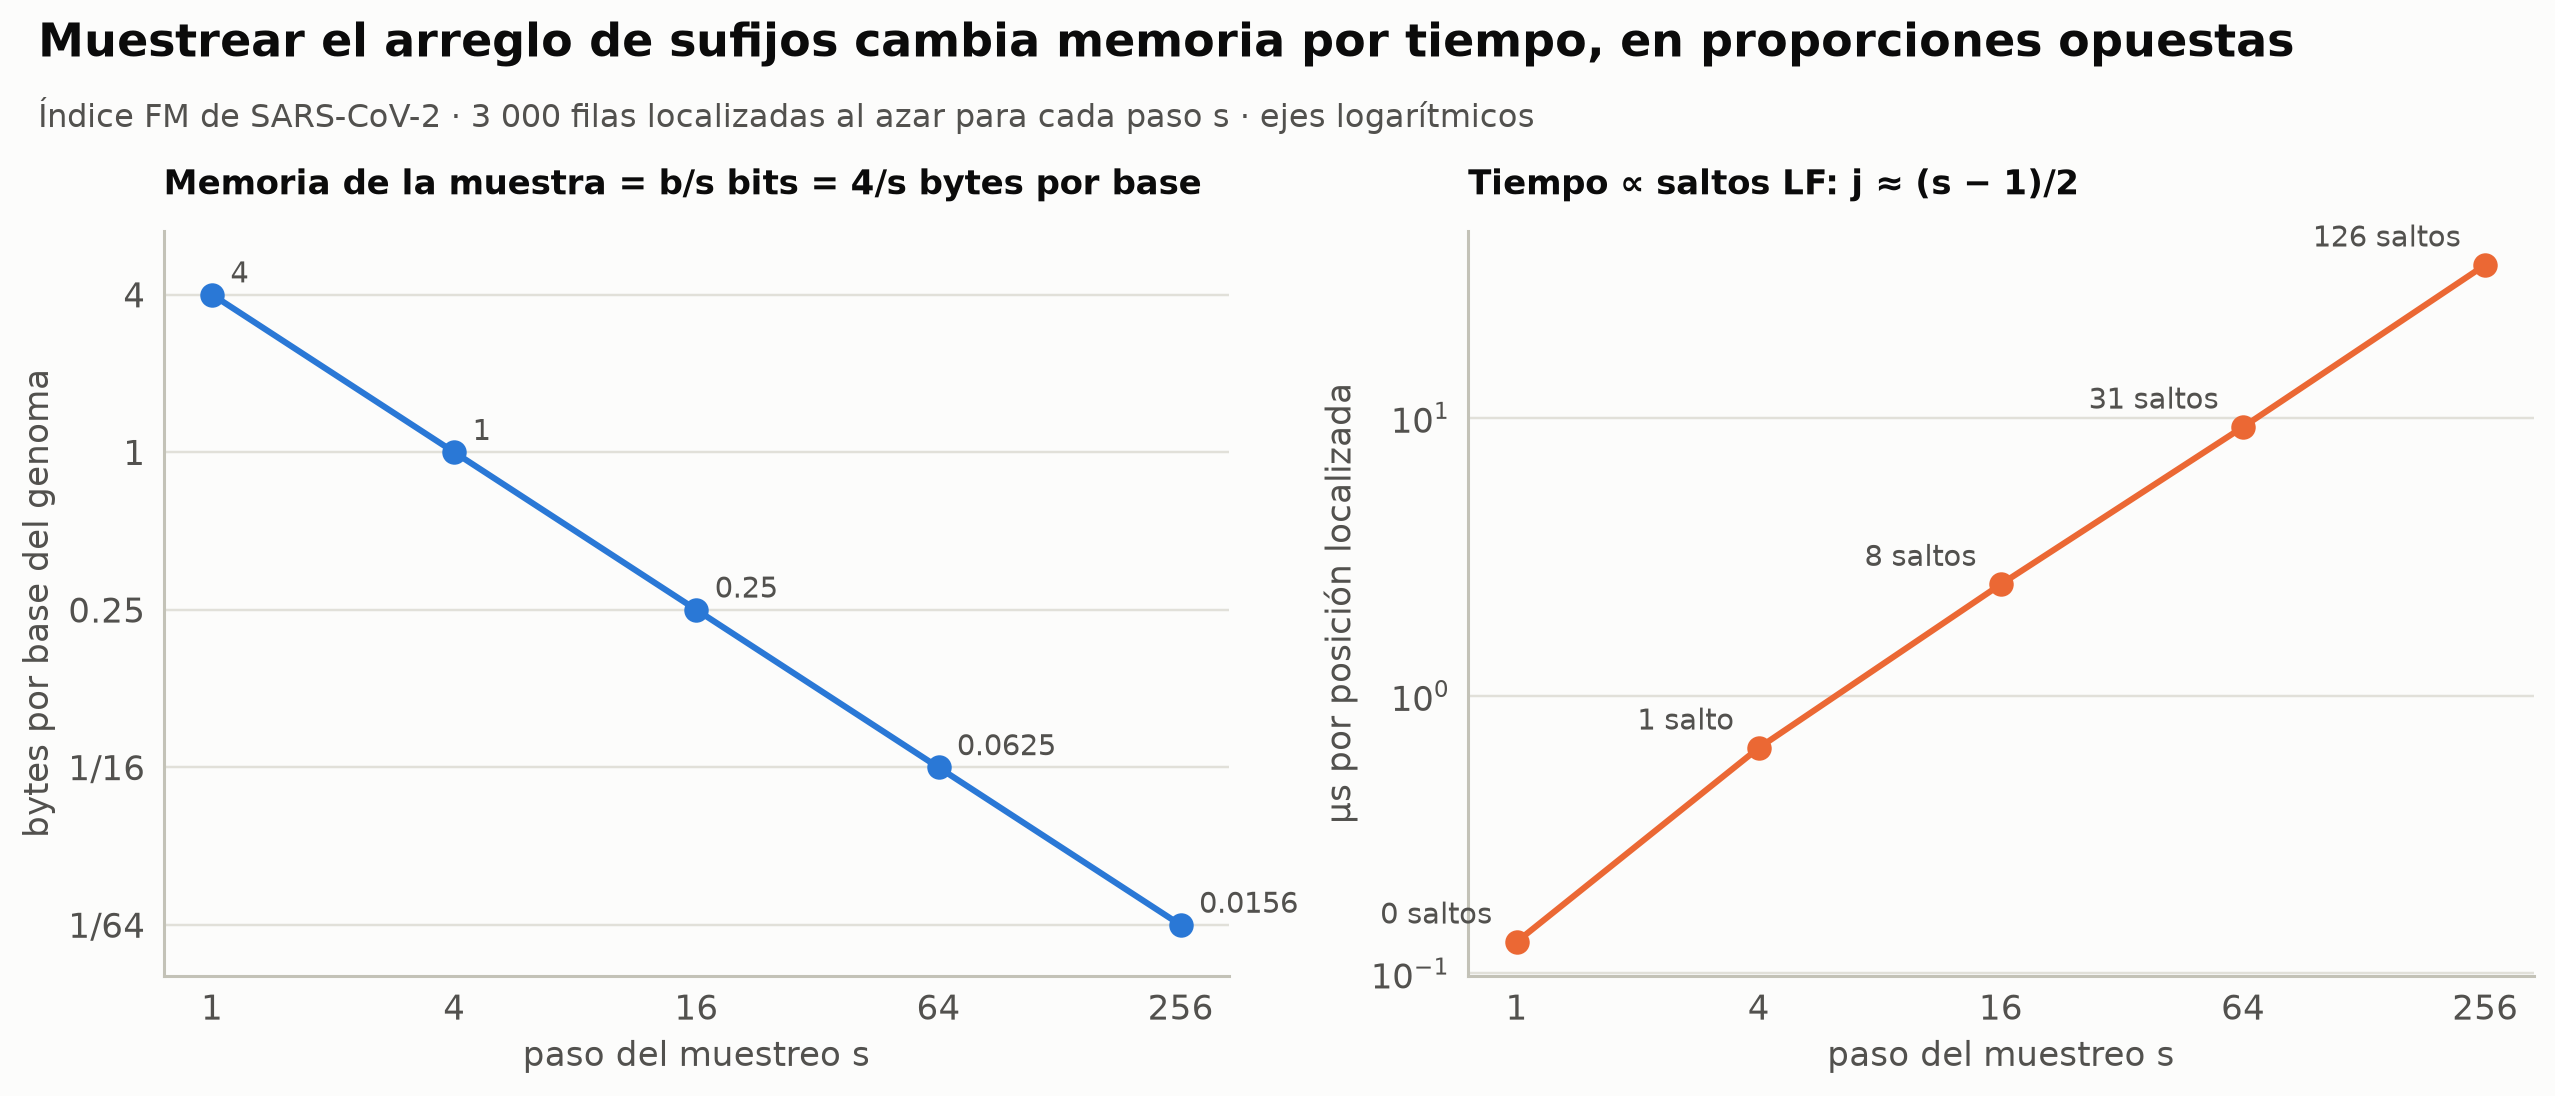

In [23]:
def all_positions_brute(text, pattern):
    """Todas las apariciones (incluso solapadas) con str.find: la verificación de referencia."""
    out, i = [], text.find(pattern)
    while i != -1:
        out.append(i); i = text.find(pattern, i + 1)
    return out

T_sars = SARS + "$"
sample_rows = []
probe_rows = rng.choice(len(T_sars), 3000, replace=False)
for s in (1, 4, 16, 64, 256):
    fm_s = FMIndex(T_sars, sa=SA_SARS, sa_step=s)
    t0 = time.perf_counter()
    got = [fm_s.resolve(int(i)) for i in probe_rows]
    dt = (time.perf_counter() - t0) / len(probe_rows)
    assert got == SA_SARS[probe_rows].tolist()
    steps = [(int(SA_SARS[r]) % s) for r in probe_rows]              # j = SA[r] mod s saltos
    sample_rows.append({"s": s, "saltos LF medios": np.mean(steps), "µs por posición": dt * 1e6,
                        "bytes de la muestra por base": fm_s.memory_bytes()["SA muestreado"] / len(T_sars)})
sample_df = pd.DataFrame(sample_rows)
print("✔ las posiciones reconstruidas coinciden con el arreglo de sufijos completo")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax1.plot(sample_df["s"], sample_df["bytes de la muestra por base"], "o-", color=ec.BLUE, lw=2)
for s, v in zip(sample_df["s"], sample_df["bytes de la muestra por base"]):
    ax1.annotate(f"{v:.3g}", (s, v), xytext=(6, 4), textcoords="offset points", fontsize=9.5, color=ec.INK_2)
ax1.set_xscale("log", base=2); ax1.set_yscale("log")
ax1.set_yticks([1 / 64, 1 / 16, 0.25, 1, 4], ["1/64", "1/16", "0.25", "1", "4"])
ax1.set_ylim(0.01, 7)
ax1.set_xticks([1, 4, 16, 64, 256], ["1", "4", "16", "64", "256"]); ax1.minorticks_off()
ax1.set_xlabel("paso del muestreo s"); ax1.set_ylabel("bytes por base del genoma")
ax1.set_title("Memoria de la muestra = b/s bits = 4/s bytes por base", loc="left", fontsize=11)
ax2.plot(sample_df["s"], sample_df["µs por posición"], "o-", color=ec.ORANGE, lw=2)
for s, v, k in zip(sample_df["s"], sample_df["µs por posición"], sample_df["saltos LF medios"]):
    ax2.annotate(f"{k:.0f} salto" + ("" if round(k) == 1 else "s"), (s, v), xytext=(-8, 6), textcoords="offset points", fontsize=9.5,
                 color=ec.INK_2, ha="right")
ax2.set_xscale("log", base=2); ax2.set_yscale("log")
ax2.set_xticks([1, 4, 16, 64, 256], ["1", "4", "16", "64", "256"]); ax2.minorticks_off()
ax2.set_xlabel("paso del muestreo s"); ax2.set_ylabel("µs por posición localizada")
ax2.set_title("Tiempo ∝ saltos LF: j ≈ (s − 1)/2", loc="left", fontsize=11)
ec.fig_title(fig, "Muestrear el arreglo de sufijos cambia memoria por tiempo, en proporciones opuestas",
             "Índice FM de SARS-CoV-2 · 3 000 filas localizadas al azar para cada paso s · ejes logarítmicos")
plt.show()

> 🔎 **Qué observamos.** Con $s = 1$ (el arreglo completo) localizar es inmediato pero cuesta 4 bytes por base; con
> $s = 32$ la muestra ocupa sólo 1/8 de byte por base (los 0.388 GB del genoma humano) y cada posición requiere, en
> promedio, unos 15 saltos $\mathrm{LF}$, que siguen siendo microsegundos. Las dos curvas son rectas de pendientes
> opuestas en escala log-log: duplicar $s$ divide la memoria entre dos y duplica el tiempo. Los mapeadores eligen un
> término medio: BWA usa $s = 32$.

## 10. Un índice FM para *E. coli*: verificación, *k*-mers repetidos y un mini-mapeador

Pasemos a escala real: el cromosoma completo de *E. coli* K-12 MG1655 (NC_000913.3, 4 641 652 pb). La etapa cara es
construir el arreglo de sufijos (una sola vez); después, cada consulta es cuestión de microsegundos.

> 🤔 **Antes de ejecutar, prediga:** la duplicación de prefijos termina cuando la longitud comparada supera la
> **repetición exacta más larga** del genoma. *E. coli* tiene 7 operones de ARN ribosomal de ~5 kb casi idénticos.
> ¿Cuántas rondas espera: unas 5, unas 13 o unas 22?

In [24]:
T_ECOLI = ECOLI + "$"
t0 = time.perf_counter()
SA_ECOLI = suffix_array(T_ECOLI)
t_sa = time.perf_counter() - t0
t0 = time.perf_counter()
FM_ECOLI = FMIndex(T_ECOLI, sa=SA_ECOLI, occ_step=128, sa_step=32)      # d = 128, s = 32, como en el libro
t_fm = time.perf_counter() - t0
print(f"Arreglo de sufijos: {t_sa:.1f} s · resto del índice FM (BWT, C, Occ, muestra): {t_fm:.1f} s")
print(f"Corridas en L: {n_runs(FM_ECOLI.L):,} de {len(T_ECOLI):,} letras (n/ρ = {len(T_ECOLI) / n_runs(FM_ECOLI.L):.2f})")

# Verificación: 400 patrones al azar (del genoma, inventados, en los bordes y de 1 letra) contra str.find
patterns = [ECOLI[i:i + m] for i, m in zip(rng.integers(0, len(ECOLI) - 40, 250), rng.integers(1, 40, 250))]
patterns += ["".join(rng.choice(list("ACGT"), m)) for m in rng.integers(4, 16, 140)]
patterns += [ECOLI[:25], ECOLI[-25:], "A", "C", "G", "T", "N", "ACGTN"]
t0 = time.perf_counter()
for p in patterns:
    sp, ep = FM_ECOLI.count(p)
    brute = all_positions_brute(ECOLI, p)
    assert ep - sp == len(brute), p
    if 0 < len(brute) <= 50:
        assert FM_ECOLI.locate(p) == brute, p
print(f"✔ {len(patterns)} patrones: conteos y posiciones idénticos a str.find ({time.perf_counter() - t0:.1f} s)")

Arreglo de sufijos: 11.2 s · resto del índice FM (BWT, C, Occ, muestra): 0.1 s
Corridas en L: 3,277,408 de 4,641,653 letras (n/ρ = 1.42)


✔ 398 patrones: conteos y posiciones idénticos a str.find (4.3 s)


### ¿Cuántas veces aparece un *k*-mer del genoma?

Con el índice podemos contar, para **cualquier** $k$, cuántas veces aparece un *k*-mer, sin haber fijado $k$ al
construir el índice (a diferencia de la tabla de la sección 2). Tomamos 3 000 posiciones al azar del genoma y, para
cada una, contamos cuántas veces aparece en el genoma el *k*-mer que empieza allí, en las dos hebras. Un *k*-mer que
aparece **una sola vez** es una semilla que ubica una lectura sin ambigüedad.

Si el genoma fuera una secuencia **al azar**, un *k*-mer concreto aparecería en otra posición concreta con
probabilidad $4^{-k}$, así que, como en la ecuación $\mathbb{E}[N_k] \approx G/4^k$ de la sección 2 pero contando
las dos hebras, el número esperado de apariciones **adicionales** sería:

$$
\mathbb{E}[\text{apariciones extra}] \approx \frac{2G}{4^{k}}
$$

| Símbolo | Significado |
|---|---|
| $G$ | longitud del genoma (4.64 Mb) |
| $2G$ | posiciones de inicio en las dos hebras |
| $4^{k}$ | número de *k*-mers posibles |

Para $k = 10$: $2 \times 4.64\times10^{6} / 4^{10} \approx 8.9$ apariciones extra; para $k = 14$: $\approx 0.035$;
para $k = 20$: $\approx 8\times10^{-6}$. Las desviaciones respecto de este cálculo revelan las **repeticiones** reales.

In [25]:
COMP = str.maketrans("ACGT", "TGCA")
def revcomp(s):
    return s.translate(COMP)[::-1]

def count_both_strands(fm, kmer):
    sp, ep = fm.count(kmer)
    n_f = ep - sp                     # intervalo semiabierto: ep - sp apariciones
    rc = revcomp(kmer)
    if rc == kmer:                    # palíndromo: no contar dos veces el mismo sitio
        return n_f
    sp, ep = fm.count(rc)
    return n_f + (ep - sp)

starts_k = rng.integers(0, len(ECOLI) - 40, 3000)
KS = (10, 14, 20, 32)
kmer_counts = {k: np.array([count_both_strands(FM_ECOLI, ECOLI[i:i + k]) for i in starts_k]) for k in KS}
summary_k = pd.DataFrame({
    "k": KS,
    "únicos (%)": [100 * np.mean(kmer_counts[k] == 1) for k in KS],
    "media de apariciones": [kmer_counts[k].mean() for k in KS],
    "esperado al azar (1 + 2G/4^k)": [1 + 2 * len(ECOLI) / 4 ** k for k in KS],
    "máximo": [kmer_counts[k].max() for k in KS],
})
summary_k.style.format({"únicos (%)": "{:.1f}", "media de apariciones": "{:.2f}",
                        "esperado al azar (1 + 2G/4^k)": "{:.3g}"}).hide(axis="index")

k,únicos (%),media de apariciones,esperado al azar (1 + 2G/4^k),máximo
10,0.6,18.23,9.85,284
14,86.9,1.27,1.03,80
20,97.3,1.13,1,56
32,97.5,1.11,1,17


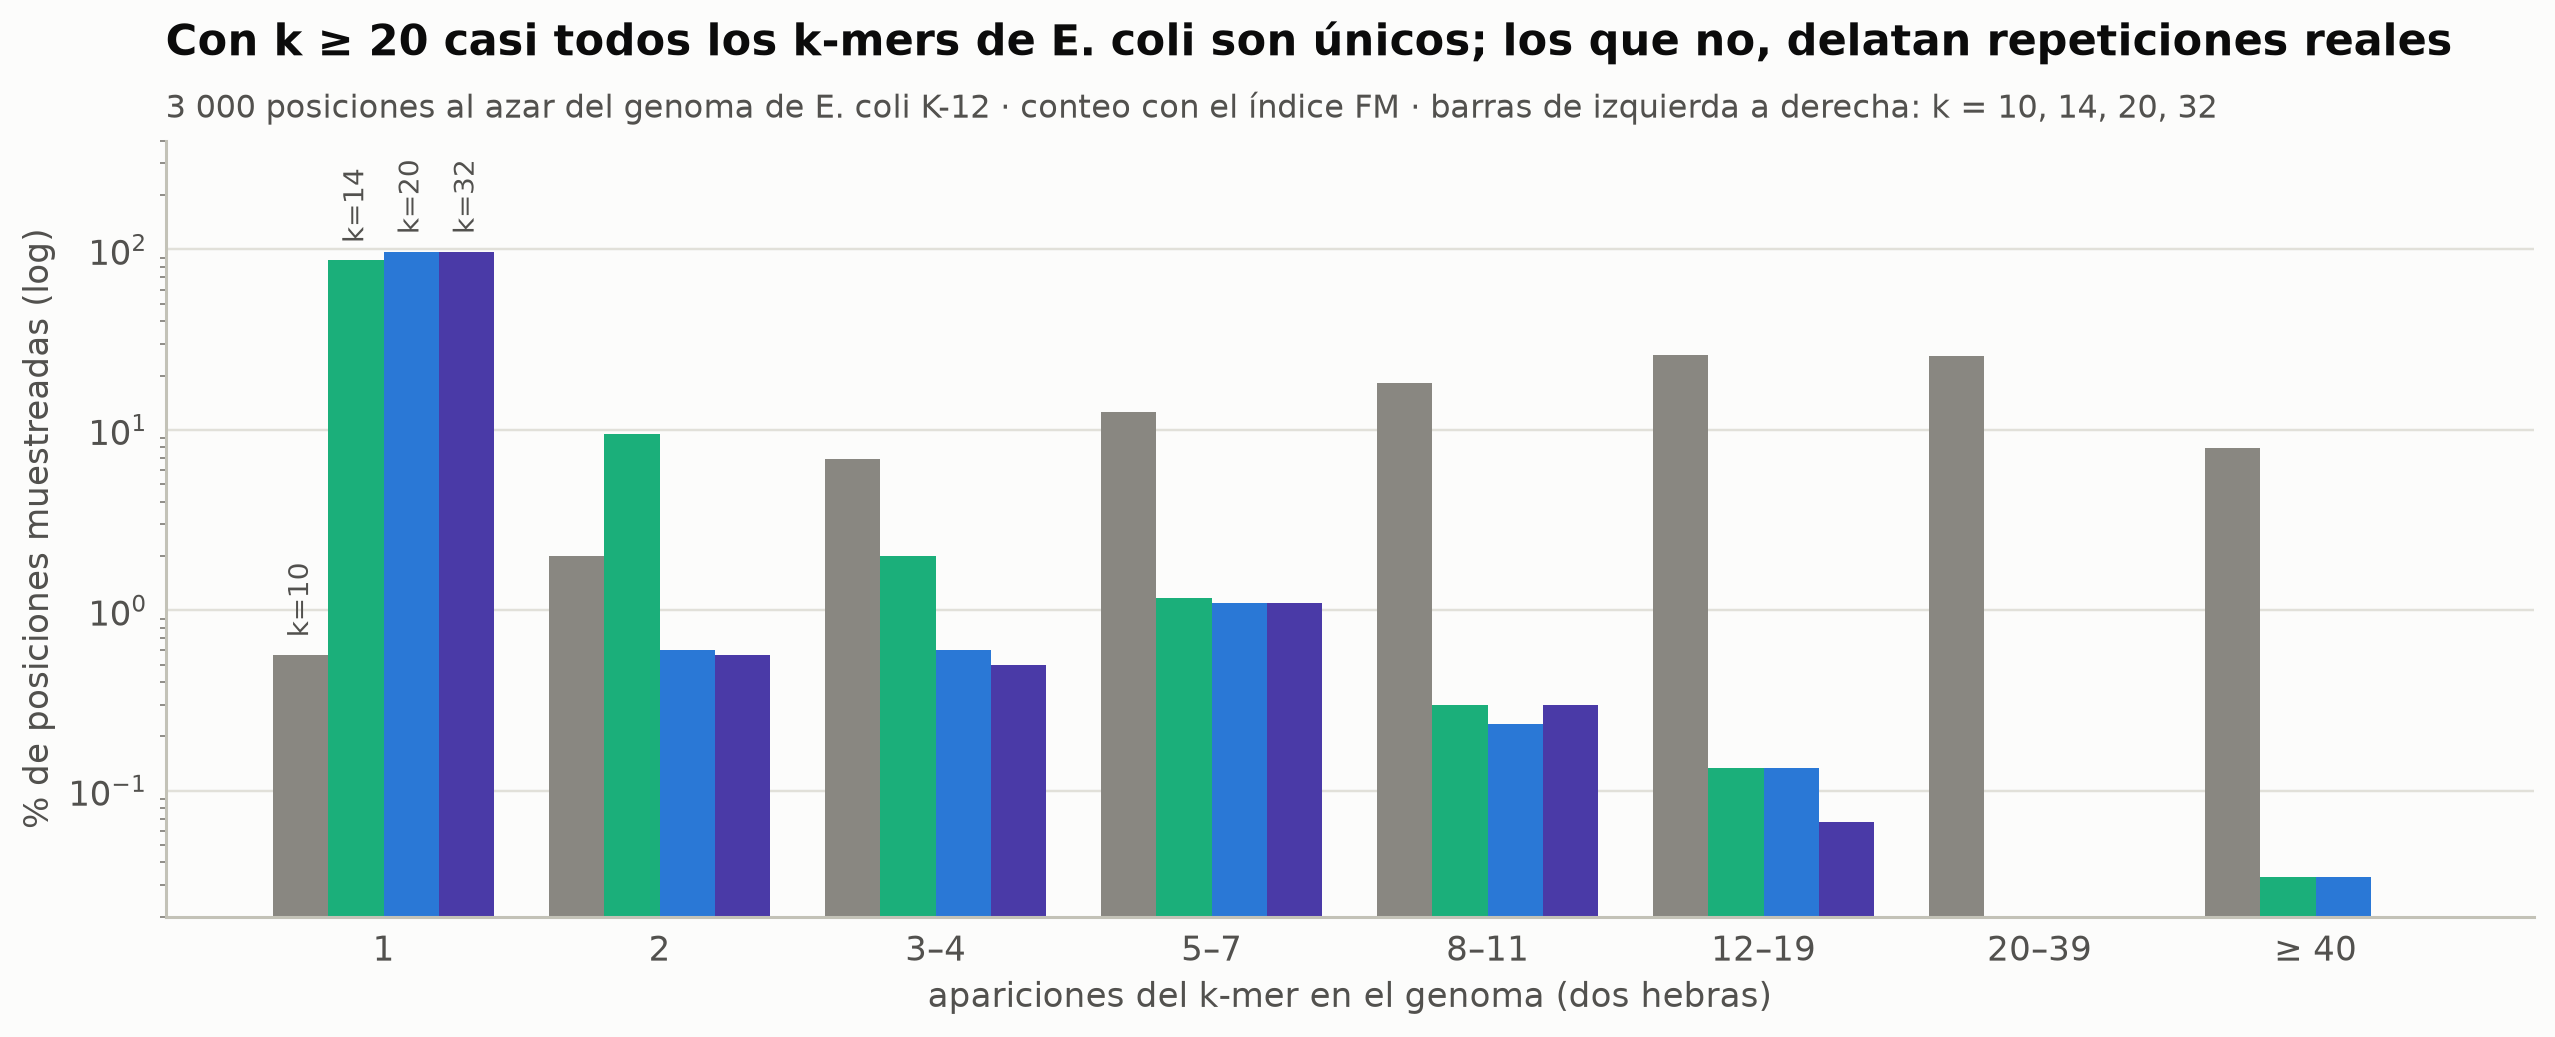

76 de 3000 posiciones tienen un 32-mer repetido; algunas de ellas:
  posición 3,428,495: GCCGTTACCCCACCAACAAGCTAATCCCATCT aparece 2 veces
  posición 3,941,966: AAACGGTAGCTAATACCGCATAACGTCGCAAG aparece 6 veces
  posición 4,039,532: AATTGAACTCGCTGTGAAGATGCAGTGTACCC aparece 7 veces
  posición 2,304,975: CACCCCGTAGGTTGGATAAGGCGGTTACGCCG aparece 2 veces
  posición 1,094,474: AACCTTTTGCGCTCATACTTCCACGCAGATTA aparece 5 veces
  posición 4,176,816: GTACTGGCTAAGCCGGGCACCATCAAGCCGCA aparece 2 veces


In [26]:
fig, ax = plt.subplots(figsize=(11.5, 4.6))
bins = [1, 2, 3, 5, 8, 12, 20, 40, 1000]
labels = ["1", "2", "3–4", "5–7", "8–11", "12–19", "20–39", "≥ 40"]
width = 0.2
x = np.arange(len(labels))
for k_i, (k, col) in enumerate(zip(KS, [ec.MUTED, ec.AQUA, ec.BLUE, ec.VIOLET])):
    h, _ = np.histogram(kmer_counts[k], bins=bins)
    frac = 100 * h / len(starts_k)
    ax.bar(x + (k_i - 1.5) * width, np.maximum(frac, 1e-9), width, color=col)
    ax.text(x[0] + (k_i - 1.5) * width, max(frac[0], 0.02) * 1.25, f"k={k}", ha="center", fontsize=9,
            color=ec.INK_2, rotation=90, va="bottom")
ax.set_yscale("log"); ax.set_ylim(0.02, 400)
ax.set_xticks(x, labels)
ax.set_xlabel("apariciones del k-mer en el genoma (dos hebras)"); ax.set_ylabel("% de posiciones muestreadas (log)")
ec.title(ax, "Con k ≥ 20 casi todos los k-mers de E. coli son únicos; los que no, delatan repeticiones reales",
         "3 000 posiciones al azar del genoma de E. coli K-12 · conteo con el índice FM · barras de izquierda a derecha: k = 10, 14, 20, 32")
plt.show()

rep = starts_k[kmer_counts[32] > 1]
print(f"{len(rep)} de {len(starts_k)} posiciones tienen un 32-mer repetido; algunas de ellas:")
for i in rep[:6]:
    print(f"  posición {i:>9,}: {ECOLI[i:i + 32]} aparece {count_both_strands(FM_ECOLI, ECOLI[i:i + 32])} veces")

> 🔎 **Qué observamos.** Con $k = 10$ los *k*-mers aparecen, en promedio, unas 18 veces: del mismo orden que las ~10
> que predice el modelo al azar, pero casi el doble, porque el genoma no es una secuencia aleatoria (algunos *k*-mers
> cortos son mucho más frecuentes que otros). En cualquier caso, una semilla de 10 letras no sirve para ubicar una lectura en una bacteria (y mucho menos en un genoma humano,
> 700 veces más grande). Con $k = 14$ cerca del 90 % ya son únicos, y el ~10 % que aparece dos veces supera lo que
> predice el azar (3.5 %): el genoma no es una secuencia aleatoria. Con $k = 20$ o $32$ **no** se llega al 100 %,
> a diferencia de lo que predice el azar ($\approx 10^{-5}$): ~2–3 % de las posiciones caen en **repeticiones reales**
> (los 7 operones de ARN ribosomal, las secuencias de inserción IS, genes duplicados), que aparecen 2–7 veces o más.
> Una lectura que cae allí será **multimapeada**: el índice la encuentra en varios lugares y no puede decidir cuál es
> el verdadero. La Lección 7.2 muestra cómo lo expresan los mapeadores con la calidad de mapeo (MAPQ).

### Un mini-mapeador de lecturas exactas

Simulamos 20 000 lecturas de 50 pb de *E. coli*, tomadas al azar de cualquiera de las dos hebras, con una tasa de
error de secuenciación de 0.5 % por base (sustituciones), como un Illumina razonable. El mapeador busca la lectura y su
reverso complementario con el índice FM y clasifica cada lectura como **única**, **múltiple** o **no mapeada**.

La probabilidad de que una lectura de $m = 50$ bases no tenga ningún error, con una tasa $e = 0.005$, es
$(1 - e)^{m} = 0.995^{50} \approx 0.78$: una de cada cinco lecturas tendrá al menos un error y la búsqueda exacta
fallará.

In [27]:
def simulate_reads(genome, n_reads, length, err, rng):
    """Lecturas de ambas hebras con sustituciones al azar. Devuelve (lecturas, inicio real, hebra, nº de errores)."""
    starts = rng.integers(0, len(genome) - length, n_reads)
    strands = rng.random(n_reads) < 0.5
    reads, n_err = [], []
    for s, minus in zip(starts, strands):
        r = genome[s:s + length]
        if minus:
            r = revcomp(r)
        r = np.array(list(r))
        pos = np.flatnonzero(rng.random(length) < err)
        for p in pos:
            r[p] = rng.choice([b for b in "ACGT" if b != r[p]])
        reads.append("".join(r)); n_err.append(len(pos))
    return reads, starts, strands, np.array(n_err)

def map_exact(fm, read):
    """Mapea una lectura exacta en ambas hebras. Devuelve la lista de (posición, hebra)."""
    hits = [(p, "+") for p in fm.locate(read)]
    rc = revcomp(read)
    if rc != read:
        hits += [(p, "-") for p in fm.locate(rc)]
    return hits

reads, true_start, true_minus, n_err = simulate_reads(ECOLI, 20_000, 50, 0.005, rng)
t0 = time.perf_counter()
results = [map_exact(FM_ECOLI, r) for r in reads]
t_map = time.perf_counter() - t0
status_map = np.array(["no mapeada" if len(h) == 0 else ("única" if len(h) == 1 else "múltiple") for h in results])
correct = np.array([len(h) == 1 and h[0][0] == s for h, s in zip(results, true_start)])
print(f"{len(reads):,} lecturas mapeadas en {t_map:.1f} s ({1e6 * t_map / len(reads):.0f} µs por lectura, Python puro)")
print(pd.Series(status_map).value_counts().to_string())
print(f"Únicas en la posición correcta: {correct.sum():,} de {(status_map == 'única').sum():,}")
print(f"Lecturas sin errores: {np.mean(n_err == 0):.1%} (teoría 0.995^50 = {0.995 ** 50:.1%})")

20,000 lecturas mapeadas en 1.2 s (58 µs por lectura, Python puro)
única         15169
no mapeada     4478
múltiple        353
Únicas en la posición correcta: 15,169 de 15,169
Lecturas sin errores: 77.6% (teoría 0.995^50 = 77.8%)


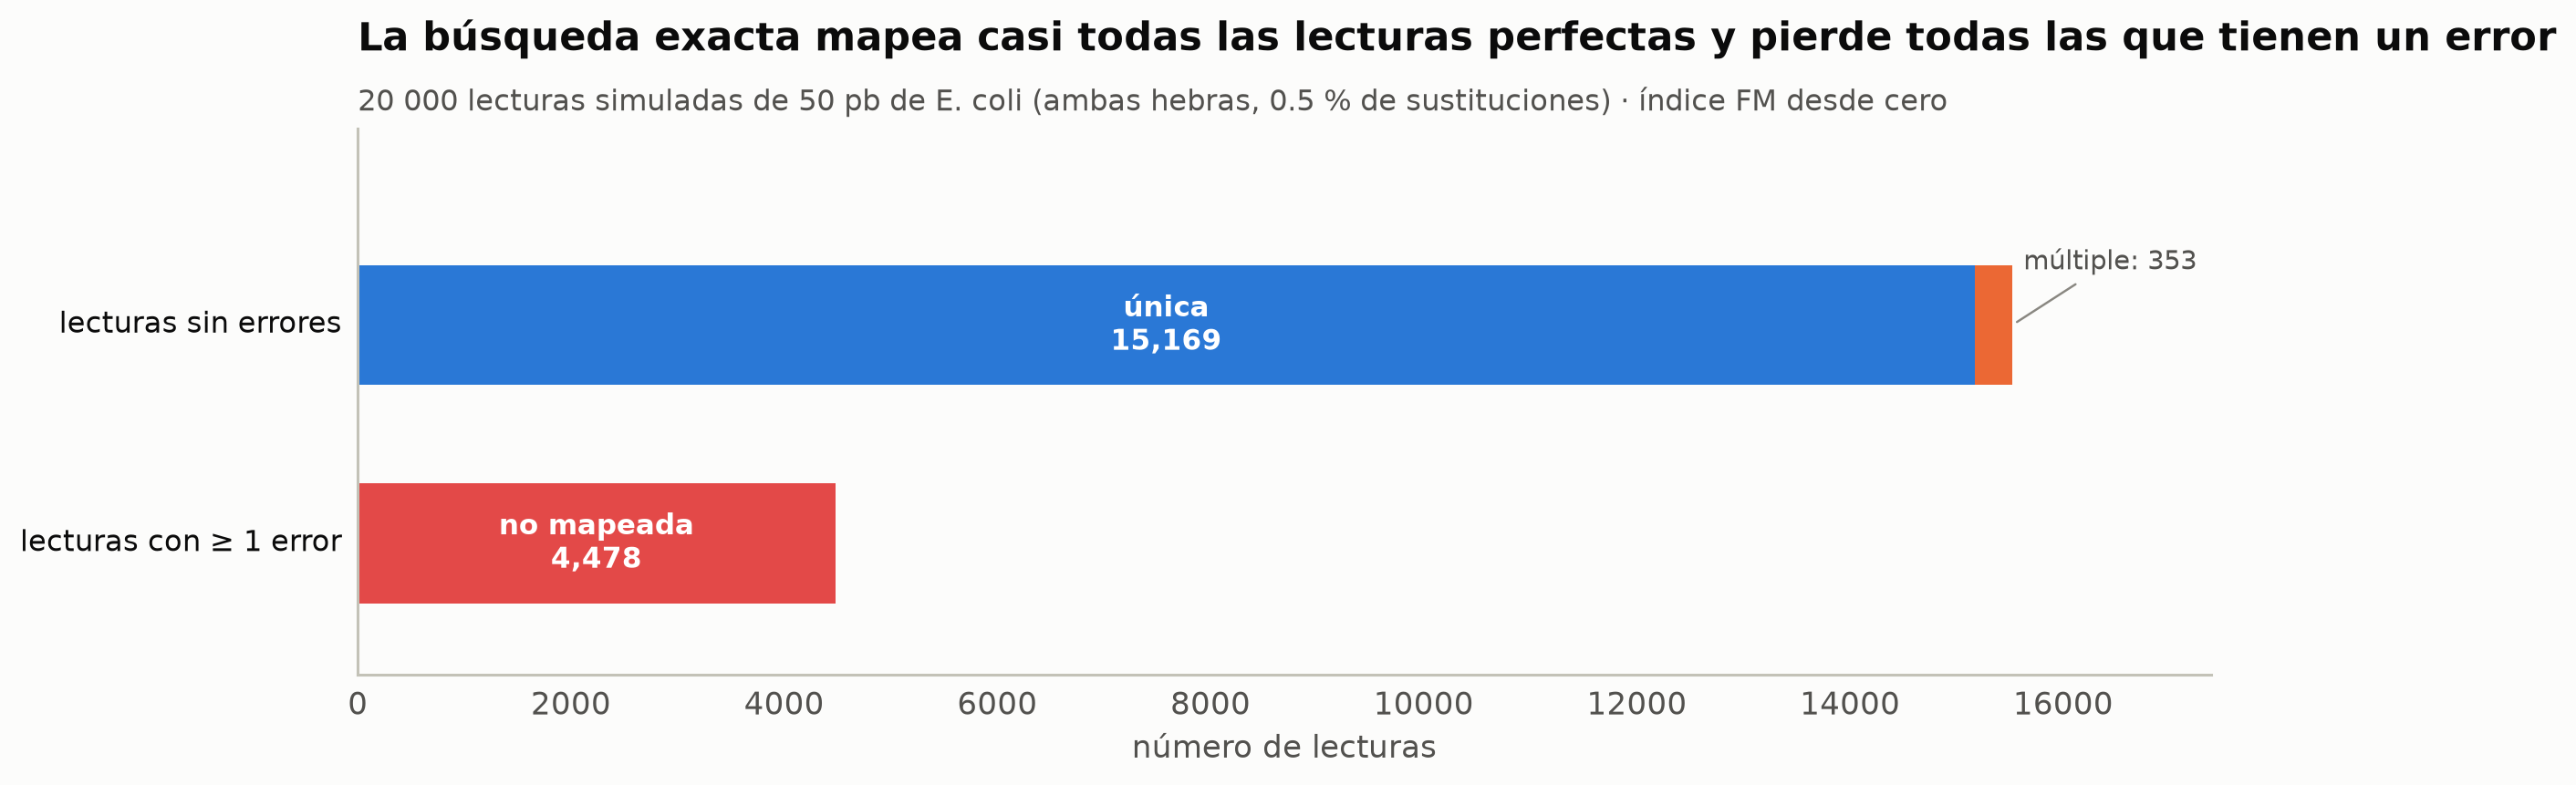

In [28]:
fig, ax = plt.subplots(figsize=(11, 3.8))
cats = ["única", "múltiple", "no mapeada"]
cols = {"única": ec.BLUE, "múltiple": ec.ORANGE, "no mapeada": ec.RED}
for y, (lab, mask) in enumerate([("lecturas sin errores", n_err == 0), ("lecturas con ≥ 1 error", n_err > 0)]):
    left = 0
    for c in cats:
        v = np.sum(status_map[mask] == c)
        ax.barh(1 - y, v, left=left, color=cols[c], height=0.55)
        if v > 2000:
            ax.text(left + v / 2, 1 - y, f"{c}\n{v:,}", ha="center", va="center", fontsize=10, color="white",
                    fontweight="bold")
        elif v > 0:
            ax.annotate(f"{c}: {v:,}", (left + v, 1 - y), xytext=(4, 20), textcoords="offset points",
                        fontsize=9.5, color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=0.8))
        left += v
    ax.text(-150, 1 - y, lab, ha="right", va="center", fontsize=10.5, color=ec.INK)
ax.set_yticks([]); ax.set_xlabel("número de lecturas"); ax.set_ylim(-0.6, 1.9)
ax.set_xlim(0, np.sum(n_err == 0) * 1.12)
ec.title(ax, "La búsqueda exacta mapea casi todas las lecturas perfectas y pierde todas las que tienen un error",
         "20 000 lecturas simuladas de 50 pb de E. coli (ambas hebras, 0.5 % de sustituciones) · índice FM desde cero")
plt.show()

> 🔎 **Qué observamos.** Todas las lecturas sin errores se mapean, y las únicas caen **exactamente** en su posición de
> origen. Un ~1–2 % es múltiple: vienen de repeticiones. Pero **todas** las lecturas con al menos un error (~22 %) se
> pierden: una sola base distinta basta para que el bloque $[sp, ep)$ se vacíe. Un mapeador real debe tolerar
> diferencias, tanto errores de secuenciación como variantes genuinas del individuo, que son justamente lo que
> queremos detectar. Lo resolveremos en la sección 12.

## 11. ¿Cuánto más rápido? Tiempo y memoria frente a la búsqueda ingenua

Comparamos tres formas de encontrar **todas** las apariciones de un patrón:

1. **Ingenua en Python**: recorrer el genoma posición por posición y comparar. Costo $O(G \cdot m)$ en el peor caso,
   $\approx O(G)$ en la práctica.
2. **`str.find` repetido**: la misma idea, pero implementada en C dentro de Python y con trucos para saltar
   posiciones. También $O(G)$, pero decenas de veces más rápida por operación.
3. **Índice FM** (`count` + `locate`), en Python puro: $O(m\,d + \text{occ}\cdot s\,d)$, **independiente de $G$**.

Medimos cada una con `timeit` (el mínimo de varias repeticiones) variando la longitud del patrón $m$ sobre el genoma
completo de *E. coli*, y la longitud del genoma $G$ (prefijos de *E. coli*) con un patrón fijo de 32 pb.

> 🤔 **Antes de ejecutar, prediga:** el índice FM está escrito en Python, que es unas 50–100 veces más lento que C.
> ¿Le ganará aun así a `str.find`, que está escrito en C?

In [29]:
def naive_python(text, pattern):
    """Búsqueda ingenua: compara el patrón en cada posición del texto."""
    m, first, hits = len(pattern), pattern[0], []
    for i in range(len(text) - m + 1):
        if text[i] == first and text[i:i + m] == pattern:
            hits.append(i)
    return hits

def best_time(fn, number=3, repeat=3):
    return min(timeit.repeat(fn, number=number, repeat=repeat)) / number

# (a) tiempo frente a la longitud del patrón, genoma completo
time_m = []
for m in (8, 16, 32, 64, 128, 256):
    p = ECOLI[2_000_000:2_000_000 + m]
    time_m.append({"m": m, "índice FM": best_time(lambda: FM_ECOLI.locate(p), number=20),
                   "índice FM (sólo contar)": best_time(lambda: FM_ECOLI.count(p), number=50),
                   "apariciones": len(all_positions_brute(ECOLI, p)),
                   "str.find": best_time(lambda: all_positions_brute(ECOLI, p), number=2)})
time_m = pd.DataFrame(time_m)

# (b) tiempo frente a la longitud del genoma, patrón de 32 pb que sí aparece
time_n = []
for n in (30_000, 150_000, 600_000, len(ECOLI)):
    text_n = ECOLI[:n]
    fm_n = FM_ECOLI if n == len(ECOLI) else FMIndex(text_n + "$")
    p = text_n[n // 2:n // 2 + 32]
    assert fm_n.locate(p) == all_positions_brute(text_n, p) == naive_python(text_n, p)
    time_n.append({"n": n, "índice FM": best_time(lambda: fm_n.locate(p), number=20),
                   "str.find": best_time(lambda: all_positions_brute(text_n, p), number=2),
                   "ingenua (Python)": best_time(lambda: naive_python(text_n, p), number=1, repeat=2)})
time_n = pd.DataFrame(time_n)
print("Tiempos en microsegundos:")
print((time_m.set_index("m").drop(columns="apariciones") * 1e6).round(1).to_string())
print((time_n.set_index("n") * 1e6).round(1).to_string())

Tiempos en microsegundos:
     índice FM  índice FM (sólo contar)  str.find
m                                                
8        645.9                      3.7    5144.2
16        14.3                      6.2    3538.5
32        13.1                     12.6    6693.1
64        26.0                     52.2    4474.7
128       52.8                     52.7    4483.6
256      107.0                    109.6    4892.5
         índice FM  str.find  ingenua (Python)
n                                             
30000         18.1      38.3             959.5
150000        19.0      96.8            4788.5
600000        12.5     588.7           26105.0
4641652       19.4    6035.3          153987.2


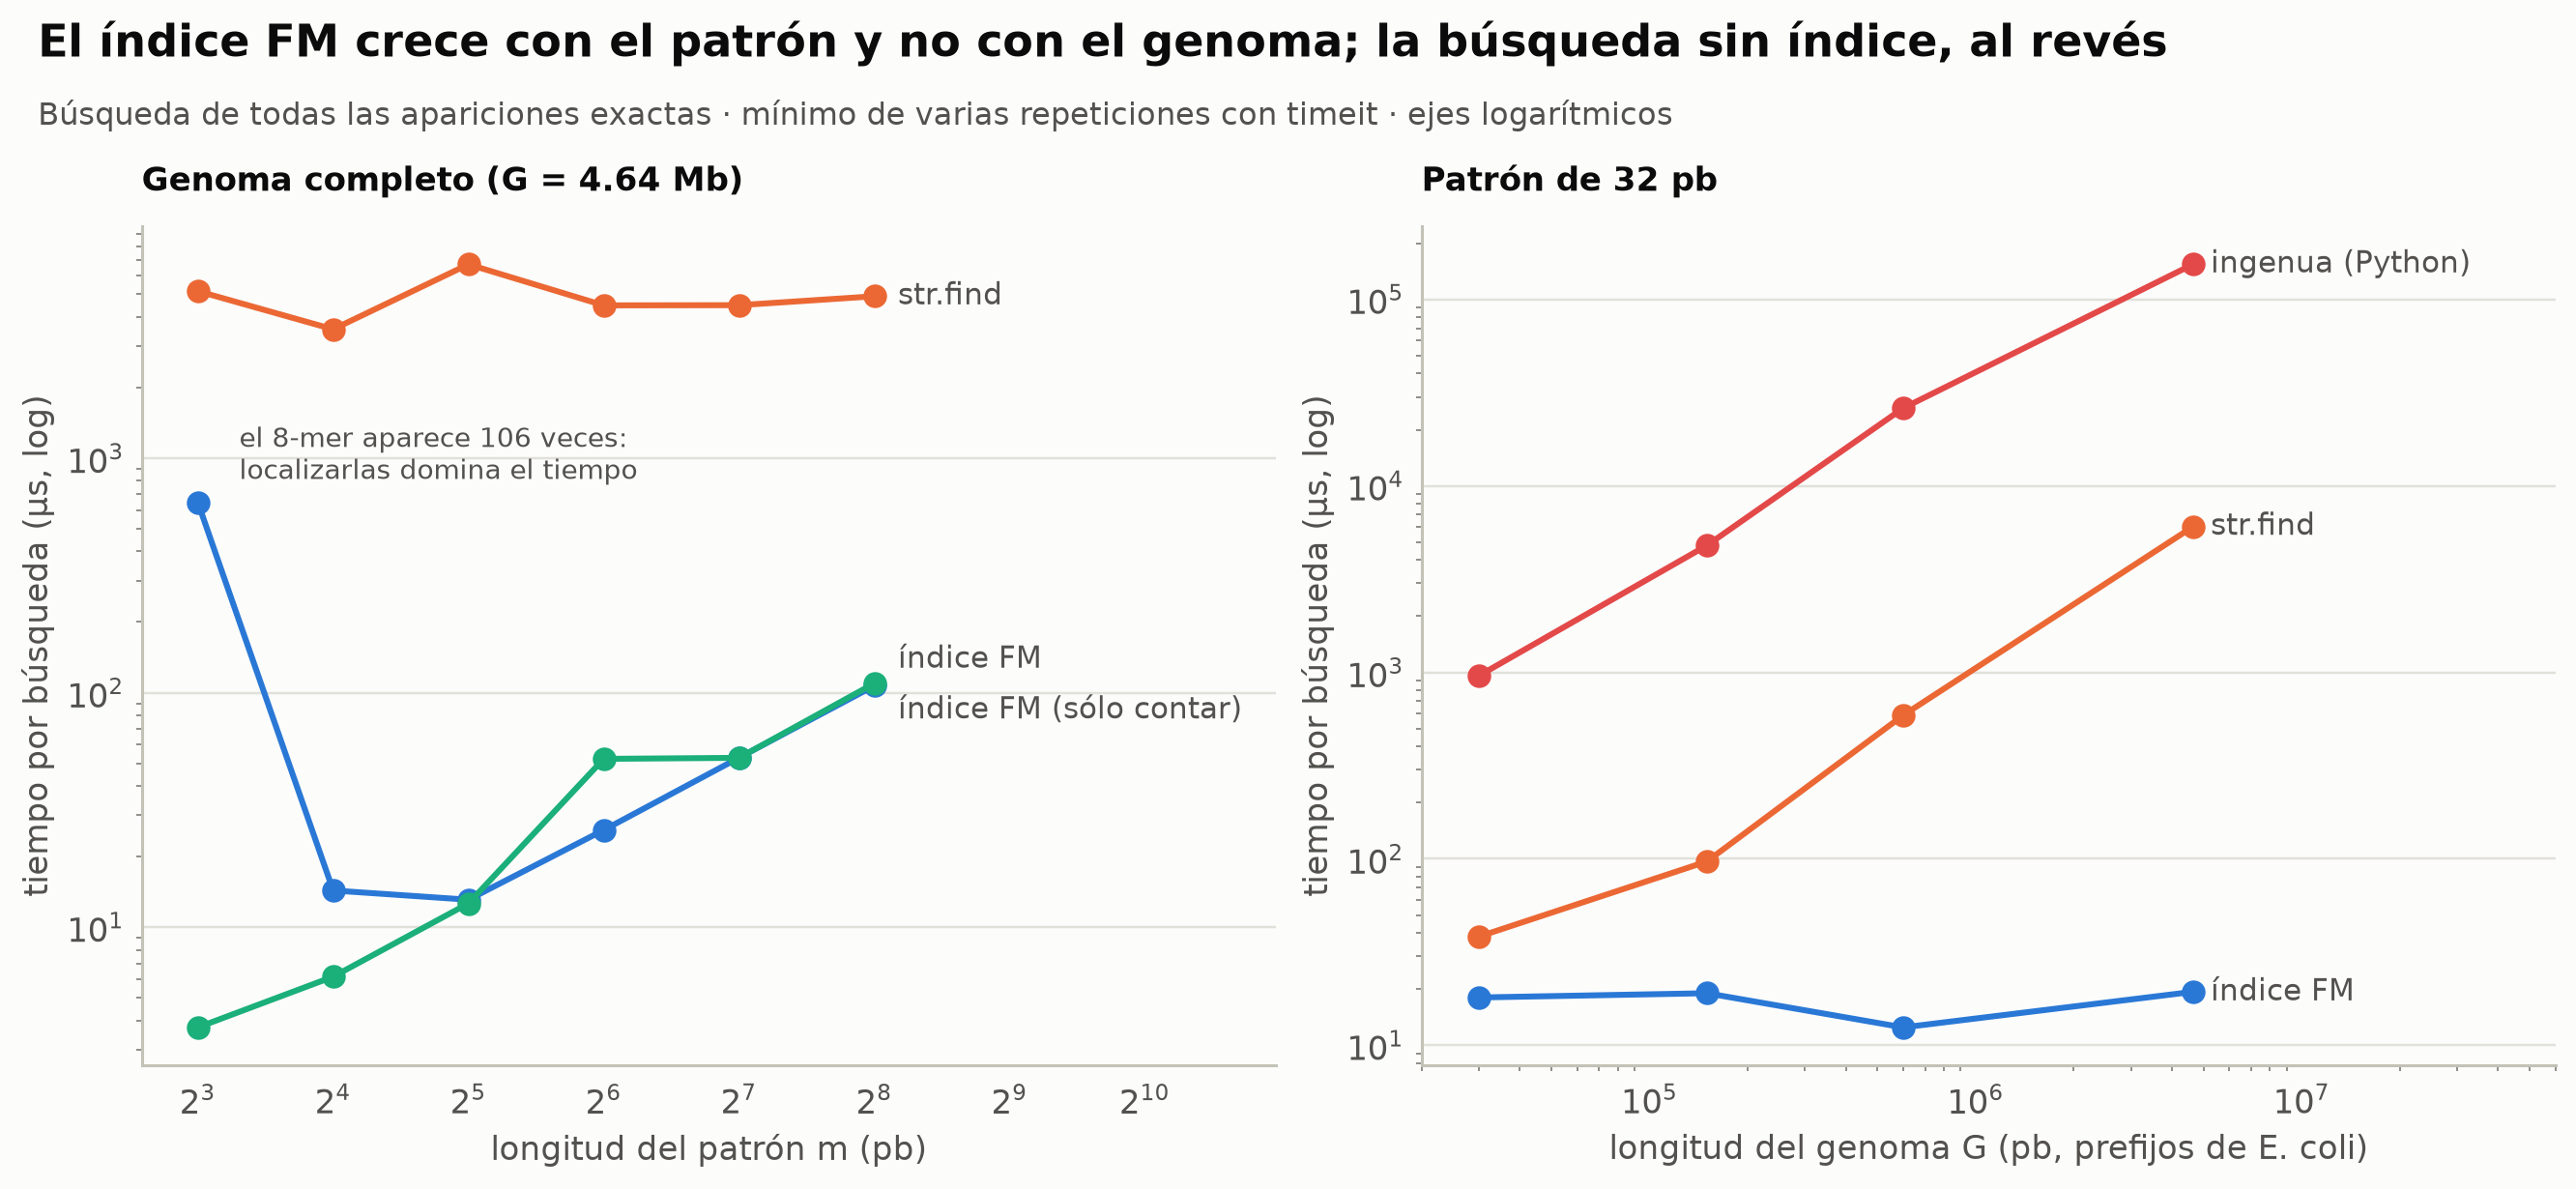

En el genoma completo, el índice FM (Python) es ~312 veces más rápido que str.find (C)


In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))
styles = {"índice FM": ec.BLUE, "str.find": ec.ORANGE, "ingenua (Python)": ec.RED, "índice FM (sólo contar)": ec.AQUA}
for col, dy in (("índice FM", 9), ("índice FM (sólo contar)", -9), ("str.find", 0)):
    ax1.plot(time_m["m"], time_m[col] * 1e6, "o-", color=styles[col], lw=2)
    ax1.annotate(col, (time_m["m"].iloc[-1], time_m[col].iloc[-1] * 1e6), xytext=(8, dy), textcoords="offset points",
                 va="center", fontsize=10, color=ec.INK_2)
ax1.set_xscale("log", base=2); ax1.set_yscale("log")
ax1.set_xlabel("longitud del patrón m (pb)"); ax1.set_ylabel("tiempo por búsqueda (µs, log)")
ax1.set_xlim(6, 2000)
m8 = time_m.iloc[0]
ax1.annotate(f"el 8-mer aparece {m8['apariciones']:.0f} veces:\nlocalizarlas domina el tiempo", (8, m8["índice FM"] * 1e6),
             xytext=(14, 8), textcoords="offset points", fontsize=9, color=ec.INK_2)
ax1.set_title(f"Genoma completo (G = {len(ECOLI) / 1e6:.2f} Mb)", loc="left", fontsize=11)
for col in ("índice FM", "str.find", "ingenua (Python)"):
    ax2.plot(time_n["n"], time_n[col] * 1e6, "o-", color=styles[col], lw=2)
    ec.label_end(ax2, time_n["n"].iloc[-1], time_n[col].iloc[-1] * 1e6, col)
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlim(2e4, 6e7)
ax2.set_xlabel("longitud del genoma G (pb, prefijos de E. coli)"); ax2.set_ylabel("tiempo por búsqueda (µs, log)")
ax2.set_title("Patrón de 32 pb", loc="left", fontsize=11)
ec.fig_title(fig, "El índice FM crece con el patrón y no con el genoma; la búsqueda sin índice, al revés",
             "Búsqueda de todas las apariciones exactas · mínimo de varias repeticiones con timeit · ejes logarítmicos")
plt.show()
ratio = time_n["str.find"].iloc[-1] / time_n["índice FM"].iloc[-1]
print(f"En el genoma completo, el índice FM (Python) es ~{ratio:,.0f} veces más rápido que str.find (C)")

> 🔎 **Qué observamos.** A la izquierda, el tiempo del índice FM **crece linealmente con $m$** (dos consultas a
> $\mathrm{Occ}$ por letra) mientras que `str.find` apenas depende de $m$: su costo lo domina recorrer los 4.6 millones
> de letras. La excepción es el 8-mer: aparece más de un centenar de veces y **localizar** cada aparición cuesta
> hasta $s$ saltos $\mathrm{LF}$; contarlas (línea verde) sigue costando microsegundos. A la derecha, las curvas sin
> índice suben en proporción a $G$ (pendiente 1 en escala log-log) y la del
> índice FM se queda **plana**. Aunque está escrito en Python, el índice le gana por dos a tres órdenes de magnitud a una
> búsqueda en C, y la ventaja crecería otras 700 veces en el genoma humano. Los mapeadores reales, escritos en C y
> con $\mathrm{Occ}$ optimizada a nivel de bits, hacen cada paso en decenas de nanosegundos.

### ¿Y la memoria?

Calculamos cuánto ocuparía cada índice en una implementación compacta (no en objetos de Python, que ocupan mucho
más), por base del genoma, con la ecuación $\mathcal{M}(d, s)$ de la sección 9, y lo extrapolamos al genoma humano
($n \approx G = 3.1\times10^{9}$).

In [31]:
fm_mem = FM_ECOLI.memory_bytes()
per_base_fm = sum(fm_mem.values()) / FM_ECOLI.n
mem = pd.DataFrame([
    {"índice": "texto solo", "bytes por base": 1.0},
    {"índice": "tabla de k-mers (estimado)", "bytes por base": 4 + 1 + 0.5},
    {"índice": "arreglo de sufijos + texto", "bytes por base": 4 + 1},
    {"índice": "índice FM (d = 128, s = 32)", "bytes por base": per_base_fm},
])
mem["E. coli (MB)"] = mem["bytes por base"] * len(ECOLI) / 1e6
mem["humano (GB)"] = mem["bytes por base"] * 3.1e9 / 1e9
print("Desglose del índice FM (bytes por base):", {k: round(v / FM_ECOLI.n, 3) for k, v in fm_mem.items()})

def fm_memory_bits(n, d, s, b=32):
    """Ecuación del libro: M(d, s) = 2n + 4bn/d + bn/s bits (L, puntos de control de Occ, SA muestreado)."""
    return {"L": 2 * n, "Occ": 4 * b * n / d, "SA": b * n / s}

human = fm_memory_bits(3.1e9, d=128, s=32)
print("Genoma humano, d = 128, s = 32:", " + ".join(f"{k} {v / 8e9:.3f} GB" for k, v in human.items()),
      f"= {sum(human.values()) / 8e9:.2f} GB")
mem.style.format({"bytes por base": "{:.2f}", "E. coli (MB)": "{:.1f}", "humano (GB)": "{:.1f}"}).hide(axis="index")

Desglose del índice FM (bytes por base): {'L (2 bits/base)': 0.25, 'Occ (puntos de control)': 0.125, 'SA muestreado': 0.125}
Genoma humano, d = 128, s = 32: L 0.775 GB + Occ 0.388 GB + SA 0.388 GB = 1.55 GB


índice,bytes por base,E. coli (MB),humano (GB)
texto solo,1.00,4.6,3.1
tabla de k-mers (estimado),5.50,25.5,17.1
arreglo de sufijos + texto,5.00,23.2,15.5
"índice FM (d = 128, s = 32)",0.50,2.3,1.6


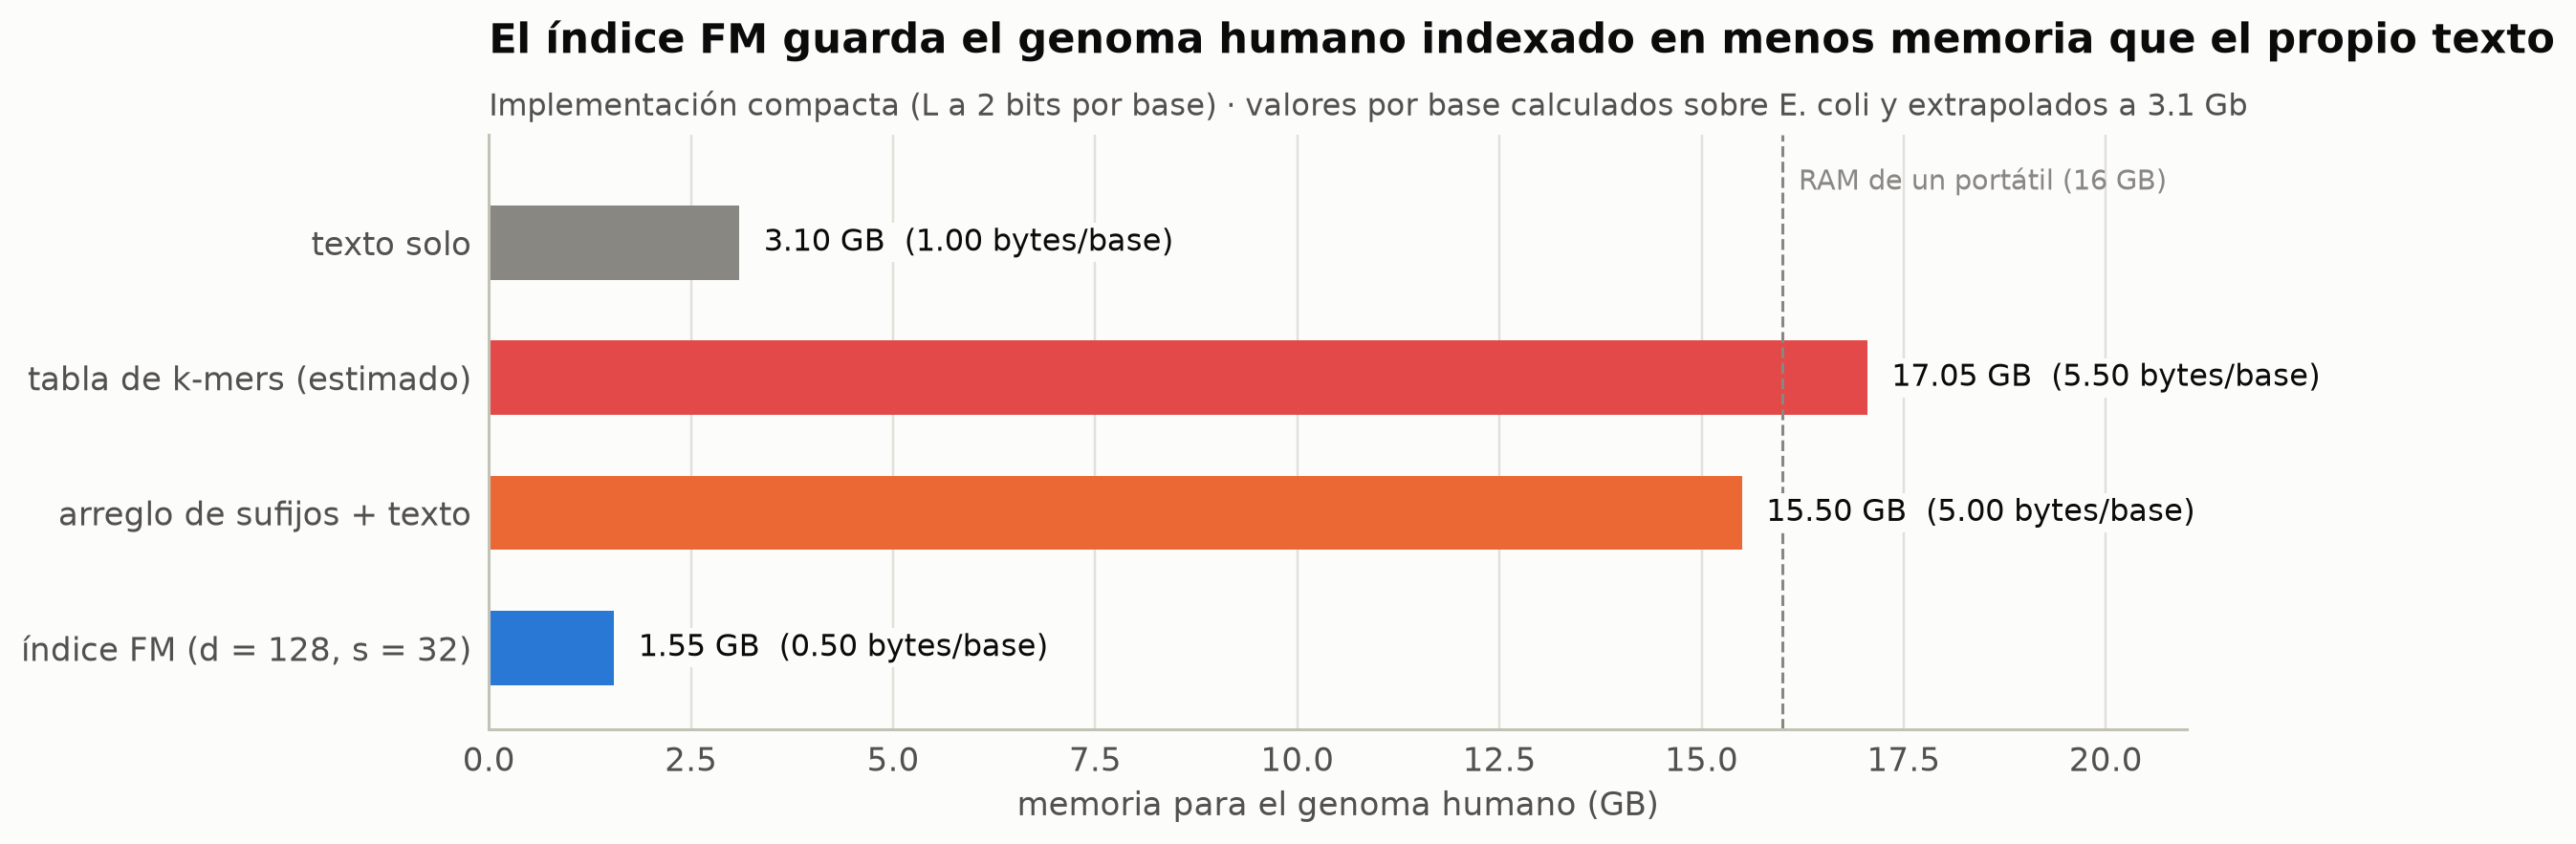

In [32]:
fig, ax = plt.subplots(figsize=(11, 3.9))
ypos = np.arange(len(mem))[::-1]
cols = [ec.MUTED, ec.RED, ec.ORANGE, ec.BLUE]
ax.barh(ypos, mem["humano (GB)"], color=cols, height=0.55)
ax.set_yticks(ypos, mem["índice"])
for y, v, b in zip(ypos, mem["humano (GB)"], mem["bytes por base"]):
    ax.text(v + 0.3, y, f"{v:.2f} GB  ({b:.2f} bytes/base)", va="center", fontsize=10.5, color=ec.INK, zorder=4,
            bbox=dict(fc=ax.get_facecolor(), ec="none", pad=1.5))
ax.axvline(16, color=ec.MUTED, lw=1, ls="--", zorder=1)
ax.text(16.2, ypos.max() + 0.45, "RAM de un portátil (16 GB)", fontsize=9.5, color=ec.MUTED, va="center")
ax.set_xlim(0, 21); ax.set_ylim(-0.6, ypos.max() + 0.8)
ax.set_xlabel("memoria para el genoma humano (GB)")
ax.xaxis.grid(True, color=ec.GRID); ax.yaxis.grid(False)
ec.title(ax, "El índice FM guarda el genoma humano indexado en menos memoria que el propio texto",
         "Implementación compacta (L a 2 bits por base) · valores por base calculados sobre E. coli y extrapolados a 3.1 Gb")
plt.show()

> 🔎 **Qué observamos.** El índice FM ocupa 0.5 bytes por base: **la mitad que el texto sin comprimir** (1 byte por
> base) y diez veces menos que el arreglo de sufijos con su texto (12 GB + 3 GB). Para el genoma humano son
> $0.775 + 0.388 + 0.388 \approx$ **1.55 GB**, las mismas cifras de la ecuación del libro, y del mismo orden que los
> ~1.3 GB con que Bowtie alineaba más de 25 millones de lecturas por hora de CPU (Langmead y colaboradores, 2009). Así,
> un índice de todo el genoma humano cabe en la memoria de un portátil (BWA indexa además el genoma invertido, para
> acotar la búsqueda con errores de la sección 12). Los tres ingredientes
> (2 bits por base, puntos de control, muestreo) son perillas que cada programa ajusta según quiera más velocidad o
> menos memoria.

## 12. Buscar con errores: retroceso, el puente hacia BWA y Bowtie

La búsqueda hacia atrás exige que cada letra coincida. Para tolerar hasta $z$ **sustituciones** (*mismatches*),
convertimos la búsqueda en la exploración de un **árbol**: en cada paso, en lugar de extender el bloque sólo con la
letra del patrón, probamos las **cuatro** letras. Si usamos una letra distinta de la del patrón, gastamos uno de los
$z$ errores permitidos. Una rama se **poda** (se abandona) cuando su bloque queda vacío o cuando se agotan los errores.
Es el **retroceso** (*backtracking*): avanzar mientras se pueda y, al llegar a un callejón sin salida, volver a la
última bifurcación.

$$
\text{nodo } (k, sp, ep, e) \;\longrightarrow\;
\big(k-1,\ C[c] + \mathrm{Occ}(c, sp),\ C[c] + \mathrm{Occ}(c, ep),\ e + [c \ne p_k]\big),
\quad c \in \{A, C, G, T\}
$$

| Símbolo | Significado |
|---|---|
| $k$ | posición del patrón que se va a procesar (de $m$ hacia 1) |
| $[sp, ep)$ | bloque semiabierto de la rama; se poda si queda vacío ($sp \ge ep$) |
| $e$ | errores gastados hasta ahora; la rama se poda si $e > z$ |
| $[c \ne p_k]$ | vale 1 si la letra elegida no es la del patrón, 0 si coincide |
| $z$ | número máximo de sustituciones permitidas (usamos $z$, como Li y Durbin, para no confundirlo con la distancia $d$ entre puntos de control) |

El número de nodos crece muy rápido con $z$. Los mapeadores reales usan dos trucos que aquí sólo mencionamos:
**podar** con una cota inferior $D(i)$ de los errores que harán falta en el prefijo $P[0..i]$ que queda por leer
(BWA; Li y Durbin, 2009), y
empezar por la mitad del patrón con **menos** errores gracias a un índice del texto **invertido** (Bowtie; Langmead
et al., 2009). Bowtie además gasta primero los errores en las bases de **peor calidad**. Para lecturas largas, BWA-MEM
y Bowtie2 abandonan el retroceso: buscan **semillas** exactas con el índice FM y luego extienden con programación
dinámica (Smith-Waterman con bandas, Lección 3.2). Lo veremos en la Lección 7.2.

In [33]:
def search_with_mismatches(fm, pattern, z):
    """Todas las filas de la matriz cuyo prefijo difiere de `pattern` en ≤ z sustituciones.
    Devuelve (lista de (sp, ep, errores), número de nodos explorados)."""
    hits, nodes = [], 0

    def explore(k, sp, ep, used):
        nonlocal nodes
        nodes += 1
        if k < 0:
            hits.append((sp, ep, used)); return
        for c in "ACGT":
            cost = used + (c != pattern[k])
            if cost > z:
                continue
            nsp = fm.C[c] + fm.occ(c, sp)
            nep = fm.C[c] + fm.occ(c, ep)                        # intervalo semiabierto [nsp, nep)
            if nsp < nep:
                explore(k - 1, nsp, nep, cost)

    explore(len(pattern) - 1, 0, fm.n, 0)                        # empieza con todas las filas, [0, n)
    return hits, nodes

def positions_with_mismatches(fm, pattern, z):
    hits, nodes = search_with_mismatches(fm, pattern, z)
    return sorted((fm.resolve(r), e) for sp, ep, e in hits for r in range(sp, ep)), nodes

def hamming_brute(text, pattern, z):
    """Verificación: distancia de Hamming en cada posición (NumPy)."""
    t = np.frombuffer(text.encode(), dtype=np.uint8)
    p = np.frombuffer(pattern.encode(), dtype=np.uint8)
    win = np.lib.stride_tricks.sliding_window_view(t, len(p))
    dist = (win != p).sum(axis=1)
    return sorted((int(i), int(dist[i])) for i in np.flatnonzero(dist <= z))

# Verificación en SARS-CoV-2: lecturas de 24 pb con 0–2 errores introducidos
FM_SARS = FMIndex(T_sars, sa=SA_SARS)
for trial in range(30):
    i = int(rng.integers(0, len(SARS) - 24)); read = list(SARS[i:i + 24])
    for p in rng.choice(24, int(rng.integers(0, 3)), replace=False):
        read[p] = rng.choice([b for b in "ACGT" if b != read[p]])
    read = "".join(read)
    for z in (0, 1, 2):
        assert positions_with_mismatches(FM_SARS, read, z)[0] == hamming_brute(SARS, read, z)
print("✔ la búsqueda con retroceso coincide con la distancia de Hamming por fuerza bruta (30 lecturas × z = 0, 1, 2)")

example = list(ECOLI[3_000_000:3_000_040]); example[12] = "T" if example[12] != "T" else "G"
example = "".join(example)
for z in (0, 1, 2):
    pos, nodes = positions_with_mismatches(FM_ECOLI, example, z)
    print(f"z = {z}: {len(pos)} apariciones {pos[:4]} · {nodes:,} nodos explorados")

✔ la búsqueda con retroceso coincide con la distancia de Hamming por fuerza bruta (30 lecturas × z = 0, 1, 2)
z = 0: 0 apariciones [] · 28 nodos explorados
z = 1: 1 apariciones [(3000000, 1)] · 244 nodos explorados
z = 2: 1 apariciones [(3000000, 1)] · 2,269 nodos explorados


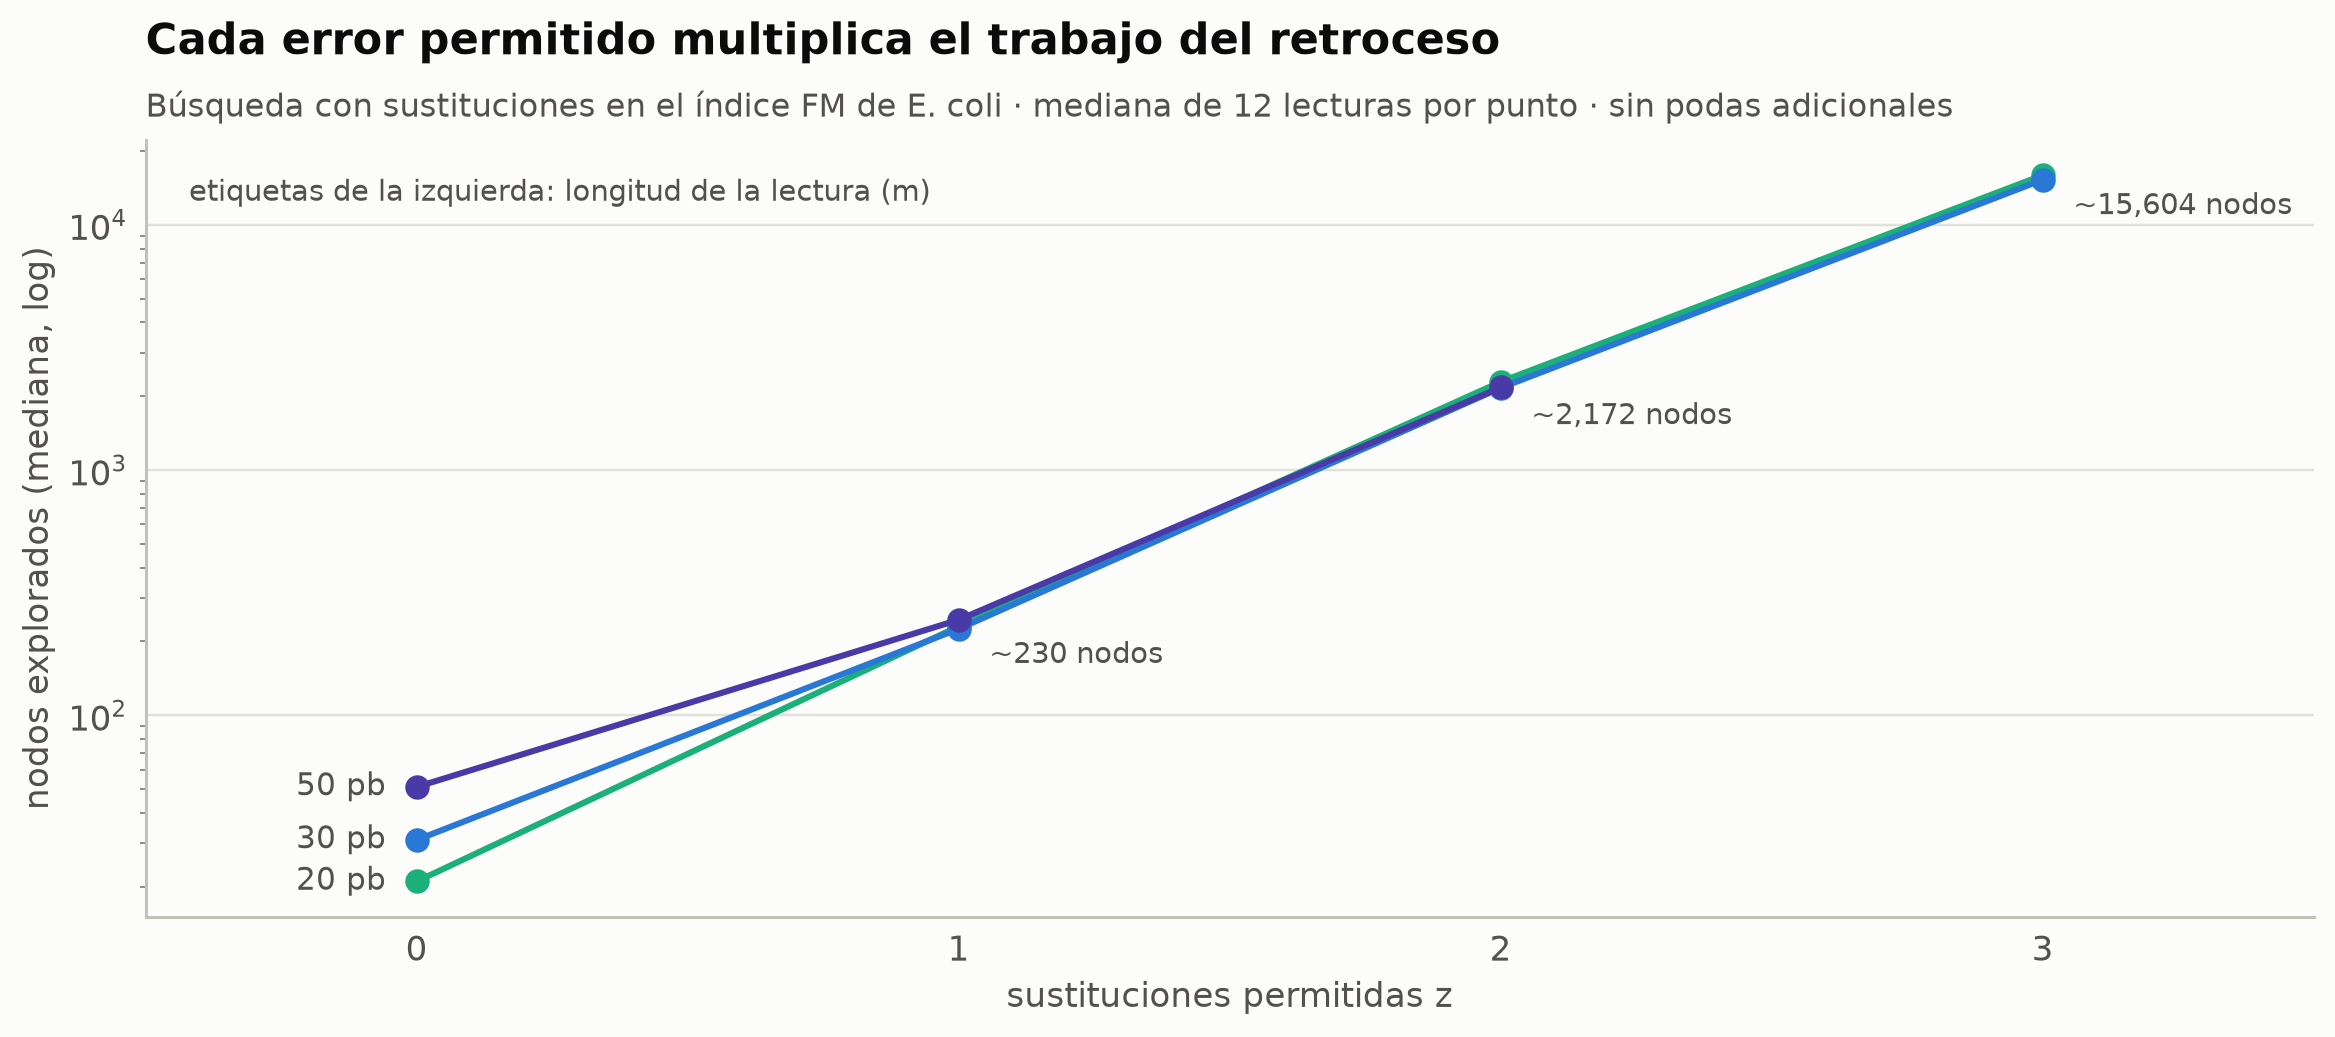

In [34]:
node_rows = []
for m in (20, 30, 50):
    starts_bt = rng.integers(0, len(ECOLI) - m, 12)
    for z in (0, 1, 2, 3):
        if m == 50 and z == 3:
            continue
        counts_bt = [search_with_mismatches(FM_ECOLI, ECOLI[s:s + m], z)[1] for s in starts_bt]
        node_rows.append({"m": m, "z": z, "nodos (mediana)": np.median(counts_bt)})
node_df = pd.DataFrame(node_rows)

fig, ax = plt.subplots(figsize=(10.5, 4.6))
for m, col in zip((20, 30, 50), (ec.AQUA, ec.BLUE, ec.VIOLET)):
    sub = node_df[node_df["m"] == m]
    ax.plot(sub["z"], sub["nodos (mediana)"], "o-", color=col, lw=2)
    ax.annotate(f"{m} pb", (0, sub["nodos (mediana)"].iloc[0]), xytext=(-10, 0), textcoords="offset points",
                ha="right", va="center", fontsize=10, color=ec.INK_2)
for z in (1, 2, 3):
    v = node_df[node_df["z"] == z]["nodos (mediana)"].median()
    ax.annotate(f"~{v:,.0f} nodos", (z, v), xytext=(10, -12), textcoords="offset points", fontsize=9.5, color=ec.INK_2)
ax.text(0.02, 0.95, "etiquetas de la izquierda: longitud de la lectura (m)", transform=ax.transAxes, fontsize=9.5,
        color=ec.INK_2, va="top")
ax.set_yscale("log"); ax.set_xticks([0, 1, 2, 3]); ax.set_xlim(-0.5, 3.5)
ax.set_xlabel("sustituciones permitidas z"); ax.set_ylabel("nodos explorados (mediana, log)")
ec.title(ax, "Cada error permitido multiplica el trabajo del retroceso",
         "Búsqueda con sustituciones en el índice FM de E. coli · mediana de 12 lecturas por punto · sin podas adicionales")
plt.show()

> 🔎 **Qué observamos.** Con $z = 0$ se exploran exactamente $m + 1$ nodos (una letra por paso). Cada error permitido
> multiplica el número de nodos por **unas diez veces**, porque en las primeras letras leídas (el extremo derecho del
> patrón) los bloques son enormes y casi cualquier letra sobrevive. Curiosamente, con $z \geq 1$ la longitud de la
> lectura casi no importa: tras unas 12–14 letras (≈ $\log_4 n$) los bloques ya contienen una sola fila, y las ramas
> con errores se extinguen enseguida. En un genoma humano, 700 veces más grande, esa zona de bloques grandes se
> alarga y el retroceso se encarece mucho más. Por eso el retroceso sin podas sólo es práctico para lecturas cortas y pocos errores, y por eso
> los mapeadores modernos combinan semillas exactas con extensión por programación dinámica.

Recuperemos ahora las lecturas con errores que el mini-mapeador exacto perdió en la sección 10, permitiendo $z = 2$
(con una muestra de 300, para no esperar):

In [35]:
lost = np.flatnonzero(status_map == "no mapeada")[:300]
rescued = []
t0 = time.perf_counter()
for idx in lost:
    r = reads[idx]
    best = []
    for strand, q in (("+", r), ("-", revcomp(r))):
        pos, _ = positions_with_mismatches(FM_ECOLI, q, 2)
        best += [(p, strand, e) for p, e in pos]
    if best:
        e_min = min(e for _, _, e in best)
        top = [b for b in best if b[2] == e_min]
        rescued.append(len(top) == 1 and top[0][0] == true_start[idx])
    else:
        rescued.append(False)
rescued = np.array(rescued)
errs = n_err[lost]
print(f"{len(lost)} lecturas perdidas → recuperadas en su posición correcta con z = 2: {rescued.mean():.1%} "
      f"({time.perf_counter() - t0:.1f} s)")
for e in sorted(set(errs)):
    print(f"  con {e} error(es): {rescued[errs == e].mean():.0%} recuperadas (n = {np.sum(errs == e)})")

300 lecturas perdidas → recuperadas en su posición correcta con z = 2: 96.3% (1.4 s)
  con 1 error(es): 97% recuperadas (n = 264)
  con 2 error(es): 100% recuperadas (n = 32)
  con 3 error(es): 0% recuperadas (n = 4)


> 🔎 **Qué observamos.** Las lecturas con 1 o 2 errores se recuperan prácticamente todas, en su posición correcta;
> las que tienen 3 o más siguen perdidas, porque exceden $z$. Aceptar errores tiene un precio: cada lectura cuesta
> ahora mucho más tiempo que la búsqueda exacta, y en un genoma grande aumenta el riesgo de que una lectura con errores
> se parezca más a otra copia de una repetición que a su origen verdadero.

## 13. Ejercicios

**Ejercicio 1 — BWT a mano.** Calcule a mano la matriz de rotaciones ordenadas, el arreglo de sufijos y la BWT de
`ACAACG$`. Después invierta su BWT paso a paso con la tabla LF, como en la sección 7. Compruebe todo con
`rotations_sorted`, `suffix_array_naive` e `inverse_bwt`.

**Ejercicio 2 — Búsqueda hacia atrás a mano.** Con el índice de `ACAACG$` del ejercicio 1, construya la tabla $C$ y la
tabla $\mathrm{Occ}$, y busque a mano `AAC` y `CA`. Compruebe con `backward_search`.

**Ejercicio 3 — Ajustar las perillas del índice.** Construya índices FM de *E. coli* con `occ_step` ($d$) $\in \{32,
128, 512\}$ y `sa_step` ($s$) $\in \{8, 32, 128\}$ (reutilice `SA_ECOLI`). Para cada combinación mida la memoria
compacta (`memory_bytes`, que sigue la ecuación $\mathcal{M}(d, s)$) y el tiempo medio de `locate` de 200 patrones de
30 pb tomados del genoma. ¿Qué combinación elegiría para indexar el genoma humano si dispone de 4 GB de RAM?

**Ejercicio 4 — El cromosoma 17 humano.** El repositorio incluye 300 kb del cromosoma 17 humano alrededor de *TP53*
(`NC_000017.11_7400001-7700000.fasta.gz`). Constrúyale un índice FM y repita el análisis de la sección 10: ¿qué
fracción de 20-mers y de 32-mers es única? Compárela con *E. coli* y explique la diferencia. (Pista: los elementos
*Alu*, de ~300 pb y con más de un millón de copias en el genoma humano.)

In [36]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
T_ex = "ACAACG$"
for i, (row, j) in enumerate(zip(rotations_sorted(T_ex), suffix_array_naive(T_ex))):
    print(f"fila {i}: {row}   SA = {j}   F = {row[0]}  L = {row[-1]}")
L_ex = bwt_from_sa(T_ex, suffix_array_naive(T_ex))
C_ex, ranks_ex, lf_ex = lf_table(L_ex)
print("BWT =", L_ex, "· C =", C_ex, "· LF =", lf_ex)
i, rec = 0, "$"
for step in range(len(L_ex) - 1):
    rec = L_ex[i] + rec
    print(f"  paso {step}: fila {i}, L = {L_ex[i]}, LF = {lf_ex[i]} → {rec}")
    i = lf_ex[i]
assert inverse_bwt(L_ex) == T_ex

fila 0: $ACAACG   SA = 6   F = $  L = G
fila 1: AACG$AC   SA = 2   F = A  L = C
fila 2: ACAACG$   SA = 0   F = A  L = $
fila 3: ACG$ACA   SA = 3   F = A  L = A
fila 4: CAACG$A   SA = 1   F = C  L = A
fila 5: CG$ACAA   SA = 4   F = C  L = A
fila 6: G$ACAAC   SA = 5   F = G  L = C
BWT = GC$AAAC · C = {'$': 0, 'A': 1, 'C': 4, 'G': 6} · LF = [6, 4, 0, 1, 2, 3, 5]
  paso 0: fila 0, L = G, LF = 6 → G$
  paso 1: fila 6, L = C, LF = 5 → CG$
  paso 2: fila 5, L = A, LF = 3 → ACG$
  paso 3: fila 3, L = A, LF = 1 → AACG$
  paso 4: fila 1, L = C, LF = 4 → CAACG$
  paso 5: fila 4, L = A, LF = 2 → ACAACG$


In [37]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
C_ex2 = build_C(L_ex)
print("C =", C_ex2)
print(pd.DataFrame({c: [occ_naive(L_ex, c, r) for r in range(len(L_ex) + 1)] for c in sorted(C_ex2)}).T.to_string())
for p in ["AAC", "CA"]:
    (sp, ep), steps = backward_search(L_ex, C_ex2, p, trace=True)
    print(f"{p}: " + " → ".join(f"[{s}, {e})" for _, s, e in steps) + f" → {max(0, ep - sp)} apariciones en "
          f"{sorted(suffix_array_naive(T_ex)[sp:ep])}")

C = {'$': 0, 'A': 1, 'C': 4, 'G': 6}
   0  1  2  3  4  5  6  7
$  0  0  0  1  1  1  1  1
A  0  0  0  0  1  2  3  3
C  0  0  1  1  1  1  1  2
G  0  1  1  1  1  1  1  1
AAC: [0, 7) → [4, 6) → [2, 4) → [1, 2) → 1 apariciones en [2]
CA: [0, 7) → [1, 4) → [4, 5) → 1 apariciones en [1]


In [38]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
probe = [ECOLI[s:s + 30] for s in rng.integers(0, len(ECOLI) - 30, 200)]
rows_ex3 = []
for occ_step in (32, 128, 512):
    for sa_step in (8, 32, 128):
        fm_x = FMIndex(T_ECOLI, sa=SA_ECOLI, occ_step=occ_step, sa_step=sa_step)
        t = best_time(lambda: [fm_x.locate(p) for p in probe], number=1, repeat=2) / len(probe)
        b = sum(fm_x.memory_bytes().values()) / fm_x.n
        rows_ex3.append({"occ_step": occ_step, "sa_step": sa_step, "bytes/base": b,
                         "humano (GB)": b * 3.1, "µs por locate": t * 1e6})
print(pd.DataFrame(rows_ex3).round(2).to_string(index=False))
print("Con 4 GB caben todas las combinaciones (la más densa, d = 32 y s = 8, roza el límite con ~3.9 GB); d = 128 y")
print("s = 32 (≈1.55 GB, los intervalos de BWA) es un buen equilibrio. En Python los tiempos son ruidosos (domina el")
print("intérprete); en una implementación en C, s controla el costo de localizar y d el de cada consulta a Occ.")

 occ_step  sa_step  bytes/base  humano (GB)  µs por locate
       32        8        1.25         3.88          28.09
       32       32        0.88         2.71          16.74
       32      128        0.78         2.42          84.81
      128        8        0.88         2.71          21.81
      128       32        0.50         1.55          33.06
      128      128        0.41         1.26          71.27
      512        8        0.78         2.42          37.03
      512       32        0.41         1.26          44.89
      512      128        0.31         0.97          79.09
Con 4 GB caben todas las combinaciones (la más densa, d = 32 y s = 8, roza el límite con ~3.9 GB); d = 128 y
s = 32 (≈1.55 GB, los intervalos de BWA) es un buen equilibrio. En Python los tiempos son ruidosos (domina el
intérprete); en una implementación en C, s controla el costo de localizar y d el de cada consulta a Occ.


In [39]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
CHR17 = fasta_sequence(gzip.decompress(course_bytes("NC_000017.11_7400001-7700000.fasta.gz")).decode())
CHR17 = re.sub("[^ACGT]", "", CHR17)            # quitamos N u otras letras para simplificar
FM_17 = FMIndex(CHR17 + "$")
st = rng.integers(0, len(CHR17) - 40, 2000)
for k in (20, 32):
    c17 = np.array([count_both_strands(FM_17, CHR17[i:i + k]) for i in st])
    cec = kmer_counts[k]
    print(f"k = {k}: únicos en chr17 {np.mean(c17 == 1):.1%} (máx. {c17.max()}) · en E. coli {np.mean(cec == 1):.1%}")
print("Aunque la región humana es 15 veces más pequeña que E. coli, tiene muchos más k-mers repetidos: las familias de")
print("repeticiones (Alu, L1) aparecen varias veces incluso en 300 kb, y en el genoma completo lo harían miles de veces.")

k = 20: únicos en chr17 86.2% (máx. 214) · en E. coli 97.3%
k = 32: únicos en chr17 94.8% (máx. 28) · en E. coli 97.5%
Aunque la región humana es 15 veces más pequeña que E. coli, tiene muchos más k-mers repetidos: las familias de
repeticiones (Alu, L1) aparecen varias veces incluso en 300 kb, y en el genoma completo lo harían miles de veces.


## 📌 Resumen

* **Mapear** es encontrar el origen de cada lectura en el genoma. Sin índice, el costo es proporcional a
  $N \cdot G$ (lecturas × longitud del genoma): décadas para un genoma humano, y ~9 000 años con Smith-Waterman. Con
  un índice FM es proporcional a $N \cdot m$: minutos u horas.
* La **tabla de *k*-mers** consulta en tiempo constante, pero fija $k$ y ocupa $\gtrsim 4$ bytes por base; una semilla
  necesita unas 20 bases para ser informativa en el genoma humano ($G/4^k$).
* El **arreglo de sufijos** ordena los sufijos: las apariciones de un patrón forman un **bloque** semiabierto
  $[sp, ep)$, con $ep - sp$ apariciones, que se encuentra por búsqueda binaria en $O(m \log n)$. Ocupa 4 bytes por
  base: 12 GB para el genoma humano (más 3 GB del texto).
* La **BWT** es la última columna $L$ de la matriz de rotaciones ordenadas: $L[r] = T[\mathrm{SA}[r] - 1]$ (o `$` si
  $\mathrm{SA}[r] = 0$). Agrupa letras con el mismo contexto, lo que crea **corridas** y la hace compresible, sobre todo
  en textos repetitivos como colecciones de genomas.
* **Propiedad LF**: la $j$-ésima $c$ de $L$ es la misma letra del texto que la $j$-ésima $c$ de $F$.
  $\mathrm{LF}(r) = C[L[r]] + \mathrm{Occ}(L[r], r)$ retrocede una posición en el texto; permite **invertir** la BWT.
* **Índice FM** = $L$ + $C$ + $\mathrm{Occ}$ (con puntos de control cada $d$ filas) + arreglo de sufijos
  **muestreado** cada $s$ posiciones. **Búsqueda hacia atrás** desde $[0, n)$: $sp' = C[c] + \mathrm{Occ}(c, sp)$,
  $ep' = C[c] + \mathrm{Occ}(c, ep)$; cuenta $ep - sp$ apariciones en $O(m)$, independiente de $n$ (en `TACATACAG$`,
  `ACA` → $[1, 3)$). **Localizar** usa $\mathrm{SA}[r] = \mathrm{SA}[\mathrm{LF}^j(r)] + j$, con $j < s$.
* Con $d = 128$ y $s = 32$, $\mathcal{M}(d, s) = 2n + 4bn/d + bn/s$ bits da 0.5 bytes por base: el genoma humano
  indexado cabe en ~1.55 GB (entre 1 y 2 GB), menos que el propio texto; Bowtie usaba ~1.3 GB.
* Las **repeticiones** producen lecturas multimapeadas; los **errores** exigen retroceso (BWA, Bowtie) o semillas más
  extensión por programación dinámica (BWA-MEM, Bowtie2), el tema de la Lección 7.2.

## 📚 Para profundizar

* Burrows, M. & Wheeler, D. J. (1994). *A block-sorting lossless data compression algorithm*. Technical Report 124,
  Digital Equipment Corporation, Systems Research Center, Palo Alto.
* Manber, U. & Myers, G. (1993). Suffix arrays: a new method for on-line string searches. *SIAM Journal on Computing*
  22(5): 935–948.
* Ferragina, P. & Manzini, G. (2000). Opportunistic data structures with applications. *Proceedings of the 41st
  Annual Symposium on Foundations of Computer Science (FOCS)*, 390–398.
* Ferragina, P. & Manzini, G. (2005). Indexing compressed text. *Journal of the ACM* 52(4): 552–581.
* Langmead, B., Trapnell, C., Pop, M. & Salzberg, S. L. (2009). Ultrafast and memory-efficient alignment of short DNA
  sequences to the human genome. *Genome Biology* 10(3): R25.
* Li, H. & Durbin, R. (2009). Fast and accurate short read alignment with Burrows-Wheeler transform.
  *Bioinformatics* 25(14): 1754–1760.
* Langmead, B. (2010). Aligning short sequencing reads with Bowtie. *Current Protocols in Bioinformatics* 32:
  11.7.1–11.7.14.

---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)